# Dataset 1: Daily Activities and Sports Dataset

# 0. Fuentes

La base de datos se puede obtener en el siguiente enlace:

https://archive.ics.uci.edu/dataset/256/daily+and+sports+activities

El artículo del paper se puede obtener en el siguiente enlace:

https://yoksis.bilkent.edu.tr/pdf/files/10.1016-j.patcog.2010.04.019.pdf

# 1. Primera entrega: EDA y pre-procesamiento

## 1.1.    Cargar los datos

Llamamos a las librerías para importar los datos:

- pandas:
- os: 

In [1]:
import pandas as pd
pd.set_option("display.float_format", "{:.3f}".format)

import os

In [3]:
from abc import ABC, abstractmethod

class AbstractDataLoader(ABC):
    def __init__(self, src_path:str, keys:list, file_extension:str, delimiter:str):
        self.src_path = src_path
        self.keys = keys
        self.file_extension = file_extension
        self.delimiter = delimiter     
        
    @abstractmethod
    def load_data(self):
        pass

    @abstractmethod
    def _is_valid_extension(self, file):
        pass


class DataLoaderDSA(AbstractDataLoader):
    def __init__(self, src_path:str, keys:list, file_extension:str, delimiter:str):
        super().__init__(src_path, keys, file_extension, delimiter)
        
    
    def load_data(self):
        dataframes = []
        for activity in os.listdir(self.src_path):
            act_path = f"{self.src_path}/{activity}"
            for person in os.listdir(act_path):
                person_path = f"{self.src_path}/{activity}/{person}"
                for segment in os.listdir(person_path):
                    segment_path = f"{self.src_path}/{activity}/{person}/{segment}"
                    if self._is_valid_extension(segment):  
                        segment_features = pd.read_csv(segment_path, delimiter=self.delimiter, names=self.keys)
                        segment_features['activity_label'] = activity
                        segment_features['person_id'] = person
                        segment_features['segment'] = f"{activity}{person}{segment}"
                        dataframes.append(segment_features)
        final_df = pd.concat(dataframes, ignore_index=True)
        return final_df
    
                
    def _is_valid_extension(self, file):
        return file.endswith(self.file_extension)


dsa_path = "dataset/dsaa/data"

keys = [
    # Tronco (T)
    "T_xacc", "T_yacc", "T_zacc", "T_xgyro", "T_ygyro", "T_zgyro", "T_xmag", "T_ymag", "T_zmag",
    
    # Brazo derecho (RA)
    "RA_xacc", "RA_yacc", "RA_zacc", "RA_xgyro", "RA_ygyro", "RA_zgyro", "RA_xmag", "RA_ymag", "RA_zmag",
    
    # Brazo izquierdo (LA)
    "LA_xacc", "LA_yacc", "LA_zacc", "LA_xgyro", "LA_ygyro", "LA_zgyro", "LA_xmag", "LA_ymag", "LA_zmag",
    
    # Pierna derecha (RL)
    "RL_xacc", "RL_yacc", "RL_zacc", "RL_xgyro", "RL_ygyro", "RL_zgyro", "RL_xmag", "RL_ymag", "RL_zmag",
    
    # Pierna izquierda (LL)
    "LL_xacc", "LL_yacc", "LL_zacc", "LL_xgyro", "LL_ygyro", "LL_zgyro", "LL_xmag", "LL_ymag", "LL_zmag"
]

file_extension = '.txt'
delimiter = r','
data_loader = DataLoaderDSA(dsa_path, keys, file_extension, delimiter)

dsa_df = data_loader.load_data()

## 1.2. Dimensiones y primeras 5 filas

Dimensiones

In [5]:
dsa_df.shape

(1140000, 48)

Primeras 5 filas

In [7]:
dsa_df.head()

,T_xacc,T_yacc,T_zacc,T_xgyro,T_ygyro,T_zgyro,T_xmag,T_ymag,T_zmag,RA_xacc,...,LL_zacc,LL_xgyro,LL_ygyro,LL_zgyro,LL_xmag,LL_ymag,LL_zmag,activity_label,person_id,segment
0,8.130,1.035,5.422,-0.009,0.002,-0.003,-0.787,-0.070,0.157,0.701,...,2.622,-0.000,-0.012,-0.004,0.740,0.301,-0.058,a01,p1,a01p1s01.txt
1,8.130,1.020,5.384,-0.009,0.023,0.002,-0.787,-0.068,0.159,0.718,...,2.622,-0.015,-0.016,0.003,0.739,0.302,-0.058,a01,p1,a01p1s01.txt
2,8.160,1.020,5.362,0.015,0.014,0.000,-0.787,-0.068,0.159,0.698,...,2.637,-0.013,0.006,-0.008,0.740,0.301,-0.057,a01,p1,a01p1s01.txt
3,8.160,1.005,5.377,0.007,0.018,0.006,-0.785,-0.070,0.159,0.728,...,2.607,-0.006,0.010,0.007,0.740,0.302,-0.058,a01,p1,a01p1s01.txt
4,8.161,1.028,5.347,0.009,0.030,-0.005,-0.787,-0.069,0.159,0.716,...,2.622,-0.004,-0.008,0.003,0.738,0.301,-0.058,a01,p1,a01p1s01.txt


## 1.3. Identifica y elimina los datos ausentes

In [9]:
dsa_df.isnull().sum()

T_xacc            0
T_yacc            0
T_zacc            0
T_xgyro           0
T_ygyro           0
T_zgyro           0
T_xmag            0
T_ymag            0
T_zmag            0
RA_xacc           0
RA_yacc           0
RA_zacc           0
RA_xgyro          0
RA_ygyro          0
RA_zgyro          0
RA_xmag           0
RA_ymag           0
RA_zmag           0
LA_xacc           0
LA_yacc           0
LA_zacc           0
LA_xgyro          0
LA_ygyro          0
LA_zgyro          0
LA_xmag           0
LA_ymag           0
LA_zmag           0
RL_xacc           0
RL_yacc           0
RL_zacc           0
RL_xgyro          0
RL_ygyro          0
RL_zgyro          0
RL_xmag           0
RL_ymag           0
RL_zmag           0
LL_xacc           0
LL_yacc           0
LL_zacc           0
LL_xgyro          0
LL_ygyro          0
LL_zgyro          0
LL_xmag           0
LL_ymag           0
LL_zmag           0
activity_label    0
person_id         0
segment           0
dtype: int64

## 1.4. Presenta los tipos de datos de cada atributo de cada base de datos

In [11]:
dsa_df.dtypes

T_xacc            float64
T_yacc            float64
T_zacc            float64
T_xgyro           float64
T_ygyro           float64
T_zgyro           float64
T_xmag            float64
T_ymag            float64
T_zmag            float64
RA_xacc           float64
RA_yacc           float64
RA_zacc           float64
RA_xgyro          float64
RA_ygyro          float64
RA_zgyro          float64
RA_xmag           float64
RA_ymag           float64
RA_zmag           float64
LA_xacc           float64
LA_yacc           float64
LA_zacc           float64
LA_xgyro          float64
LA_ygyro          float64
LA_zgyro          float64
LA_xmag           float64
LA_ymag           float64
LA_zmag           float64
RL_xacc           float64
RL_yacc           float64
RL_zacc           float64
RL_xgyro          float64
RL_ygyro          float64
RL_zgyro          float64
RL_xmag           float64
RL_ymag           float64
RL_zmag           float64
LL_xacc           float64
LL_yacc           float64
LL_zacc     

## 1.5. Presenta el resumen estadístico de cada uno de los atributos de cada base de datos

In [13]:
pd.set_option('display.max_columns', None)  
dsa_df.describe().T

,count,mean,std,min,25%,50%,75%,max
T_xacc,1140000.000,7.766,5.638,-99.715,6.907,8.830,9.691,93.694
T_yacc,1140000.000,-0.811,2.623,-49.941,-1.510,-0.390,0.414,41.013
T_zacc,1140000.000,2.769,3.538,-62.664,0.900,2.704,4.405,120.530
T_xgyro,1140000.000,-0.003,0.794,-27.851,-0.163,0.000,0.165,27.671
T_ygyro,1140000.000,0.014,0.691,-23.598,-0.102,0.017,0.131,14.379
T_zgyro,1140000.000,-0.003,0.311,-12.067,-0.097,-0.003,0.089,19.262
T_xmag,1140000.000,-0.598,0.356,-1.423,-0.825,-0.690,-0.493,1.022
T_ymag,1140000.000,0.062,0.340,-1.023,-0.179,0.022,0.282,1.031
T_zmag,1140000.000,-0.273,0.373,-1.081,-0.602,-0.309,0.041,0.963
RA_xacc,1140000.000,4.261,5.821,-49.535,0.095,4.143,8.505,71.652


## 1.6. Presenta la distribución de clases de cada base de datos

Por convención a las actividaes se les asigna un label alfanumérico. A continuación se presenta la correspondencia entre estos y las actividades que representan:

- sitting (A1),
- standing (A2),
- lying on back and on right side (A3 and A4),
- ascending and descending stairs (A5 and A6),
- standing in an elevator still (A7) and moving around (A8),
- walking in a parking lot (A9),
- walking on a treadmill with a speed of 4 km/h (in flat and 151 inclined positions) (A10 and A11),
- running on a treadmill with a speed of 8 km/h (A12),
- exercising on a stepper (A13),
- exercising on a cross trainer (A14), cycling on an exercise bike in horizontal and vertical positions (A15 and A16),
- rowing (A17),
- jumping (A18),
- playing basketball (A19).

In [15]:
dsa_class_distribution = dsa_df['activity_label'].value_counts()
dsa_class_distribution

activity_label
a01    60000
a11    60000
a18    60000
a17    60000
a16    60000
a15    60000
a14    60000
a13    60000
a12    60000
a10    60000
a02    60000
a09    60000
a08    60000
a07    60000
a06    60000
a05    60000
a04    60000
a03    60000
a19    60000
Name: count, dtype: int64

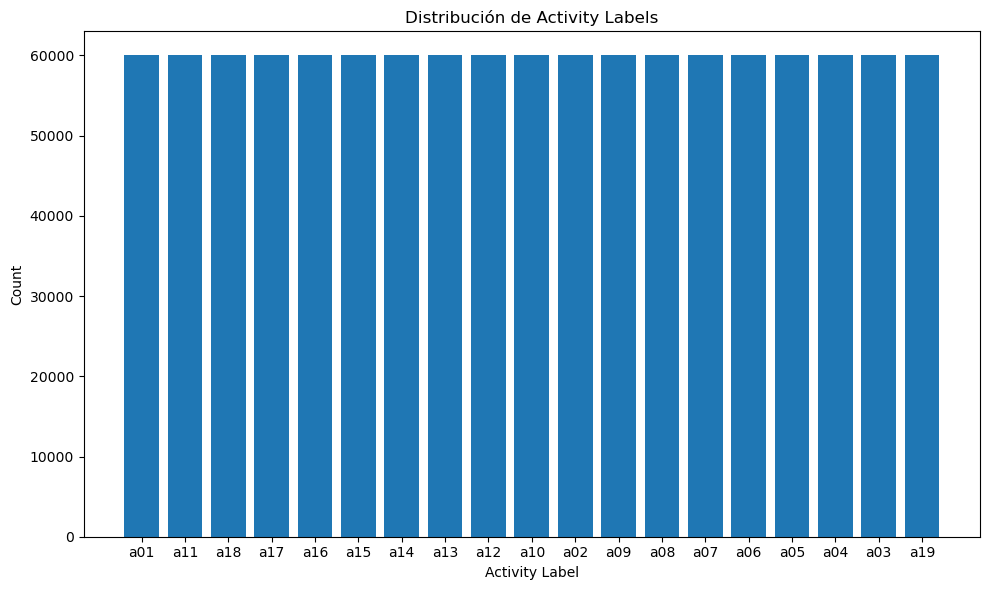

In [17]:
import matplotlib.pyplot as plt

dsa_class_distribution = dsa_df['activity_label'].value_counts()

plt.figure(figsize=(10, 6))
plt.bar(dsa_class_distribution.index, dsa_class_distribution.values)
plt.xlabel('Activity Label')
plt.ylabel('Count')
plt.title('Distribución de Activity Labels')
plt.tight_layout()
plt.show()

## 1.7. Presenta la correlación entre atributos de cada base de datos

In [19]:
non_sensor_columns = ["activity_label", "person_id", "segment"]

only_sensor_columns = dsa_df.drop(non_sensor_columns, axis="columns")

dsa_corr_matrix = only_sensor_columns.iloc[:, :].corr(method = "pearson")
dsa_corr_matrix

,T_xacc,T_yacc,T_zacc,T_xgyro,T_ygyro,T_zgyro,T_xmag,T_ymag,T_zmag,RA_xacc,RA_yacc,RA_zacc,RA_xgyro,RA_ygyro,RA_zgyro,RA_xmag,RA_ymag,RA_zmag,LA_xacc,LA_yacc,LA_zacc,LA_xgyro,LA_ygyro,LA_zgyro,LA_xmag,LA_ymag,LA_zmag,RL_xacc,RL_yacc,RL_zacc,RL_xgyro,RL_ygyro,RL_zgyro,RL_xmag,RL_ymag,RL_zmag,LL_xacc,LL_yacc,LL_zacc,LL_xgyro,LL_ygyro,LL_zgyro,LL_xmag,LL_ymag,LL_zmag
T_xacc,1.000,0.053,-0.055,-0.027,-0.069,0.003,-0.591,-0.185,0.152,0.364,0.357,-0.082,0.048,0.003,0.034,-0.108,-0.059,0.028,0.424,-0.278,0.160,-0.039,0.002,-0.029,-0.159,-0.009,-0.108,-0.591,-0.296,0.112,0.012,0.055,-0.010,0.204,0.037,-0.177,-0.593,0.237,-0.230,-0.017,0.006,0.003,0.228,0.018,0.172
T_yacc,0.053,1.000,0.067,-0.118,-0.012,-0.038,-0.134,-0.460,-0.155,-0.071,0.195,-0.136,-0.048,-0.067,-0.086,0.030,-0.176,-0.012,0.133,-0.135,0.380,-0.053,0.048,-0.090,-0.100,0.137,-0.343,-0.195,0.100,0.437,-0.025,0.020,0.181,0.216,-0.128,-0.299,-0.090,-0.069,-0.514,-0.021,-0.044,0.173,0.126,0.206,0.328
T_zacc,-0.055,0.067,1.000,0.007,-0.079,0.011,0.339,-0.040,-0.261,-0.044,0.048,0.086,0.006,0.030,-0.002,-0.031,0.057,0.019,-0.066,-0.091,0.090,-0.007,0.039,-0.012,0.091,-0.053,-0.007,0.009,0.115,0.028,-0.036,0.015,-0.015,-0.094,-0.105,-0.027,0.021,-0.094,-0.004,0.026,-0.036,0.029,-0.152,0.019,0.038
T_xgyro,-0.027,-0.118,0.007,1.000,0.056,-0.013,0.002,0.010,-0.004,-0.014,-0.022,0.028,0.126,0.276,0.124,-0.017,-0.009,0.005,-0.000,0.014,-0.034,0.128,-0.222,0.170,0.031,-0.007,-0.005,-0.032,0.091,-0.033,-0.033,-0.047,-0.328,0.024,0.019,0.008,0.044,0.062,0.058,-0.009,0.084,-0.309,-0.032,0.026,-0.006
T_ygyro,-0.069,-0.012,-0.079,0.056,1.000,0.043,0.003,-0.003,-0.001,0.026,-0.018,-0.005,-0.033,0.010,-0.017,-0.012,-0.004,0.003,0.024,0.036,-0.009,0.003,0.014,0.021,-0.013,-0.003,0.000,0.046,0.079,0.006,-0.008,-0.092,-0.090,0.008,0.011,-0.001,0.064,-0.069,0.013,0.024,-0.069,0.098,0.008,-0.009,0.004
T_zgyro,0.003,-0.038,0.011,-0.013,0.043,1.000,-0.001,0.025,-0.000,0.043,-0.014,0.001,0.026,0.140,0.139,0.006,-0.003,-0.005,-0.023,-0.013,0.012,0.043,-0.112,0.131,-0.008,-0.014,0.024,0.062,-0.026,0.003,-0.095,0.049,-0.065,-0.056,-0.091,-0.004,-0.040,-0.028,-0.014,-0.106,-0.065,-0.036,0.053,-0.077,0.006
T_xmag,-0.591,-0.134,0.339,0.002,0.003,-0.001,1.000,0.237,-0.196,-0.148,-0.202,0.070,-0.005,0.012,-0.011,0.190,0.201,-0.006,-0.205,0.094,-0.214,0.008,0.024,0.005,0.259,-0.085,0.250,0.305,0.115,-0.202,-0.006,-0.022,0.005,-0.364,-0.036,0.211,0.269,-0.078,0.257,0.010,-0.030,-0.009,-0.404,-0.034,-0.226
T_ymag,-0.185,-0.460,-0.040,0.010,-0.003,0.025,0.237,1.000,-0.001,0.003,-0.148,0.135,0.011,0.016,0.023,-0.111,0.262,-0.491,-0.149,0.121,-0.240,0.010,-0.009,0.029,0.116,0.301,0.462,0.143,-0.039,-0.328,0.003,0.012,-0.049,-0.136,0.001,0.825,0.067,0.029,0.378,-0.003,0.006,-0.050,0.011,0.020,-0.852
T_zmag,0.152,-0.155,-0.261,-0.004,-0.001,-0.000,-0.196,-0.001,1.000,0.186,-0.036,-0.064,0.002,-0.015,0.007,-0.463,0.213,0.388,0.184,0.102,-0.140,-0.002,-0.010,-0.006,-0.426,-0.386,0.316,-0.011,-0.037,-0.089,-0.005,-0.027,-0.006,0.172,0.636,-0.047,0.003,0.057,0.073,0.010,-0.031,0.008,0.101,-0.612,-0.017
RA_xacc,0.364,-0.071,-0.044,-0.014,0.026,0.043,-0.148,0.003,0.186,1.000,-0.135,-0.266,0.051,-0.021,0.079,-0.494,0.184,0.157,0.696,0.035,-0.262,-0.039,-0.037,0.012,-0.489,-0.067,0.301,-0.364,-0.346,-0.002,0.012,0.058,-0.032,0.266,0.300,0.008,-0.414,0.267,-0.027,-0.022,0.013,-0.037,0.302,-0.311,0.023


## 1.8. Presenta el histograma de los atributos de cada base de datos

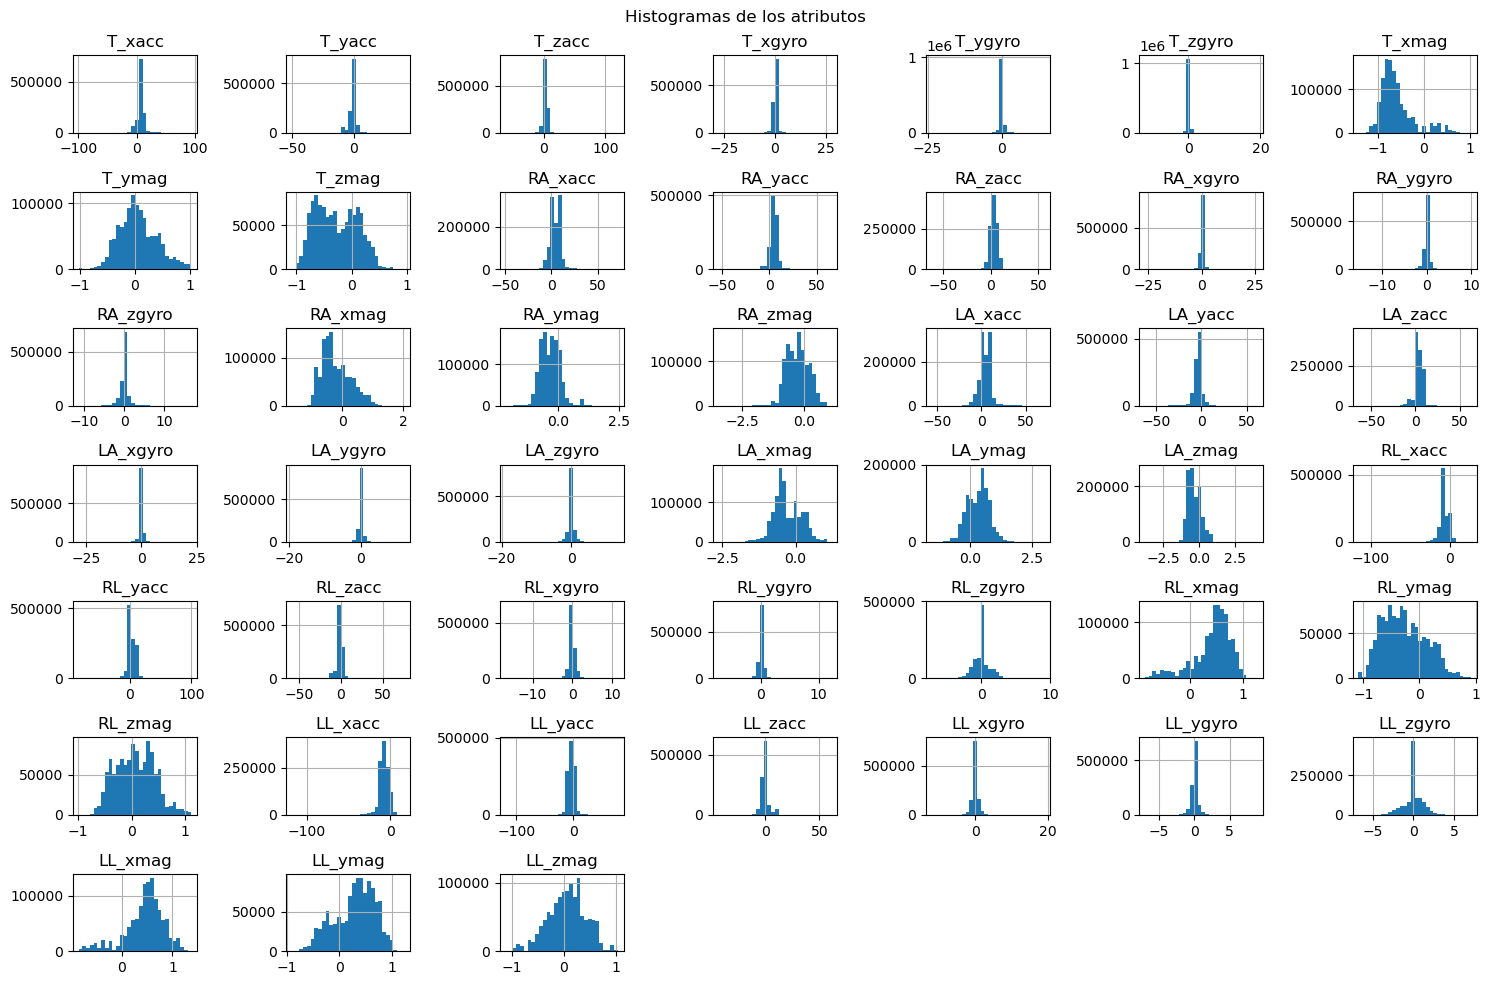

In [21]:
import matplotlib.pyplot as plt


only_sensor_columns.hist(bins=30, figsize=(15, 10))


plt.xlim(-10, 10)

plt.suptitle("Histogramas de los atributos")
plt.tight_layout()
plt.show()


## 1.9. Genera la gráfica de densidad para la distribución de los atributos de cada base de datos

KeyboardInterrupt: 

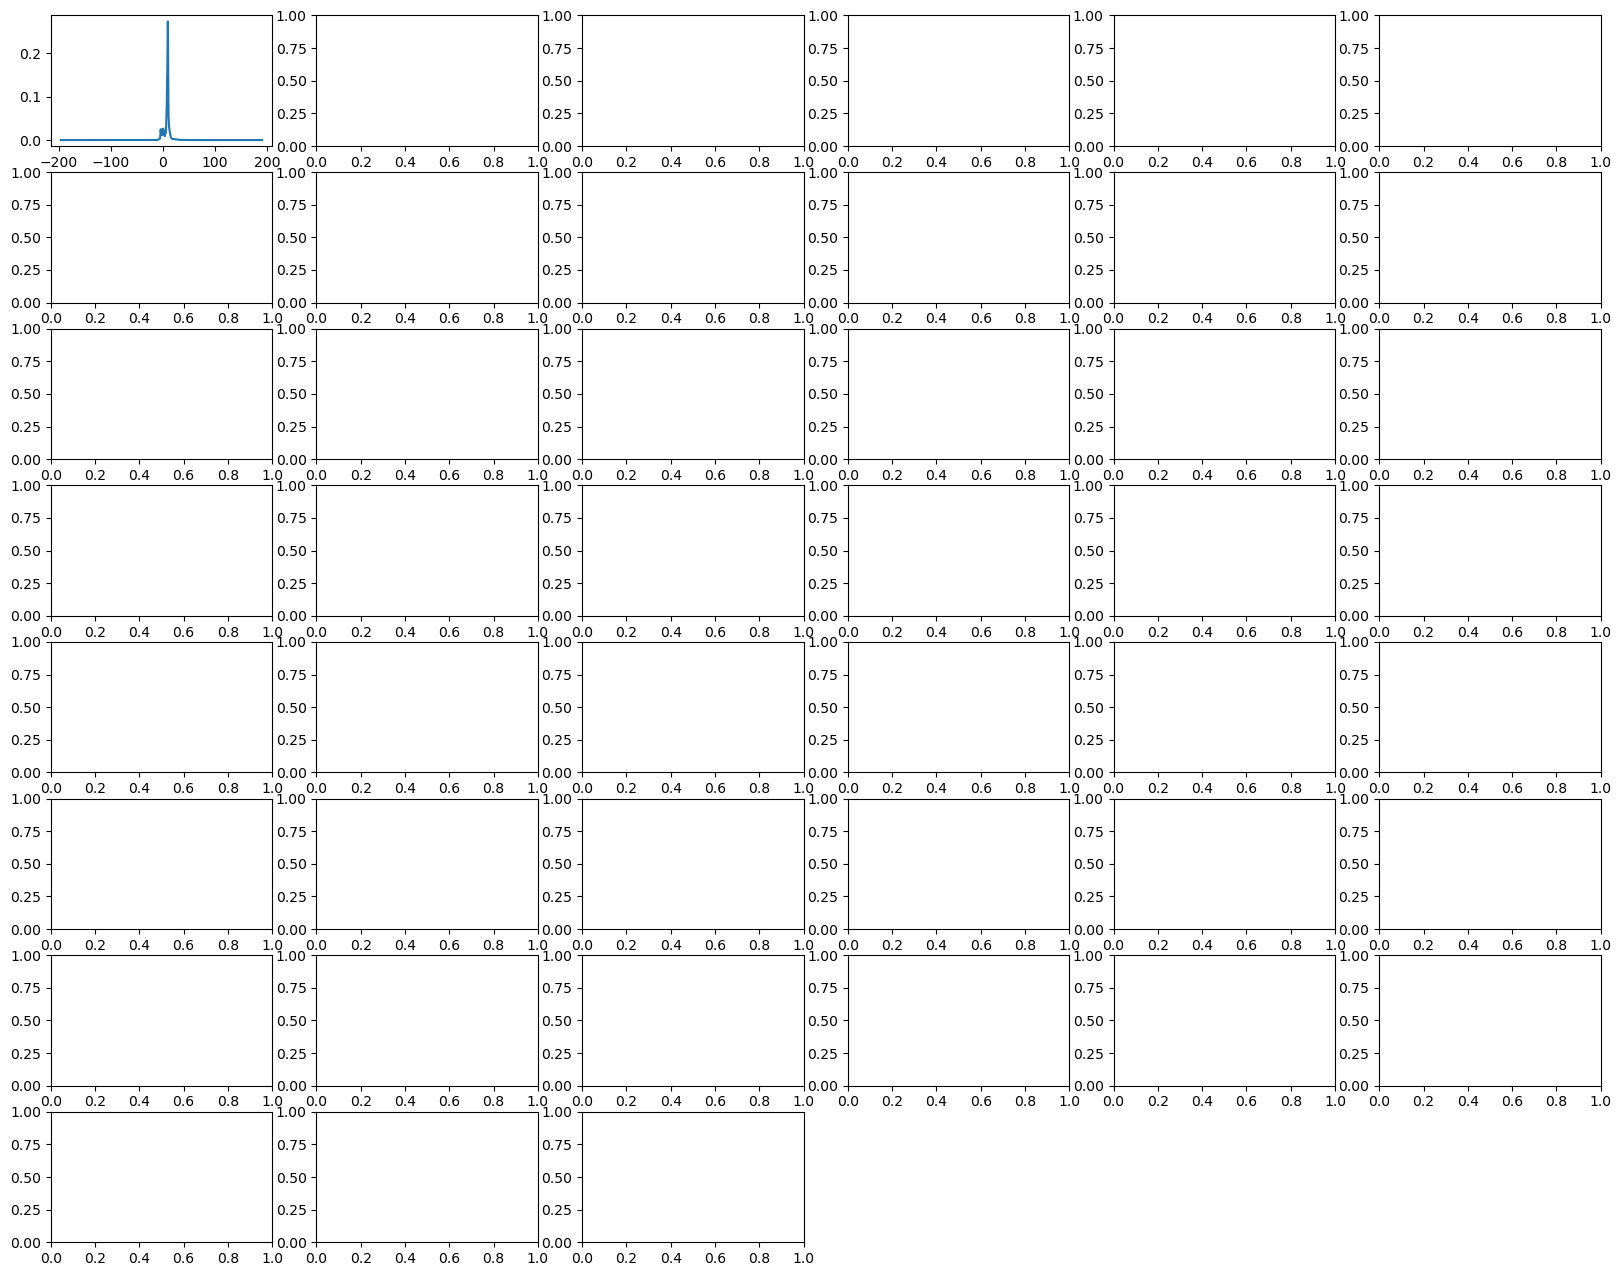

In [57]:
only_sensor_columns.plot(kind='density', subplots=True, layout=(10, 6), figsize=(20, 20), sharex=False)


plt.suptitle("Diagramas de Densidad de los Atributos", fontsize=16)
plt.tight_layout()
plt.show()

## 1.10. Genera la gráfica de cajas y bigotes para la distribución de los atributos de cada base de datos

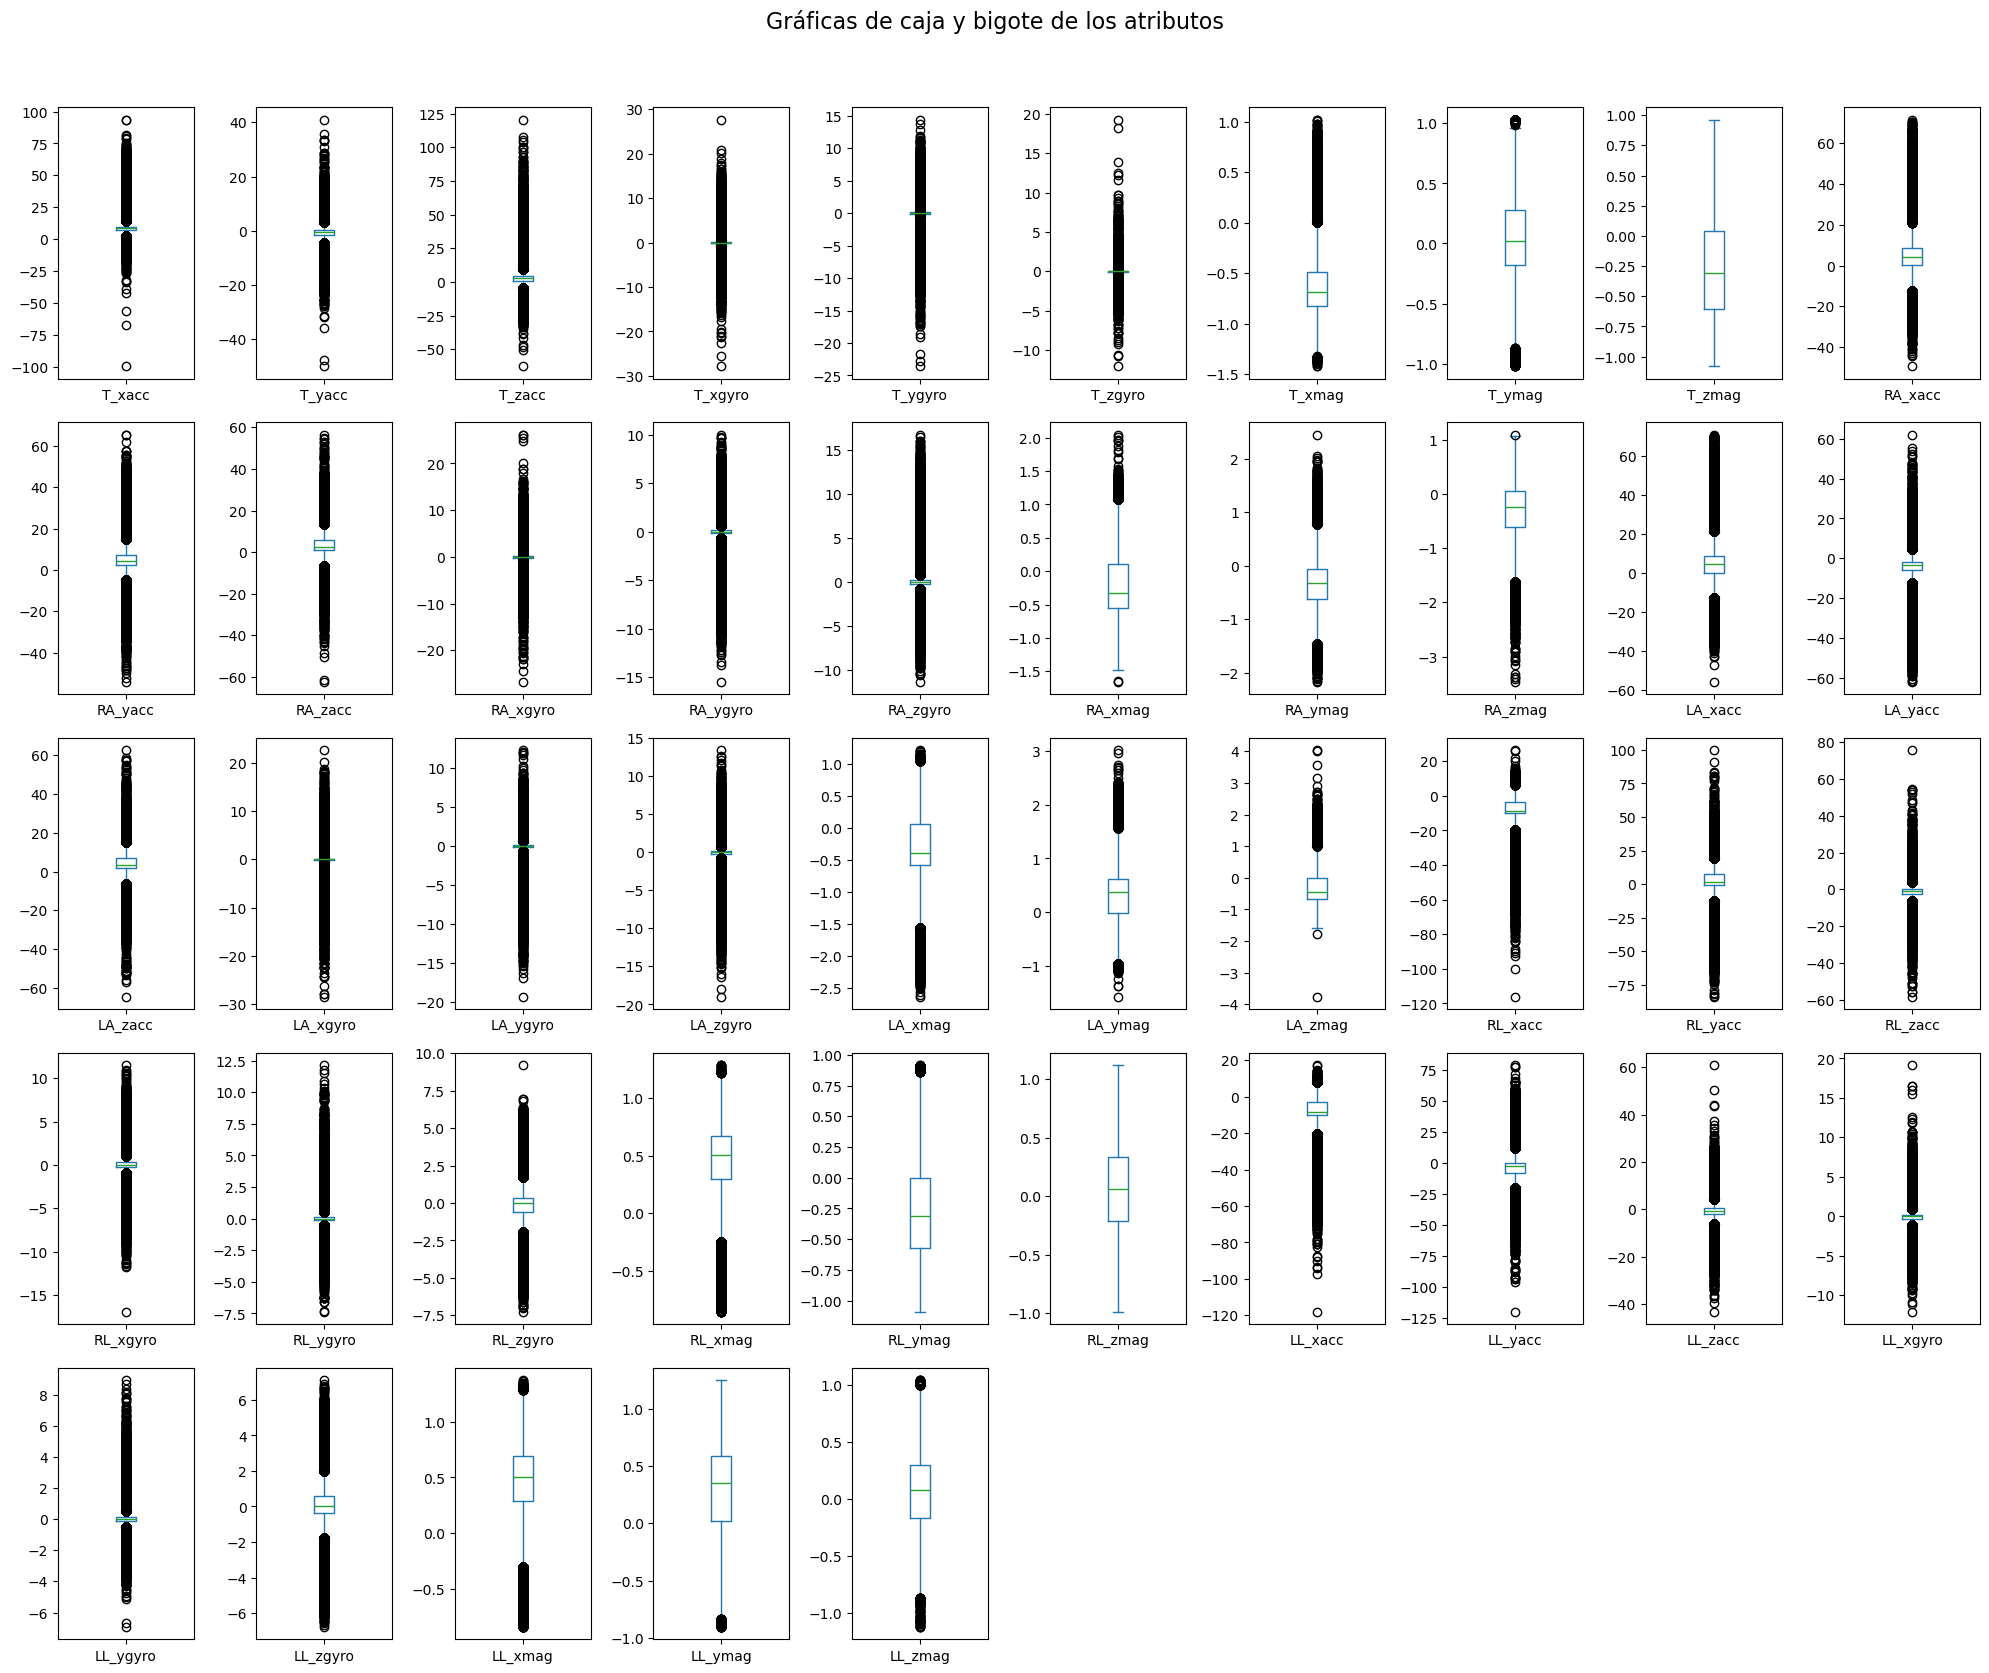

In [65]:
only_sensor_columns.plot(kind='box', subplots=True, layout=(6, 10), figsize=(20, 20), sharex=False)

plt.suptitle("Gráficas de caja y bigote de los atributos", fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

## 1.11. Genera la matriz de correlación de los atributos para cada una de las bases de datos

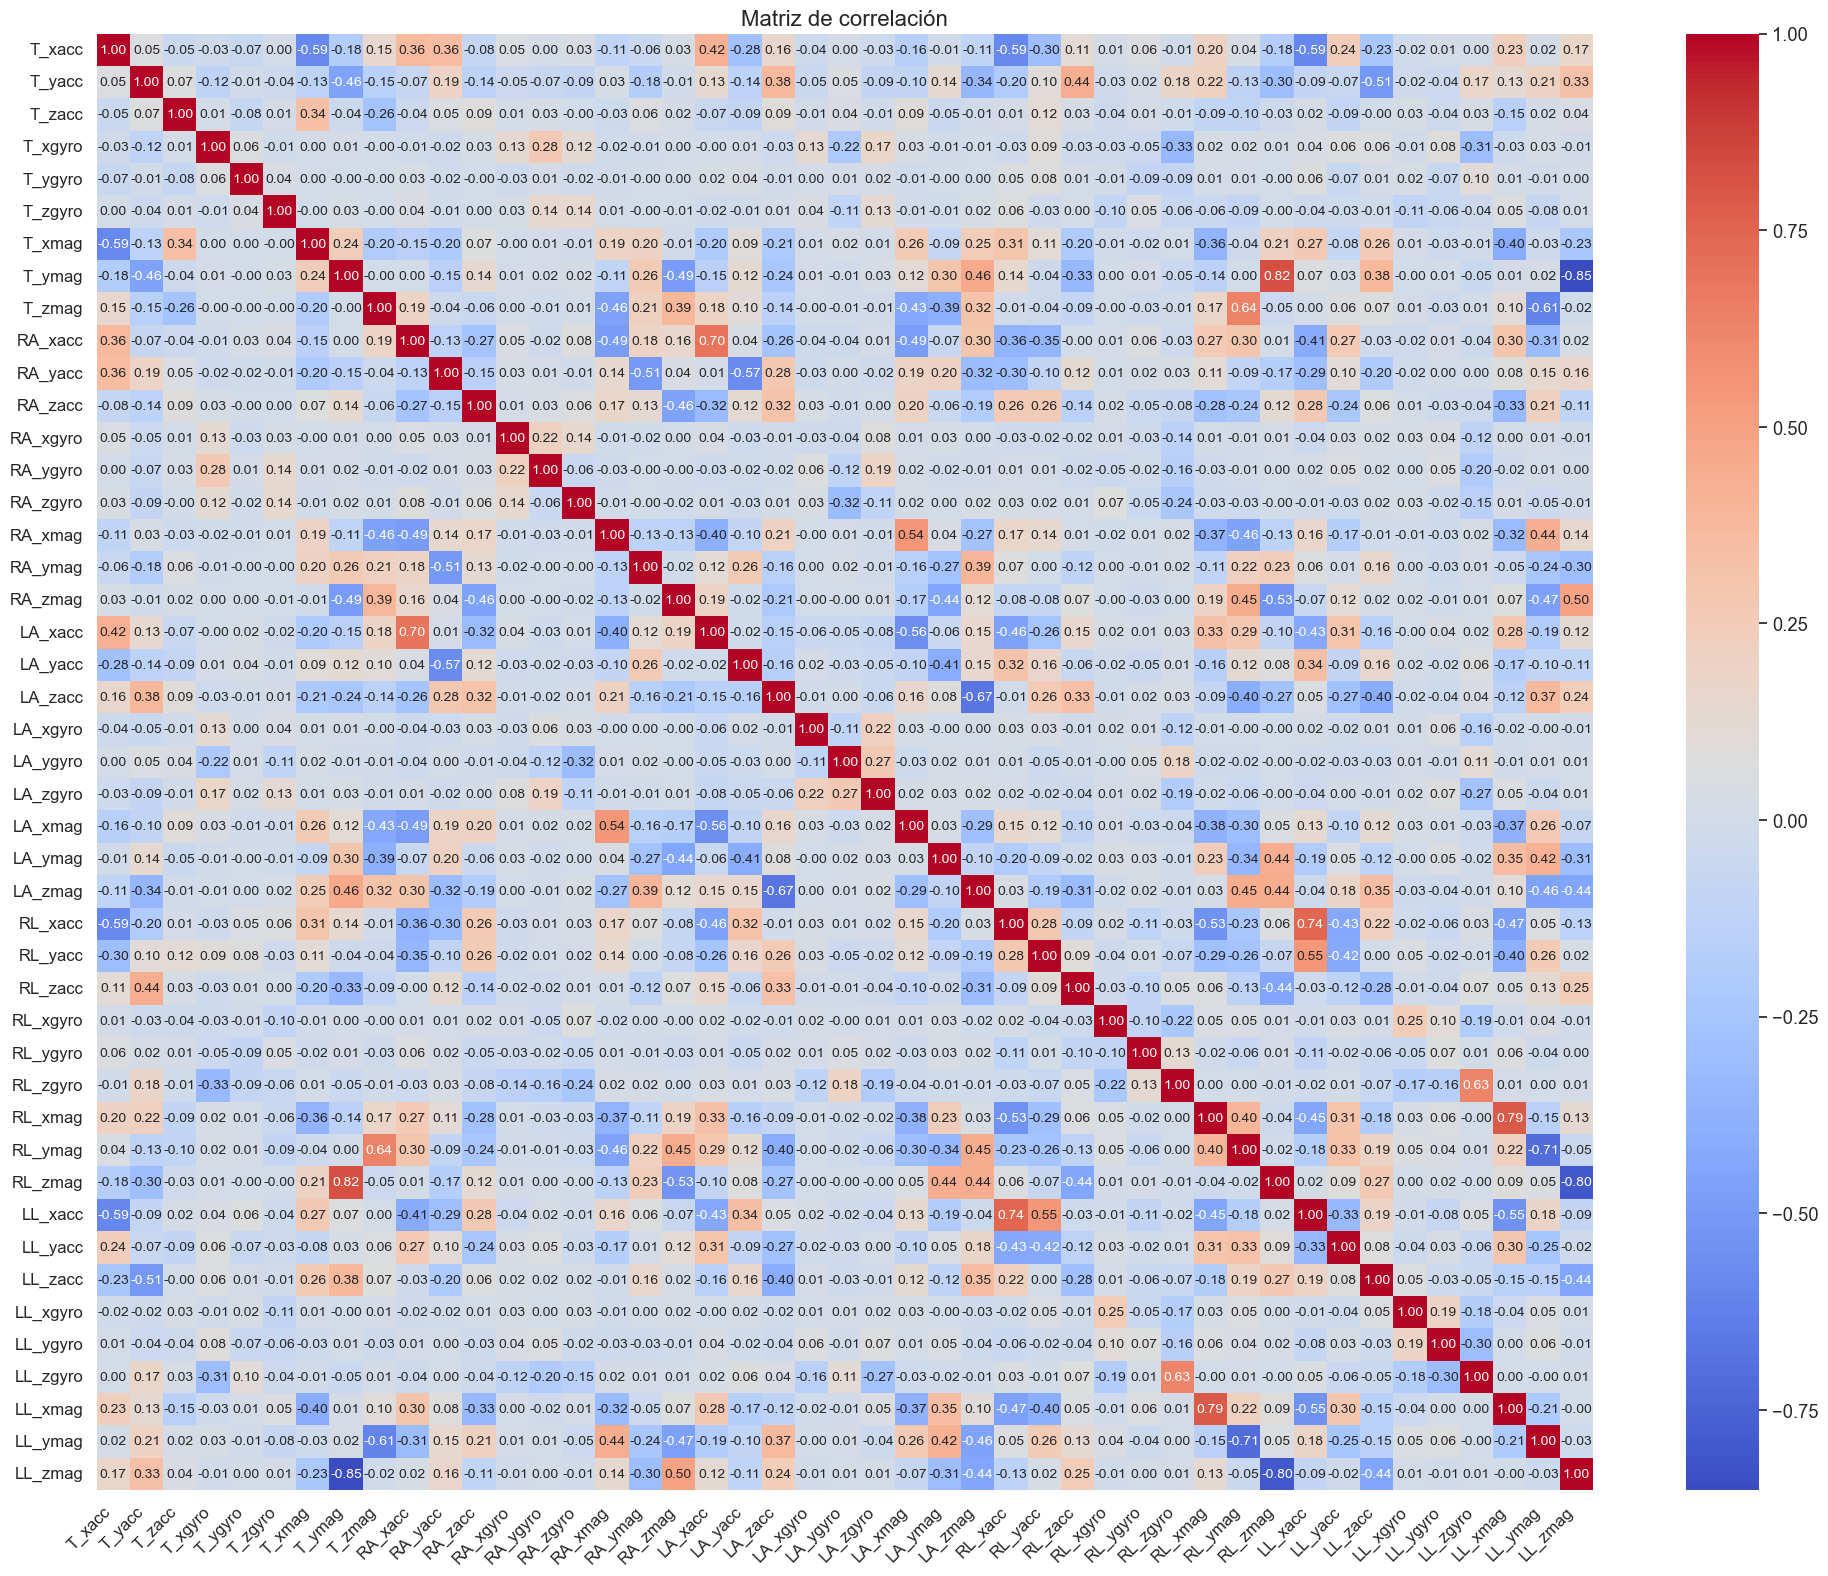

In [23]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set(font_scale=1.2)

plt.figure(figsize=(20, 16))  

sns.heatmap(
    dsa_corr_matrix, 
    annot=True,        # Show numerical values
    fmt=".2f",         
    cmap="coolwarm",
    annot_kws={"size": 10}  # Increase font size for the numbers in cells
)

plt.xticks(rotation=45, ha='right', fontsize=12)
plt.yticks(rotation=0, fontsize=12)

plt.title('Matriz de correlación', fontsize=16)

plt.tight_layout()

# plt.savefig("correlation_matrix_pearson_daily.png", dpi=300, bbox_inches="tight")

plt.show()


In [25]:
threshold = 0.8
high_corr_pairs = []

for i in range(len(dsa_corr_matrix.columns)):
    for j in range(i+1, len(dsa_corr_matrix.columns)):
        corr_value = dsa_corr_matrix.iloc[i, j]
        if abs(corr_value) > threshold:
            high_corr_pairs.append((dsa_corr_matrix.columns[i], dsa_corr_matrix.columns[j], corr_value))

for col1, col2, corr_value in high_corr_pairs:
    print(f"Las columnas '{col1}' y '{col2}' tienen una correlación de {corr_value:.2f}")


Las columnas 'T_ymag' y 'RL_zmag' tienen una correlación de 0.82
Las columnas 'T_ymag' y 'LL_zmag' tienen una correlación de -0.85


## 1.12. Genera la matriz de dispersión de los atributos para cada base de datos

In [ ]:
from pandas.plotting import scatter_matrix

scatter_matrix(only_sensor_columns, figsize=(12, 10), diagonal='hist')

plt.suptitle("Matriz de dispersión de los atributos", fontsize=16)
plt.show()

## 1.13. Aplica escalamiento, normalización o estandarización

Este proceso se realizará después de la extracción de características en la sección: **2.4. Escalamiento, normalización o estandarización de características**

# 2 Segunda entrega: extracción de características

## 2.1. Segmentación por ventanas de tiempo

El dataset viene con las ventanas de tiempo pre-armadas como 5 segundos. Pero nosotros queremos reducirlo hasta 3 segundos. Para esto tendremos que volver a segmentar las mediciones de las actividades. 

Los sensores están a 25Hz y el dataset original los tiene en grupos de 5s, lo que significa que cada grupo de 5s tiene un total de: (5s)(25Hz) = 125 mediciones. Dado que tenemos 60 segmentos de 5s en nuestro dataset original, la cantidad total de mediciones que tenemos para una misma actividad ejecutada por una misma persona son: (60 segmentos)(125 mediciones/segmento) = 7500 mediciones en total.

Si queremos pasarlo a 3 segundos, tendremos ventanas de: (3s)(25Hz) = 75 mediciones. La cantidad total de segmentos que tendremos de una misma actividad ejectuada por una misma persona serán de: (7500 mediciones) / (75 mediciones por segmento) = 100 segmentos.

Nótese que las mediciones encajan perfectamente en las ventanas de tiempo.

In [47]:
def segmentar_por_3s(df, window_size=75):
    df_segmentado_list = []
    
    # Agrupamos por actividad y persona
    for (actividad, persona), grupo in df.groupby(['activity_label', 'person_id']):
        # Calculamos cuántas ventanas completas se pueden formar en este grupo
        n_segmentos = len(grupo) // window_size
        
        # Si no hay suficientes filas para una ventana completa, se omite este grupo
        if n_segmentos == 0:
            continue
        
        # Seleccionamos solo las filas que completan ventanas completas
        grupo_completo = grupo.iloc[:n_segmentos * window_size].copy()
        grupo_completo.reset_index(drop=True, inplace=True)
        
        # Creamos un índice de segmento para cada ventana
        grupo_completo['segment_index'] = grupo_completo.index // window_size
        
        # Generamos el identificador único concatenando actividad, persona y el índice del segmento
        grupo_completo['segment_3s'] = grupo_completo.apply(
            lambda row: f"{actividad}{persona}{int(row['segment_index'])}", axis=1
        )
        
        df_segmentado_list.append(grupo_completo)
    
    # Concatenamos todos los grupos procesados en un único DataFrame
    return pd.concat(df_segmentado_list, ignore_index=True)

df_unsegmented = dsa_df

df_segmented = segmentar_por_3s(df_unsegmented)
df_segmented

,T_xacc,T_yacc,T_zacc,T_xgyro,T_ygyro,T_zgyro,T_xmag,T_ymag,T_zmag,RA_xacc,RA_yacc,RA_zacc,RA_xgyro,RA_ygyro,RA_zgyro,RA_xmag,RA_ymag,RA_zmag,LA_xacc,LA_yacc,LA_zacc,LA_xgyro,LA_ygyro,LA_zgyro,LA_xmag,LA_ymag,LA_zmag,RL_xacc,RL_yacc,RL_zacc,RL_xgyro,RL_ygyro,RL_zgyro,RL_xmag,RL_ymag,RL_zmag,LL_xacc,LL_yacc,LL_zacc,LL_xgyro,LL_ygyro,LL_zgyro,LL_xmag,LL_ymag,LL_zmag,activity_label,person_id,segment,segment_index,segment_3s
0,8.130,1.035,5.422,-0.009,0.002,-0.003,-0.787,-0.070,0.157,0.701,5.683,7.981,0.004,-0.005,-0.001,-0.573,-0.559,-0.212,3.419,-8.342,3.863,-0.005,-0.008,-0.016,-0.648,0.341,0.074,-3.516,9.051,-0.933,0.005,0.008,-0.014,0.730,-0.254,-0.036,-2.807,-9.081,2.622,-0.000,-0.012,-0.004,0.740,0.301,-0.058,a01,p1,a01p1s01.txt,0,a01p10
1,8.130,1.020,5.384,-0.009,0.023,0.002,-0.787,-0.068,0.159,0.718,5.601,7.971,0.013,-0.005,-0.003,-0.573,-0.557,-0.213,3.434,-8.371,3.854,-0.014,-0.002,-0.005,-0.648,0.342,0.075,-3.539,9.081,-0.933,0.014,0.003,-0.012,0.732,-0.252,-0.034,-2.815,-9.074,2.622,-0.015,-0.016,0.003,0.739,0.302,-0.058,a01,p1,a01p1s01.txt,0,a01p10
2,8.160,1.020,5.362,0.015,0.014,0.000,-0.787,-0.068,0.159,0.698,5.661,7.957,0.022,-0.010,0.012,-0.574,-0.558,-0.213,3.429,-8.376,3.876,0.000,-0.008,-0.012,-0.648,0.341,0.073,-3.538,9.066,-0.926,-0.010,0.011,-0.008,0.729,-0.252,-0.036,-2.822,-9.089,2.637,-0.013,0.006,-0.008,0.740,0.301,-0.057,a01,p1,a01p1s01.txt,0,a01p10
3,8.160,1.005,5.377,0.007,0.018,0.006,-0.785,-0.070,0.159,0.728,5.639,7.976,0.016,0.002,0.002,-0.605,-0.568,-0.245,3.444,-8.327,3.829,0.000,0.004,-0.011,-0.648,0.341,0.074,-3.538,9.059,-0.941,0.001,0.008,-0.003,0.731,-0.252,-0.036,-2.807,-9.081,2.607,-0.006,0.010,0.007,0.740,0.302,-0.058,a01,p1,a01p1s01.txt,0,a01p10
4,8.161,1.028,5.347,0.009,0.030,-0.005,-0.787,-0.069,0.159,0.716,5.644,7.971,0.000,-0.003,0.002,-0.569,-0.560,-0.214,3.449,-8.371,3.847,-0.013,0.004,-0.005,-0.649,0.342,0.076,-3.531,9.081,-0.933,-0.010,-0.003,0.004,0.730,-0.252,-0.034,-2.815,-9.074,2.622,-0.004,-0.008,0.003,0.738,0.301,-0.058,a01,p1,a01p1s01.txt,0,a01p10
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1139995,16.008,-2.017,-0.582,2.027,1.657,0.584,-0.732,-0.476,-0.013,16.431,15.668,-1.367,3.786,0.259,6.116,-0.674,-0.529,-0.102,-12.331,-3.756,6.841,-1.014,-0.796,0.138,0.450,0.657,-0.330,-24.517,-3.180,-20.426,0.986,-0.073,-4.134,0.923,-0.070,-0.079,-10.752,4.323,-4.593,-0.231,0.181,-2.082,0.569,0.394,0.518,a19,p8,a19p8s60.txt,99,a19p899
1139996,8.282,-0.699,0.487,2.888,1.604,-0.020,-0.731,-0.472,-0.012,7.016,20.931,2.397,3.196,0.221,4.173,-0.775,-0.393,-0.047,-4.380,-5.148,6.548,0.320,-0.619,-0.339,0.437,0.665,-0.328,-27.037,15.918,5.012,-1.311,-0.769,-3.636,0.908,0.129,-0.031,-5.184,1.255,-4.111,1.817,0.313,-1.022,0.538,0.437,0.504,a19,p8,a19p8s60.txt,99,a19p899
1139997,2.712,0.500,0.841,1.996,1.466,-0.073,-0.725,-0.479,-0.013,-4.554,21.249,-0.253,3.746,0.392,2.469,-0.820,-0.298,0.002,3.017,-4.216,5.155,3.439,-0.213,-0.943,0.416,0.651,-0.375,-11.025,30.442,1.266,1.000,-0.606,-1.423,0.817,0.149,-0.063,-1.035,15.694,1.294,1.842,0.349,-0.282,0.518,0.473,0.489,a19,p8,a19p8s60.txt,99,a19p899
1139998,2.031,-0.713,-0.113,1.766,1.010,-0.102,-0.719,-0.482,-0.011,-6.857,26.424,5.241,1.696,-0.268,-0.388,-0.827,-0.263,0.040,5.191,-0.703,3.467,1.913,0.990,-2.388,0.377,0.632,-0.434,0.911,22.042,-1.651,-1.364,0.264,0.845,0.816,0.176,-0.195,-3.648,-7.463,-12.364,-0.150,1.563,-0.368,0.504,0.510,0.446,a19,p8,a19p8s60.txt,99,a19p899


In [49]:
df_segmented.groupby(['activity_label', 'person_id'])['segment_3s'].nunique()

activity_label  person_id
a01             p1           100
                p2           100
                p3           100
                p4           100
                p5           100
                            ... 
a19             p4           100
                p5           100
                p6           100
                p7           100
                p8           100
Name: segment_3s, Length: 152, dtype: int64

Observamos que cada actividad ejecutada por cada persona tiene exactamente 100 mediciones, por lo que se realizaó de manera correcta la segmnetación.

## 2.2. Extracción de características

In [42]:
import numpy as np

class InertialSensor:
    def __init__(self, x, y, z):
        """
        Inicializa el acelerómetro con sus 3 señales.
        
        Parámetros:
          x: array-like, señal del eje x.
          y: array-like, señal del eje y.
          z: array-like, señal del eje z.
        """
        self.x = np.array(x)
        self.y = np.array(y)
        self.z = np.array(z)
        
    def compute_magnitude(self):
        return np.sqrt(self.x**2 + self.y**2 + self.z**2)
    
    def extract_features(self):
        # 1. Medias de cada eje
        mean_x = np.mean(self.x)
        mean_y = np.mean(self.y)
        mean_z = np.mean(self.z)
        
        # 2. Desviaciones estándar
        std_x = np.std(self.x)
        std_y = np.std(self.y)
        std_z = np.std(self.z)
        
        # 3. Valores máximos
        max_x = np.max(self.x)
        max_y = np.max(self.y)
        max_z = np.max(self.z)
        
        # 4. Correlaciones entre cada par de ejes
        corr_xy = np.corrcoef(self.x, self.y)[0, 1]
        corr_xz = np.corrcoef(self.x, self.z)[0, 1]
        corr_yz = np.corrcoef(self.y, self.z)[0, 1]
        
        # 5,6,7,8. Features derivadas de la magnitud
        magnitude = self.compute_magnitude()
        mean_magnitude = np.mean(magnitude)
        std_magnitude = np.std(magnitude)
        auc = np.sum(magnitude)
        mean_diff = np.mean(np.diff(magnitude)) if len(magnitude) > 1 else 0.0
        
        # Vector de features
        feature_vector = np.array([
            mean_x, mean_y, mean_z,
            std_x, std_y, std_z,
            max_x, max_y, max_z,
            corr_xy, corr_xz, corr_yz,
            mean_magnitude, std_magnitude, auc, mean_diff
        ])
        
        return feature_vector

Ahora generamos el dataset con las features de cada ejemplo y sus labels.

In [100]:
import numpy as np
import pandas as pd

df_to_extract_features = df_segmented

numeric_features_list = []
labels = []

for seg, group in df_to_extract_features.groupby("segment_3s"):
    # Torso
    T_features = InertialSensor(group.T_xacc, group.T_yacc, group.T_zacc).extract_features()
    T_gyro_features = InertialSensor(group.T_xgyro, group.T_ygyro, group.T_zgyro).extract_features()
    T_mag_features = InertialSensor(group.T_xmag, group.T_ymag, group.T_zmag).extract_features()

    # Right Arm
    RA_features = InertialSensor(group.RA_xacc, group.RA_yacc, group.RA_zacc).extract_features()
    RA_gyro_features = InertialSensor(group.RA_xgyro, group.RA_ygyro, group.RA_zgyro).extract_features()
    RA_mag_features = InertialSensor(group.RA_xmag, group.RA_ymag, group.RA_zmag).extract_features()

    # Left Arm
    LA_features = InertialSensor(group.LA_xacc, group.LA_yacc, group.LA_zacc).extract_features()
    LA_gyro_features = InertialSensor(group.LA_xgyro, group.LA_ygyro, group.LA_zgyro).extract_features()
    LA_mag_features = InertialSensor(group.LA_xmag, group.LA_ymag, group.LA_zmag).extract_features()

    # Right Leg
    RL_features = InertialSensor(group.RL_xacc, group.RL_yacc, group.RL_zacc).extract_features()
    RL_gyro_features = InertialSensor(group.RL_xgyro, group.RL_ygyro, group.RL_zgyro).extract_features()
    RL_mag_features = InertialSensor(group.RL_xmag, group.RL_ymag, group.RL_zmag).extract_features()

    # Left Leg
    LL_features = InertialSensor(group.LL_xacc, group.LL_yacc, group.LL_zacc).extract_features()
    LL_gyro_features = InertialSensor(group.LL_xgyro, group.LL_ygyro, group.LL_zgyro).extract_features()
    LL_mag_features = InertialSensor(group.LL_xmag, group.LL_ymag, group.LL_zmag).extract_features()
    
    # Combine all feature sets into one row and convert numeric values to float
    feature_vector = np.concatenate([
        T_features, T_gyro_features, T_mag_features,
        RA_features, RA_gyro_features, RA_mag_features,
        LA_features, LA_gyro_features, LA_mag_features,
        RL_features, RL_gyro_features, RL_mag_features,
        LL_features, LL_gyro_features, LL_mag_features
    ]).astype(float)
    
    numeric_features_list.append(feature_vector)
    labels.append(group["activity_label"].iloc[0])

# Generate feature column names
sensor_locations = ["T", "RA", "LA", "RL", "LL"]
sensor_types = ["acc", "gyro", "mag"]
feature_names = [
    "mean_x", "mean_y", "mean_z", "std_x", "std_y", "std_z",
    "max_x", "max_y", "max_z", "corr_xy", "corr_xz", "corr_yz",
    "mean_mag", "std_mag", "auc", "mean_diff"
]

feature_columns = [
    f"{loc}_{typ}_{feat}"
    for loc in sensor_locations
    for typ in sensor_types
    for feat in feature_names
]

# Create DataFrame for numeric features and convert to float
df_numeric = pd.DataFrame(np.array(numeric_features_list), columns=feature_columns)

# Create DataFrame for labels
df_labels = pd.DataFrame(labels, columns=["activity"])

# Concatenate numeric features and labels
examples_db = pd.concat([df_numeric, df_labels], axis=1)

# Optionally, check the data types to confirm
examples_db

,T_acc_mean_x,T_acc_mean_y,T_acc_mean_z,T_acc_std_x,T_acc_std_y,T_acc_std_z,T_acc_max_x,T_acc_max_y,T_acc_max_z,T_acc_corr_xy,T_acc_corr_xz,T_acc_corr_yz,T_acc_mean_mag,T_acc_std_mag,T_acc_auc,T_acc_mean_diff,T_gyro_mean_x,T_gyro_mean_y,T_gyro_mean_z,T_gyro_std_x,T_gyro_std_y,T_gyro_std_z,T_gyro_max_x,T_gyro_max_y,T_gyro_max_z,T_gyro_corr_xy,T_gyro_corr_xz,T_gyro_corr_yz,T_gyro_mean_mag,T_gyro_std_mag,T_gyro_auc,T_gyro_mean_diff,T_mag_mean_x,T_mag_mean_y,T_mag_mean_z,T_mag_std_x,T_mag_std_y,T_mag_std_z,T_mag_max_x,T_mag_max_y,T_mag_max_z,T_mag_corr_xy,T_mag_corr_xz,T_mag_corr_yz,T_mag_mean_mag,T_mag_std_mag,T_mag_auc,T_mag_mean_diff,RA_acc_mean_x,RA_acc_mean_y,RA_acc_mean_z,RA_acc_std_x,RA_acc_std_y,RA_acc_std_z,RA_acc_max_x,RA_acc_max_y,RA_acc_max_z,RA_acc_corr_xy,RA_acc_corr_xz,RA_acc_corr_yz,RA_acc_mean_mag,RA_acc_std_mag,RA_acc_auc,RA_acc_mean_diff,RA_gyro_mean_x,RA_gyro_mean_y,RA_gyro_mean_z,RA_gyro_std_x,RA_gyro_std_y,RA_gyro_std_z,RA_gyro_max_x,RA_gyro_max_y,RA_gyro_max_z,RA_gyro_corr_xy,RA_gyro_corr_xz,RA_gyro_corr_yz,RA_gyro_mean_mag,RA_gyro_std_mag,RA_gyro_auc,RA_gyro_mean_diff,RA_mag_mean_x,RA_mag_mean_y,RA_mag_mean_z,RA_mag_std_x,RA_mag_std_y,RA_mag_std_z,RA_mag_max_x,RA_mag_max_y,RA_mag_max_z,RA_mag_corr_xy,RA_mag_corr_xz,RA_mag_corr_yz,RA_mag_mean_mag,RA_mag_std_mag,RA_mag_auc,RA_mag_mean_diff,LA_acc_mean_x,LA_acc_mean_y,LA_acc_mean_z,LA_acc_std_x,LA_acc_std_y,LA_acc_std_z,LA_acc_max_x,LA_acc_max_y,LA_acc_max_z,LA_acc_corr_xy,LA_acc_corr_xz,LA_acc_corr_yz,LA_acc_mean_mag,LA_acc_std_mag,LA_acc_auc,LA_acc_mean_diff,LA_gyro_mean_x,LA_gyro_mean_y,LA_gyro_mean_z,LA_gyro_std_x,LA_gyro_std_y,LA_gyro_std_z,LA_gyro_max_x,LA_gyro_max_y,LA_gyro_max_z,LA_gyro_corr_xy,LA_gyro_corr_xz,LA_gyro_corr_yz,LA_gyro_mean_mag,LA_gyro_std_mag,LA_gyro_auc,LA_gyro_mean_diff,LA_mag_mean_x,LA_mag_mean_y,LA_mag_mean_z,LA_mag_std_x,LA_mag_std_y,LA_mag_std_z,LA_mag_max_x,LA_mag_max_y,LA_mag_max_z,LA_mag_corr_xy,LA_mag_corr_xz,LA_mag_corr_yz,LA_mag_mean_mag,LA_mag_std_mag,LA_mag_auc,LA_mag_mean_diff,RL_acc_mean_x,RL_acc_mean_y,RL_acc_mean_z,RL_acc_std_x,RL_acc_std_y,RL_acc_std_z,RL_acc_max_x,RL_acc_max_y,RL_acc_max_z,RL_acc_corr_xy,RL_acc_corr_xz,RL_acc_corr_yz,RL_acc_mean_mag,RL_acc_std_mag,RL_acc_auc,RL_acc_mean_diff,RL_gyro_mean_x,RL_gyro_mean_y,RL_gyro_mean_z,RL_gyro_std_x,RL_gyro_std_y,RL_gyro_std_z,RL_gyro_max_x,RL_gyro_max_y,RL_gyro_max_z,RL_gyro_corr_xy,RL_gyro_corr_xz,RL_gyro_corr_yz,RL_gyro_mean_mag,RL_gyro_std_mag,RL_gyro_auc,RL_gyro_mean_diff,RL_mag_mean_x,RL_mag_mean_y,RL_mag_mean_z,RL_mag_std_x,RL_mag_std_y,RL_mag_std_z,RL_mag_max_x,RL_mag_max_y,RL_mag_max_z,RL_mag_corr_xy,RL_mag_corr_xz,RL_mag_corr_yz,RL_mag_mean_mag,RL_mag_std_mag,RL_mag_auc,RL_mag_mean_diff,LL_acc_mean_x,LL_acc_mean_y,LL_acc_mean_z,LL_acc_std_x,LL_acc_std_y,LL_acc_std_z,LL_acc_max_x,LL_acc_max_y,LL_acc_max_z,LL_acc_corr_xy,LL_acc_corr_xz,LL_acc_corr_yz,LL_acc_mean_mag,LL_acc_std_mag,LL_acc_auc,LL_acc_mean_diff,LL_gyro_mean_x,LL_gyro_mean_y,LL_gyro_mean_z,LL_gyro_std_x,LL_gyro_std_y,LL_gyro_std_z,LL_gyro_max_x,LL_gyro_max_y,LL_gyro_max_z,LL_gyro_corr_xy,LL_gyro_corr_xz,LL_gyro_corr_yz,LL_gyro_mean_mag,LL_gyro_std_mag,LL_gyro_auc,LL_gyro_mean_diff,LL_mag_mean_x,LL_mag_mean_y,LL_mag_mean_z,LL_mag_std_x,LL_mag_std_y,LL_mag_std_z,LL_mag_max_x,LL_mag_max_y,LL_mag_max_z,LL_mag_corr_xy,LL_mag_corr_xz,LL_mag_corr_yz,LL_mag_mean_mag,LL_mag_std_mag,LL_mag_auc,LL_mag_mean_diff,activity
0,8.016,1.058,5.554,0.129,0.040,0.192,8.161,1.176,6.181,-0.819,-0.915,0.764,9.812,0.046,735.867,-0.001,0.008,0.038,-0.004,0.015,0.036,0.008,0.045,0.215,0.016,0.479,0.123,-0.251,0.046,0.032,3.415,-0.000,-0.790,-0.068,0.141,0.003,0.002,0.017,-0.785,-0.064,0.159,-0.798,0.981,-0.823,0.805,0.001,60.397,-0.000,0.702,5.677,7.951,0.026,0.038,0.029,0.759,5.756,8.001,-0.390,0.198,-0.505,9.795,0.022,734.610,-0.000,0.011,-0.002,-0.002,0.010,0.007,0.008,0.039,0.014,0.014,0.019,-0.173,0.002,0.017,0.008,1.259,0.000,-0.570,-0.560,-0.213,0.007,0.003,0.006,-0.538,-0.548,-0.184,0.706,0.966,0.736,0.827,0.008,62

In [102]:
examples_db.dtypes

T_acc_mean_x        float64
T_acc_mean_y        float64
T_acc_mean_z        float64
T_acc_std_x         float64
T_acc_std_y         float64
                     ...   
LL_mag_mean_mag     float64
LL_mag_std_mag      float64
LL_mag_auc          float64
LL_mag_mean_diff    float64
activity             object
Length: 241, dtype: object

Esperamos tener 15,200 filas, esto porque los ejemplos son:

- (18 personas) (9 actividades) (100 ejemplos usando ventanas de 3s) = 15,200 ejemplos

Esperamos tener 240 columnas de características + 1 columna de la etiqueta de la actividad

- (16 características por sensor) (15 sensores) + 1 label = 240 features + 1 label = 241 columnas

In [106]:
examples_db.shape

(15200, 241)

Histograma de las características

In [120]:
import math
import numpy as np
import matplotlib.pyplot as plt

# Drop 'activity' column if it exists, keeping only numeric columns
examples_db_numeric = examples_db.drop(columns=["activity"], errors="ignore")

# Number of numeric columns
num_features = len(examples_db_numeric.columns)

# We'll create an n x n grid, where n is the ceiling of the square root of the number of features
n = math.ceil(math.sqrt(num_features))

# Increase the figure size depending on how many features you have
figsize = (6 * n, 4 * n)

# Create the histograms in a grid layout
axes = examples_db_numeric.hist(
    bins=10,
    figsize=figsize,
    layout=(n, n),     # n rows, n columns
    sharex=False,
    sharey=False
)

# If axes is a 2D numpy array, flatten it so we can iterate easily
if isinstance(axes, np.ndarray):
    axes = axes.flatten()
else:
    axes = [axes]

# Adjust each subplot for better readability
for ax in axes:
    # Rotate the x-axis labels
    ax.tick_params(axis='x', labelrotation=45, labelsize=8)
    ax.tick_params(axis='y', labelsize=8)
    # Optionally reduce title font size
    ax.set_title(ax.get_title(), fontsize=9)

# Adjust spacing between subplots
plt.subplots_adjust(wspace=0.4, hspace=0.4)

# Add a main title
plt.suptitle("Histogramas de las características", fontsize=16, y=1.02)

# Use tight_layout with a rect so the suptitle doesn't overlap subplots
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()


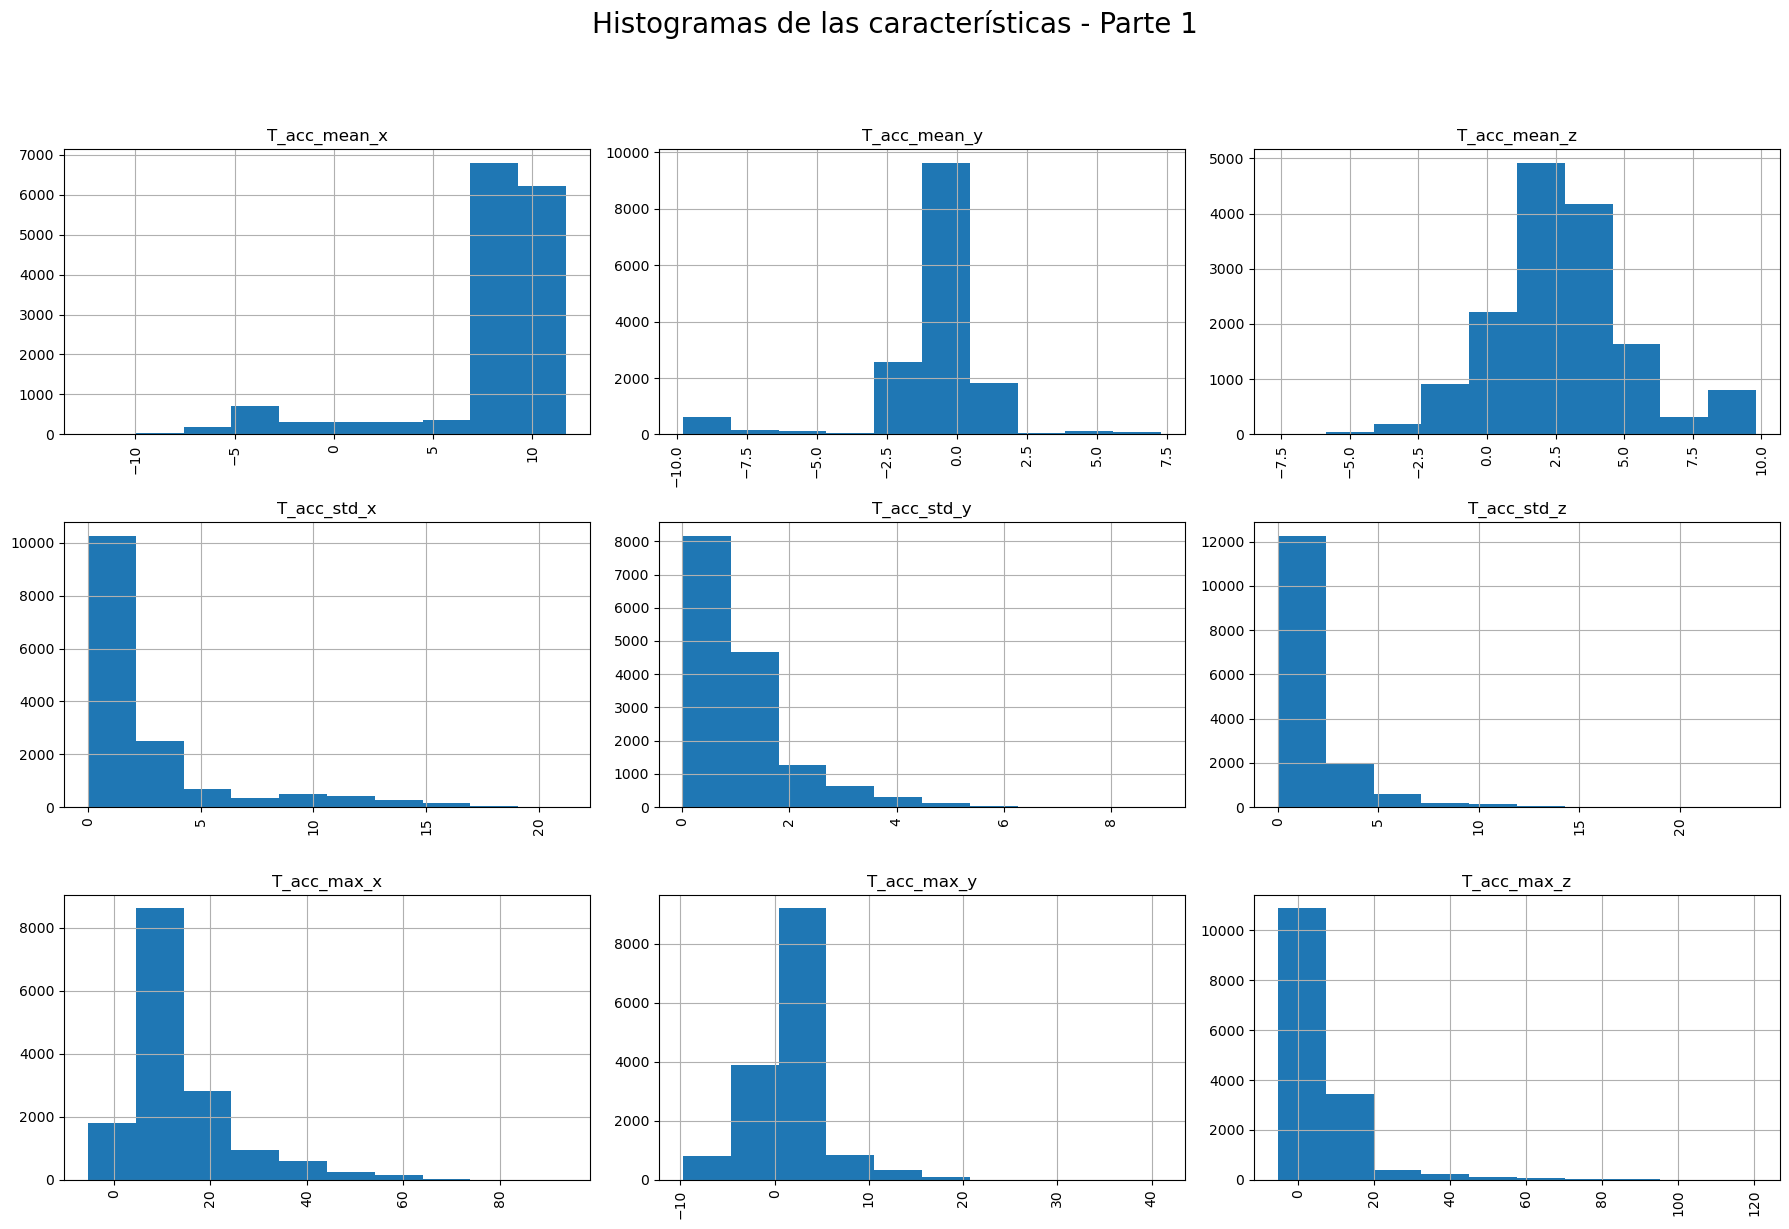

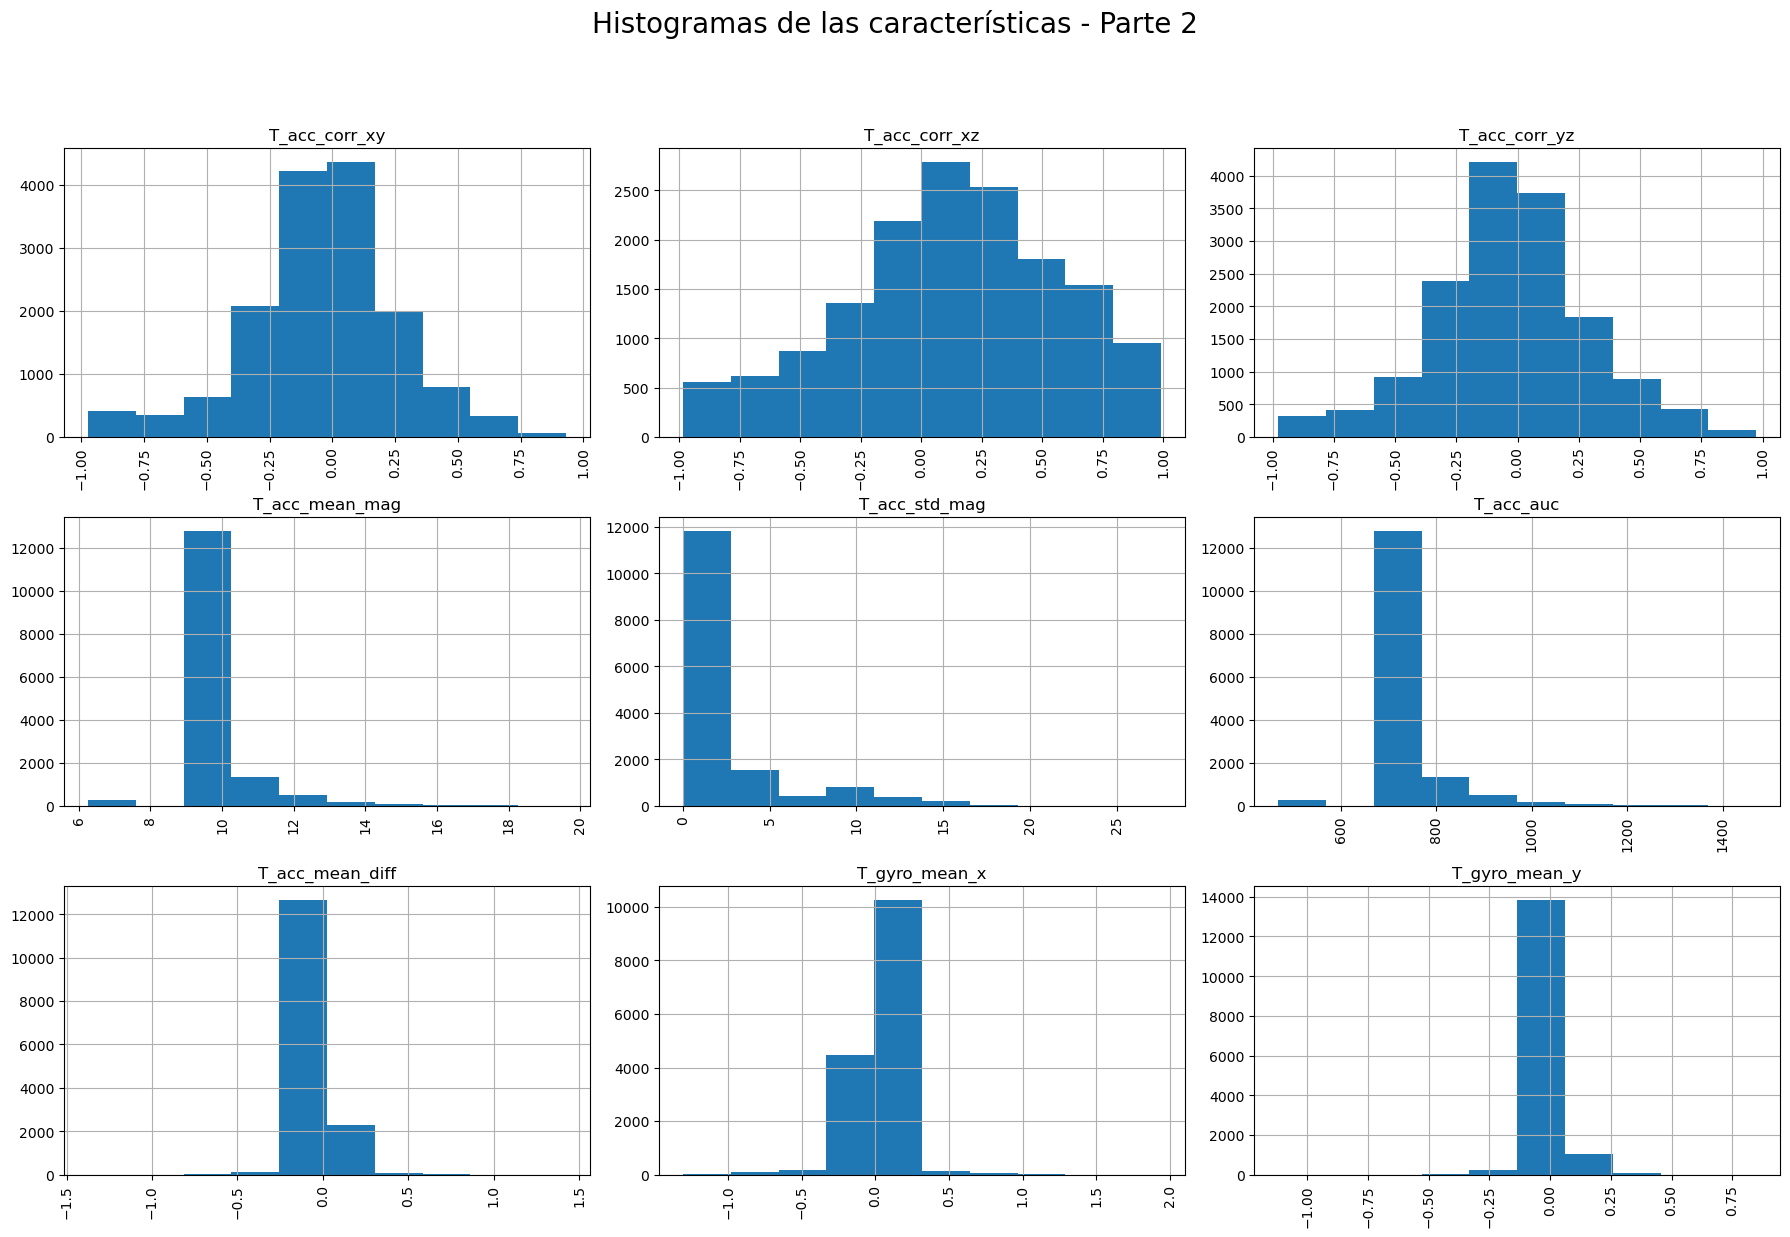

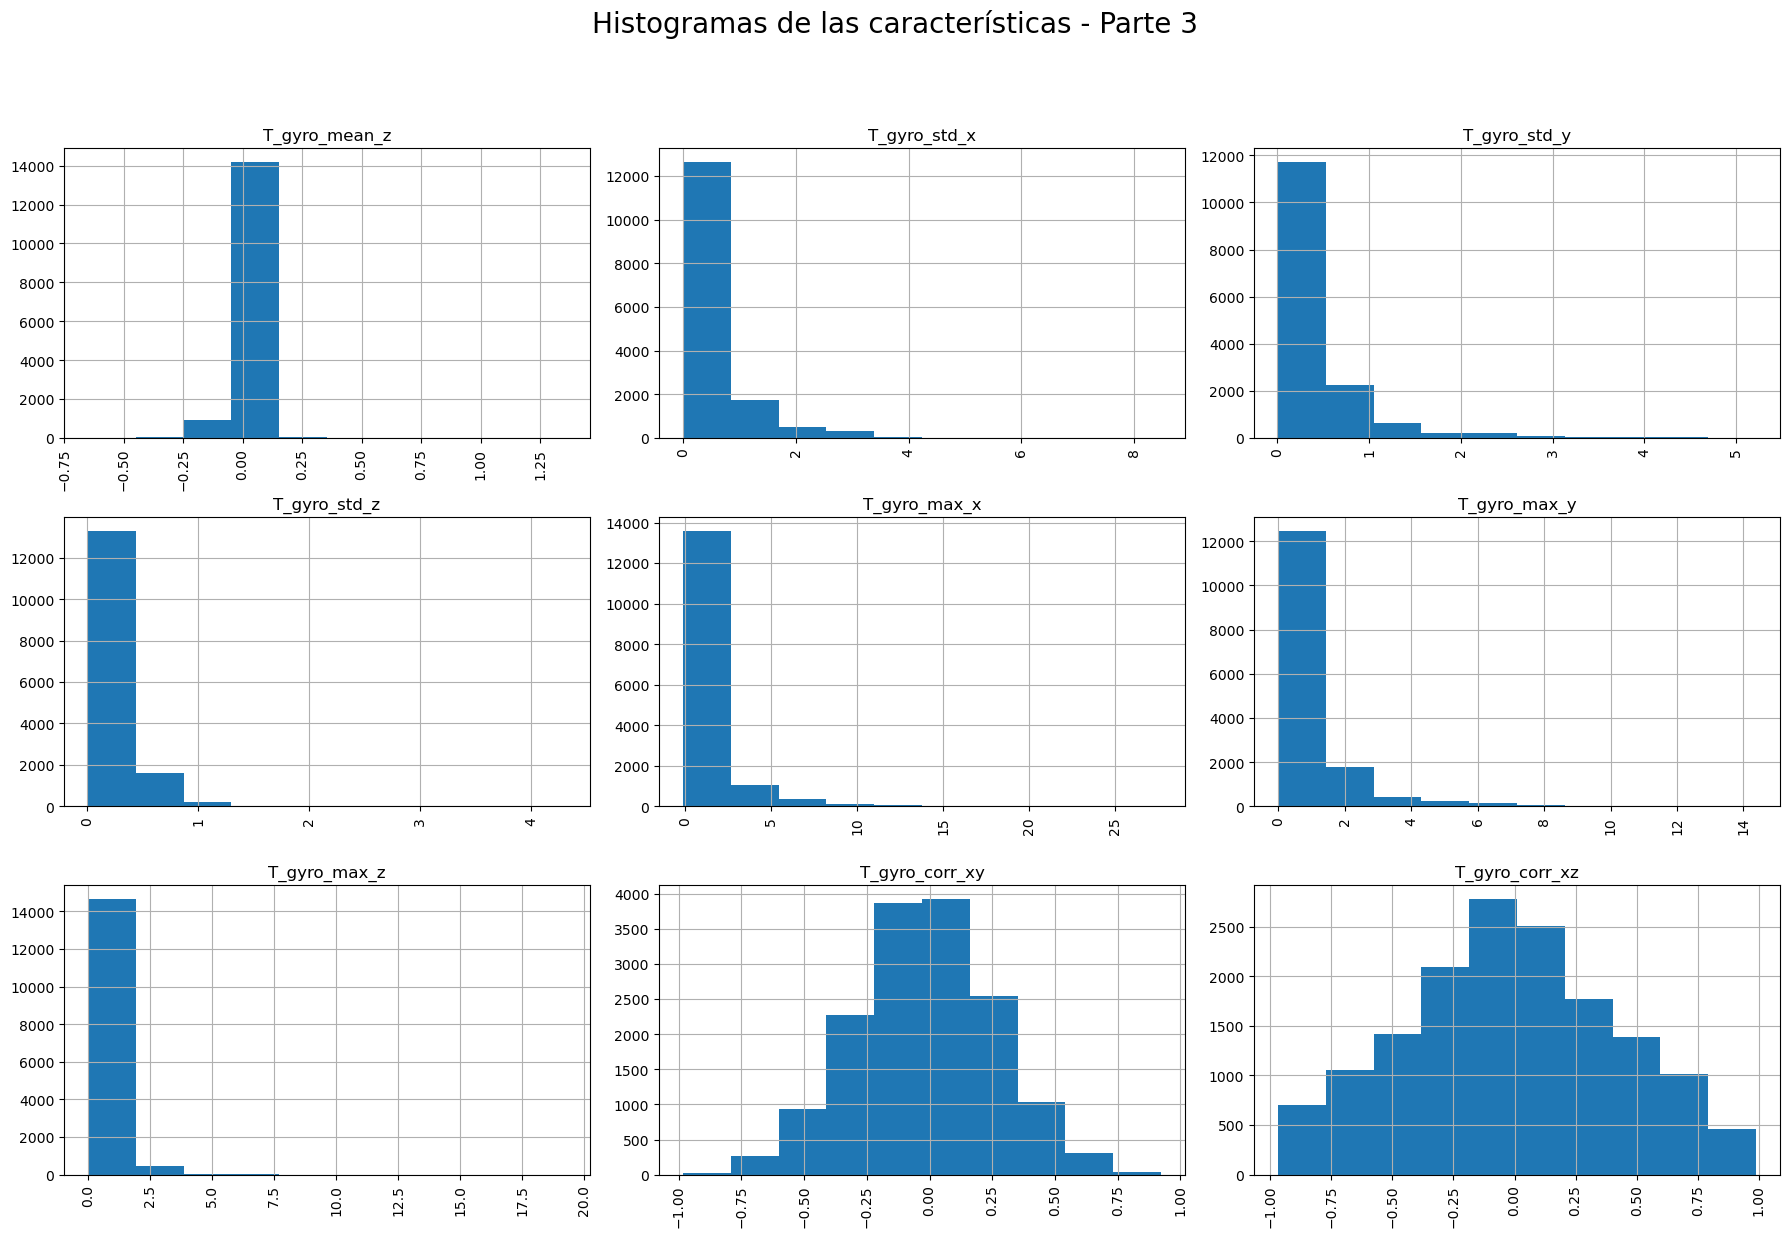

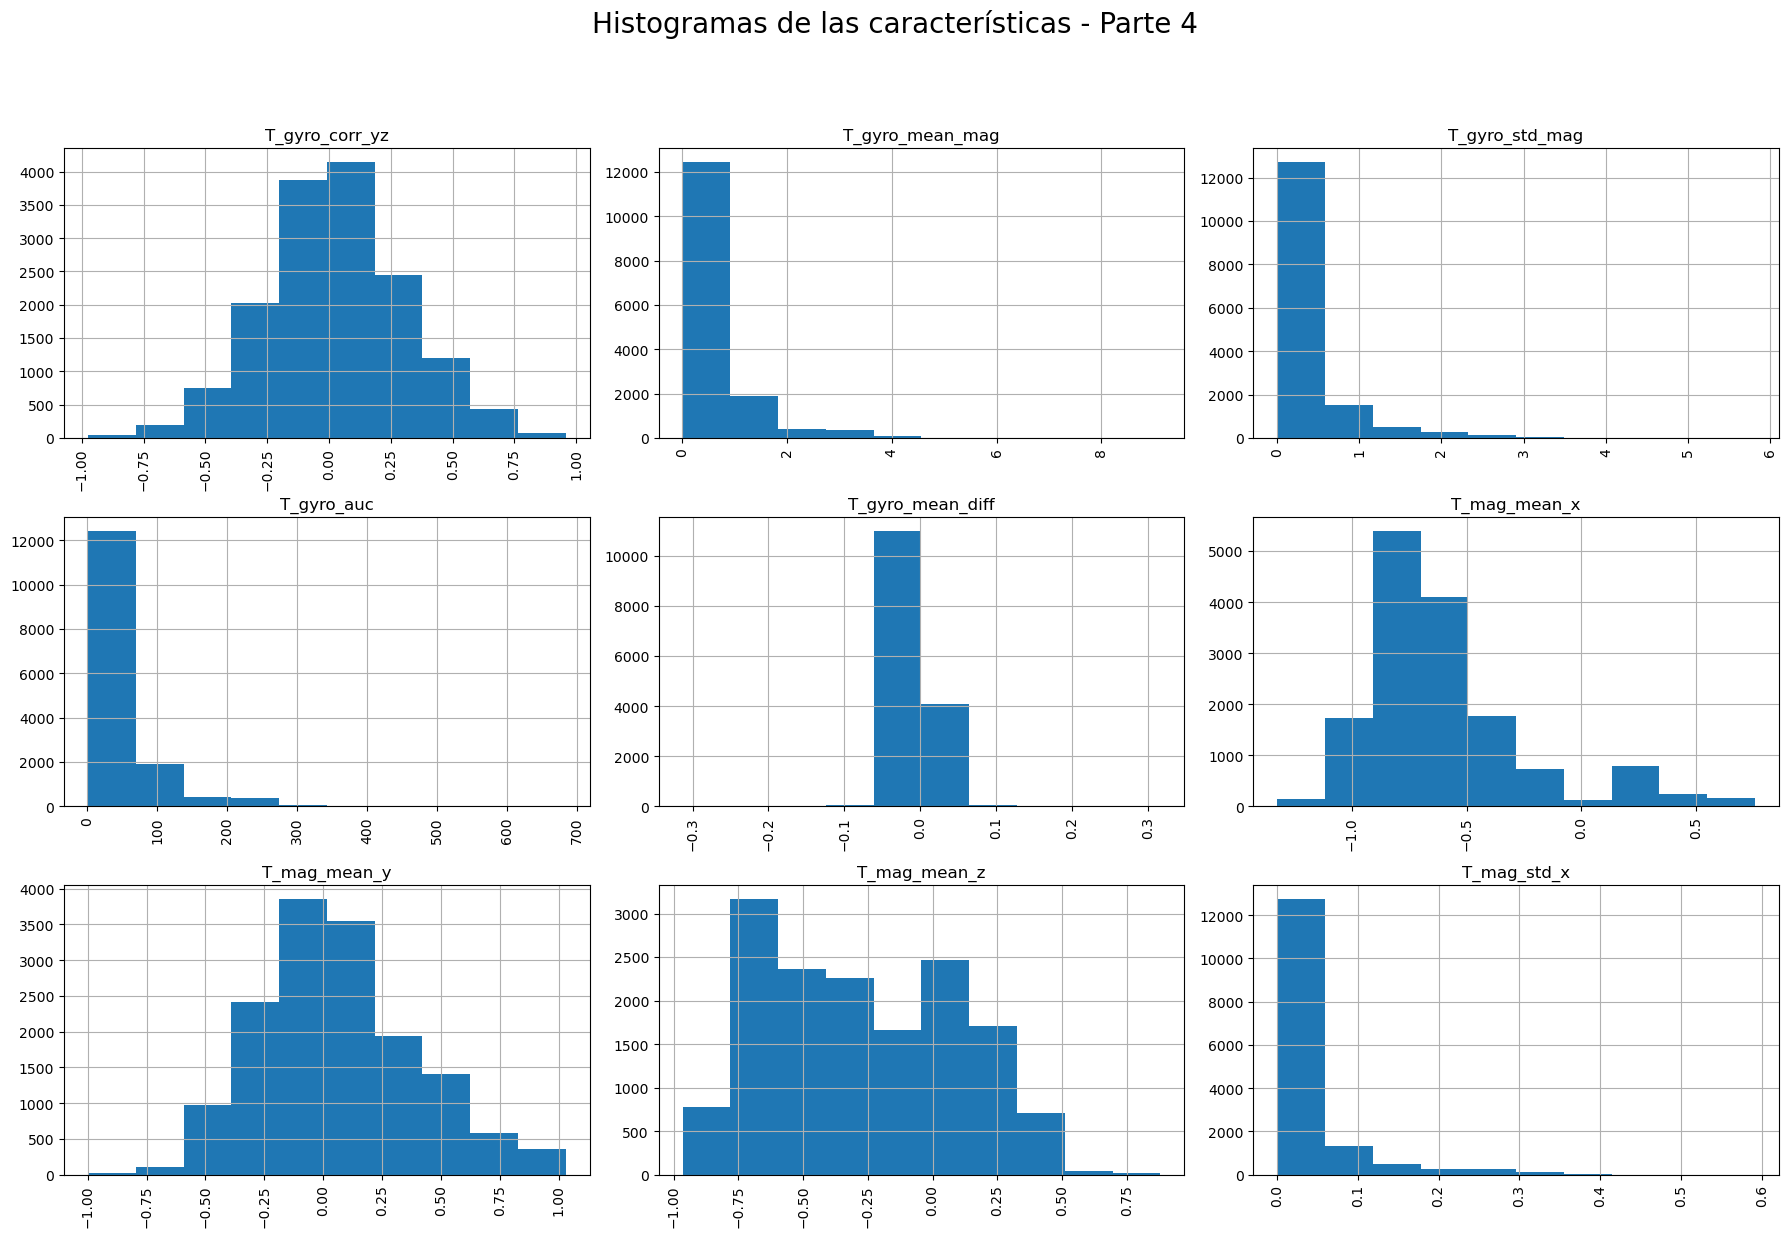

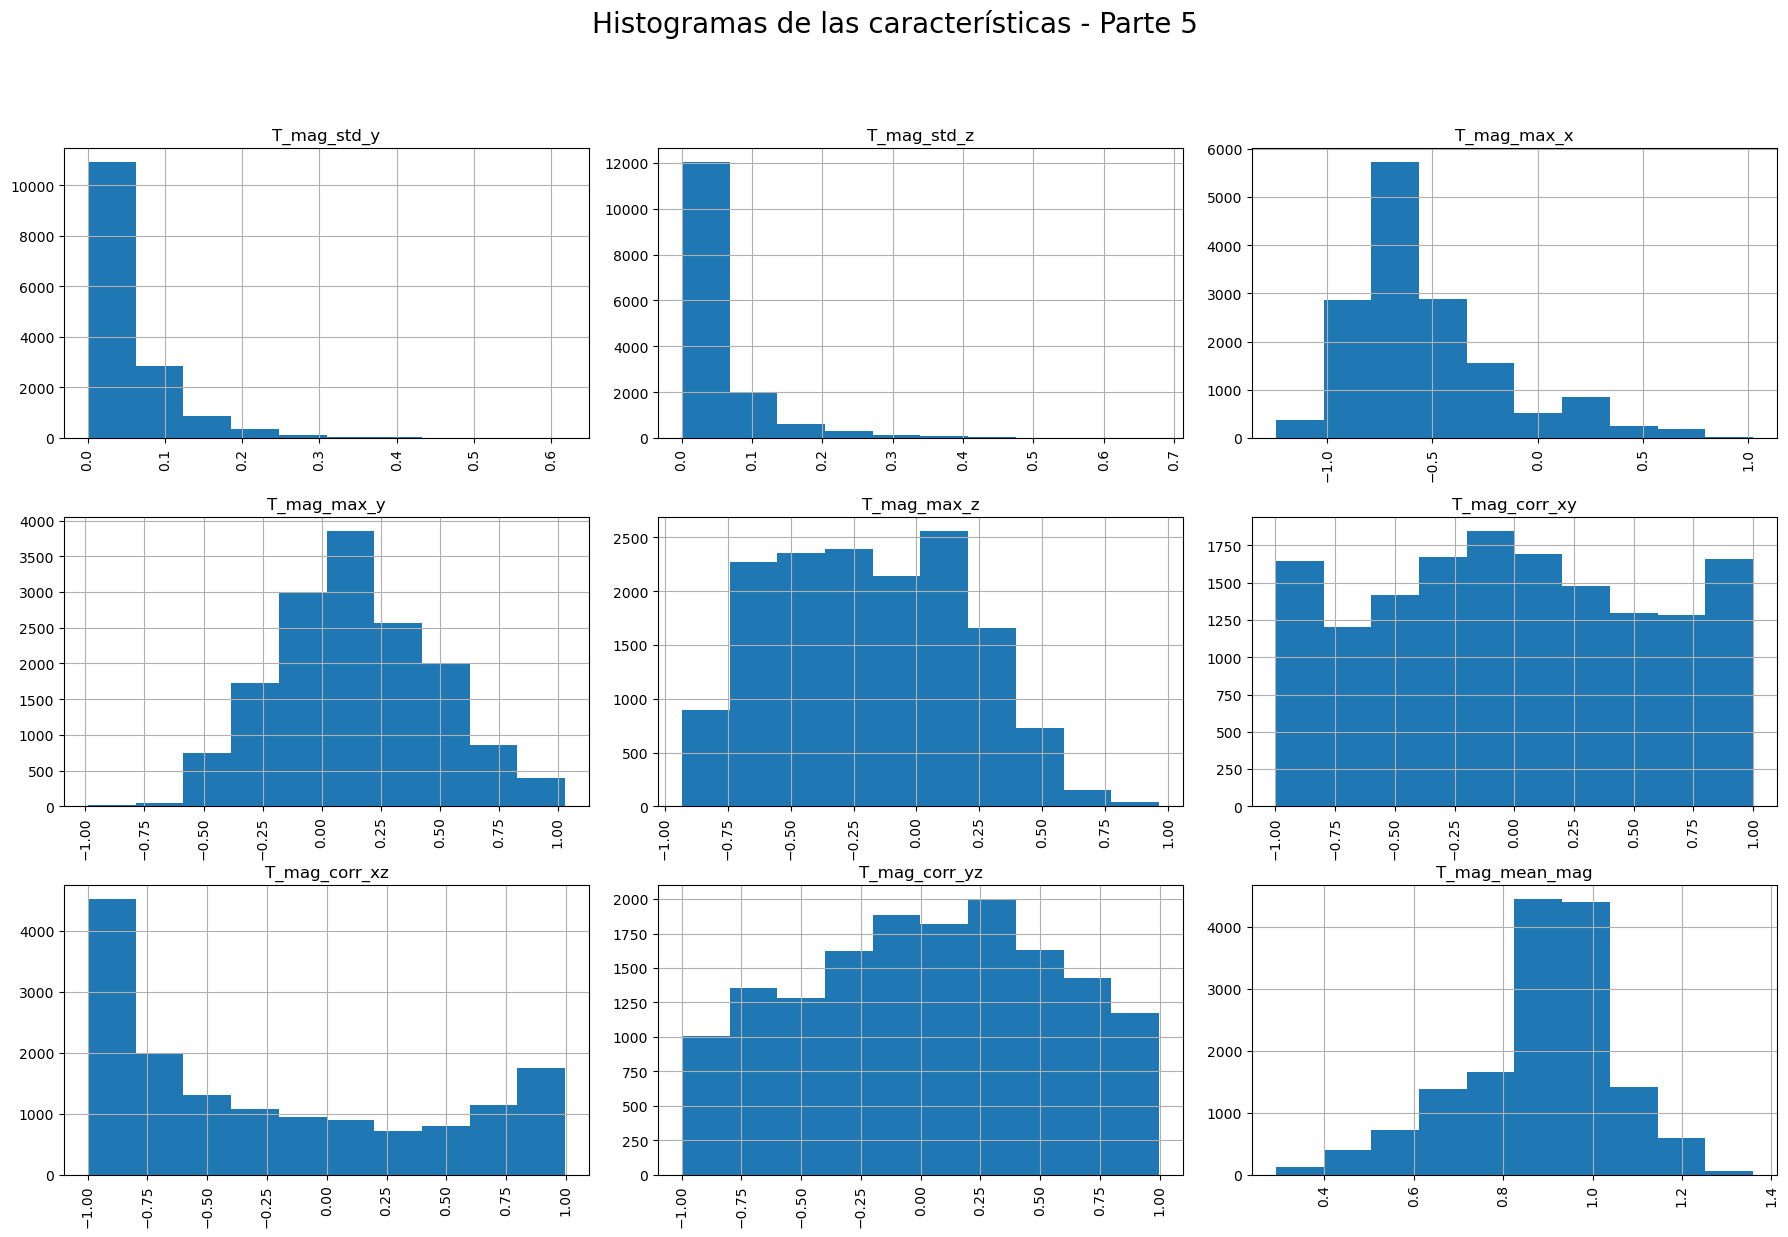

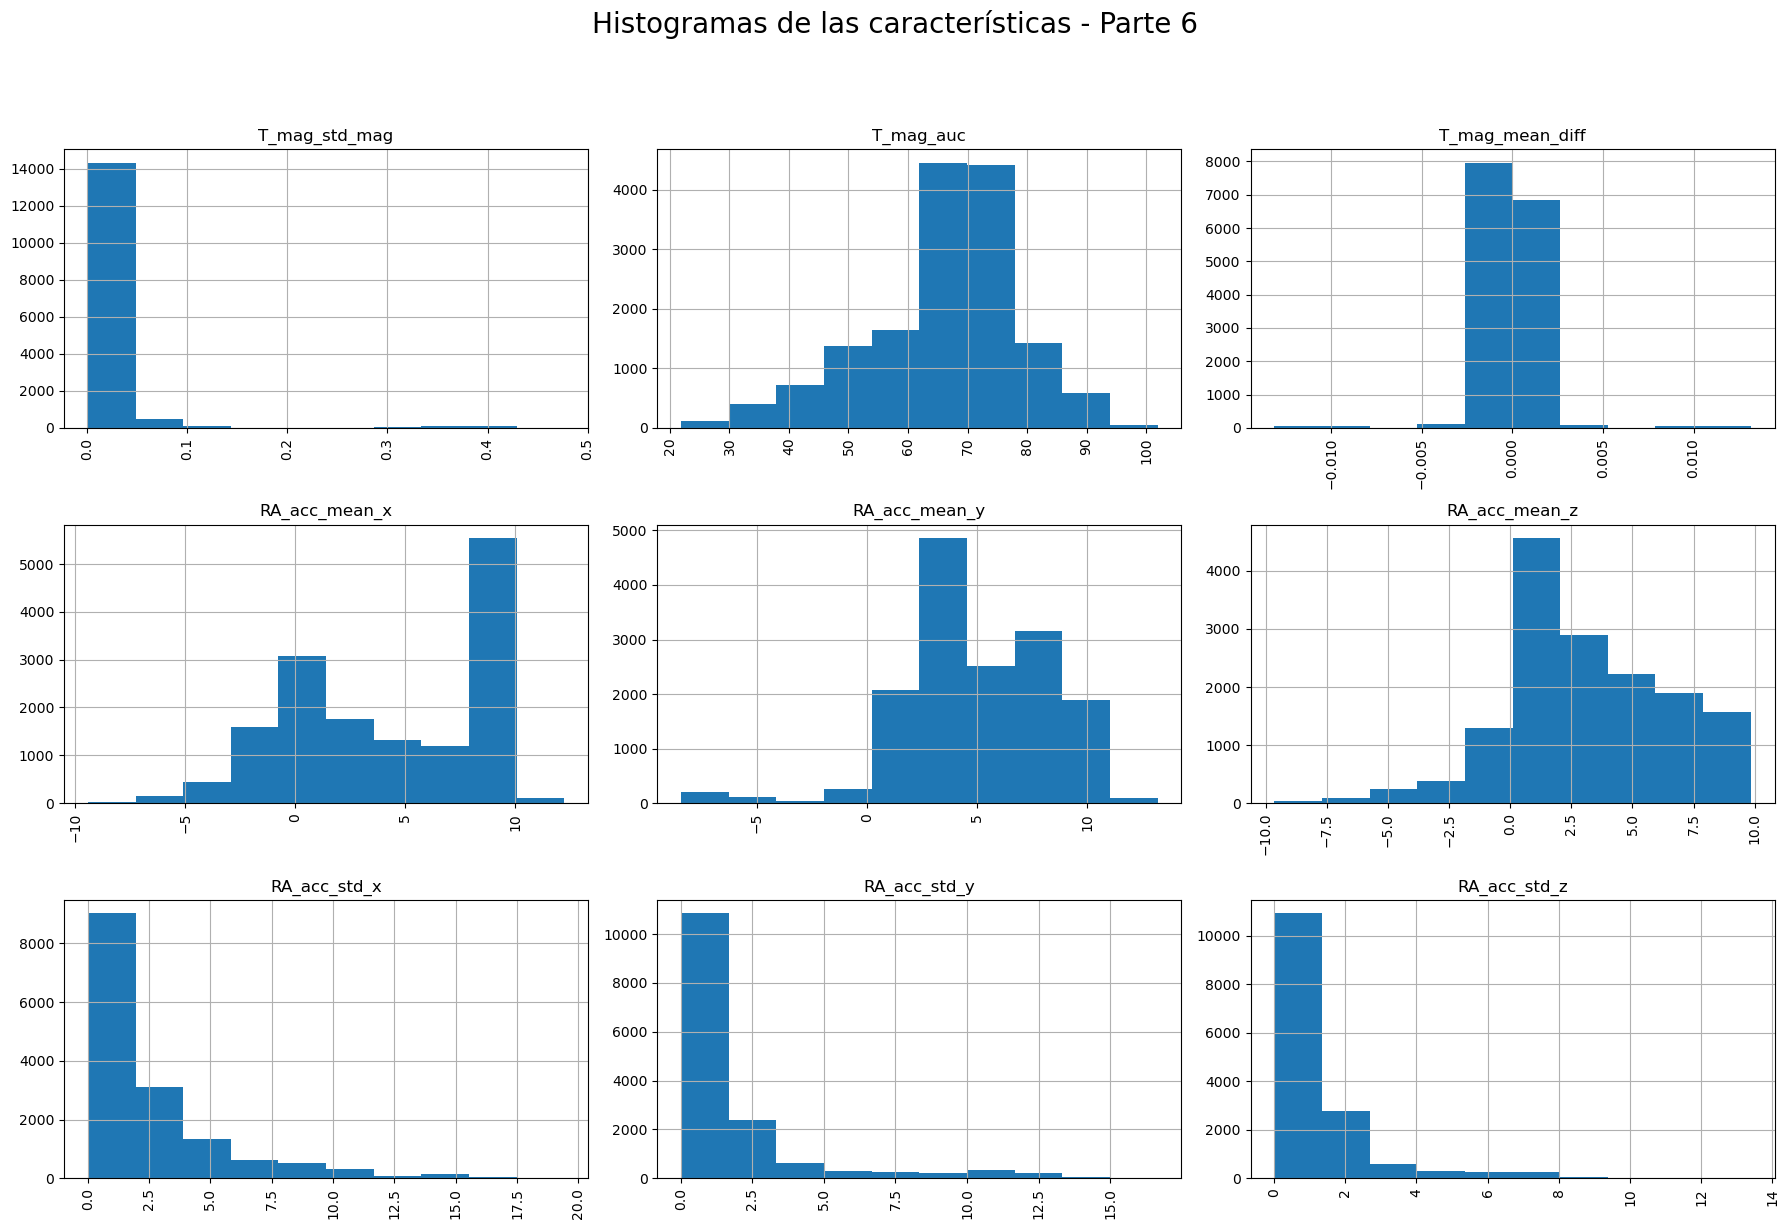

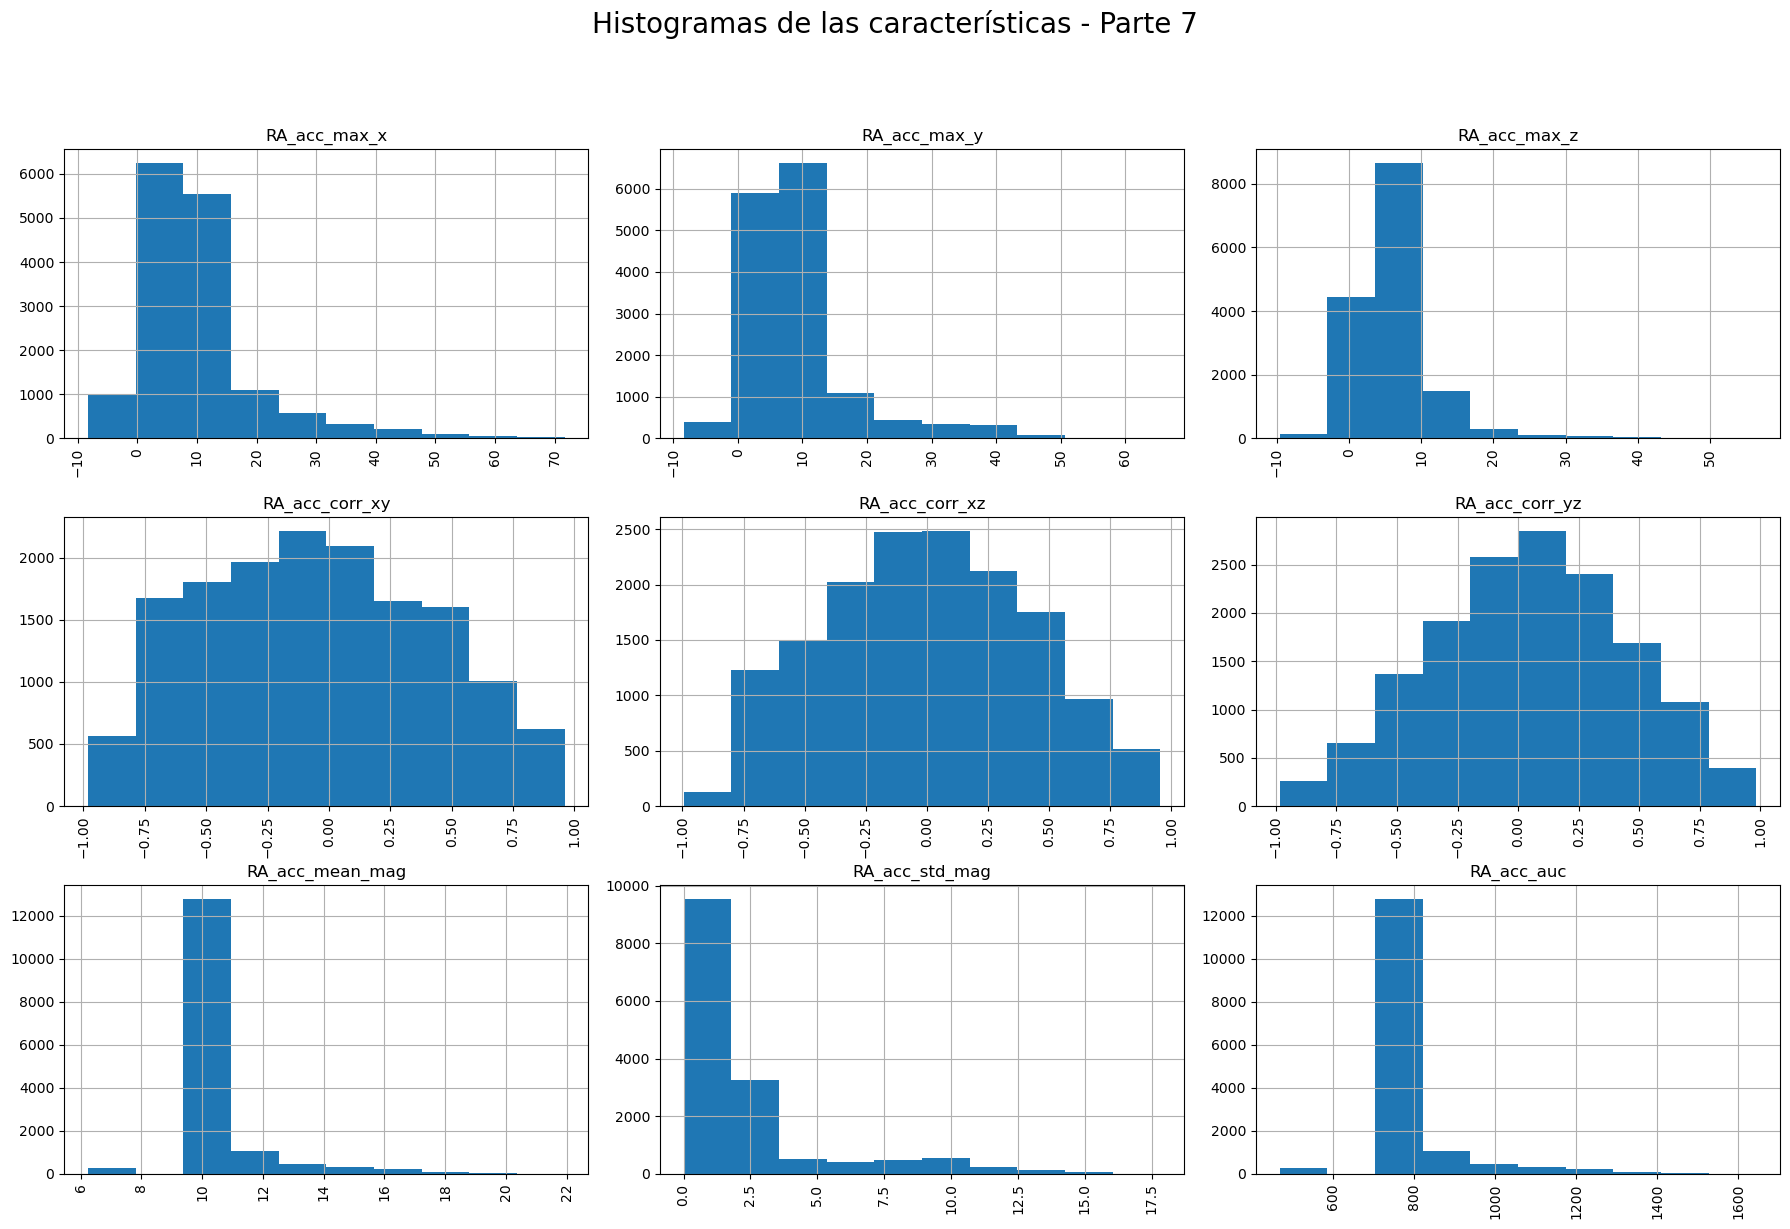

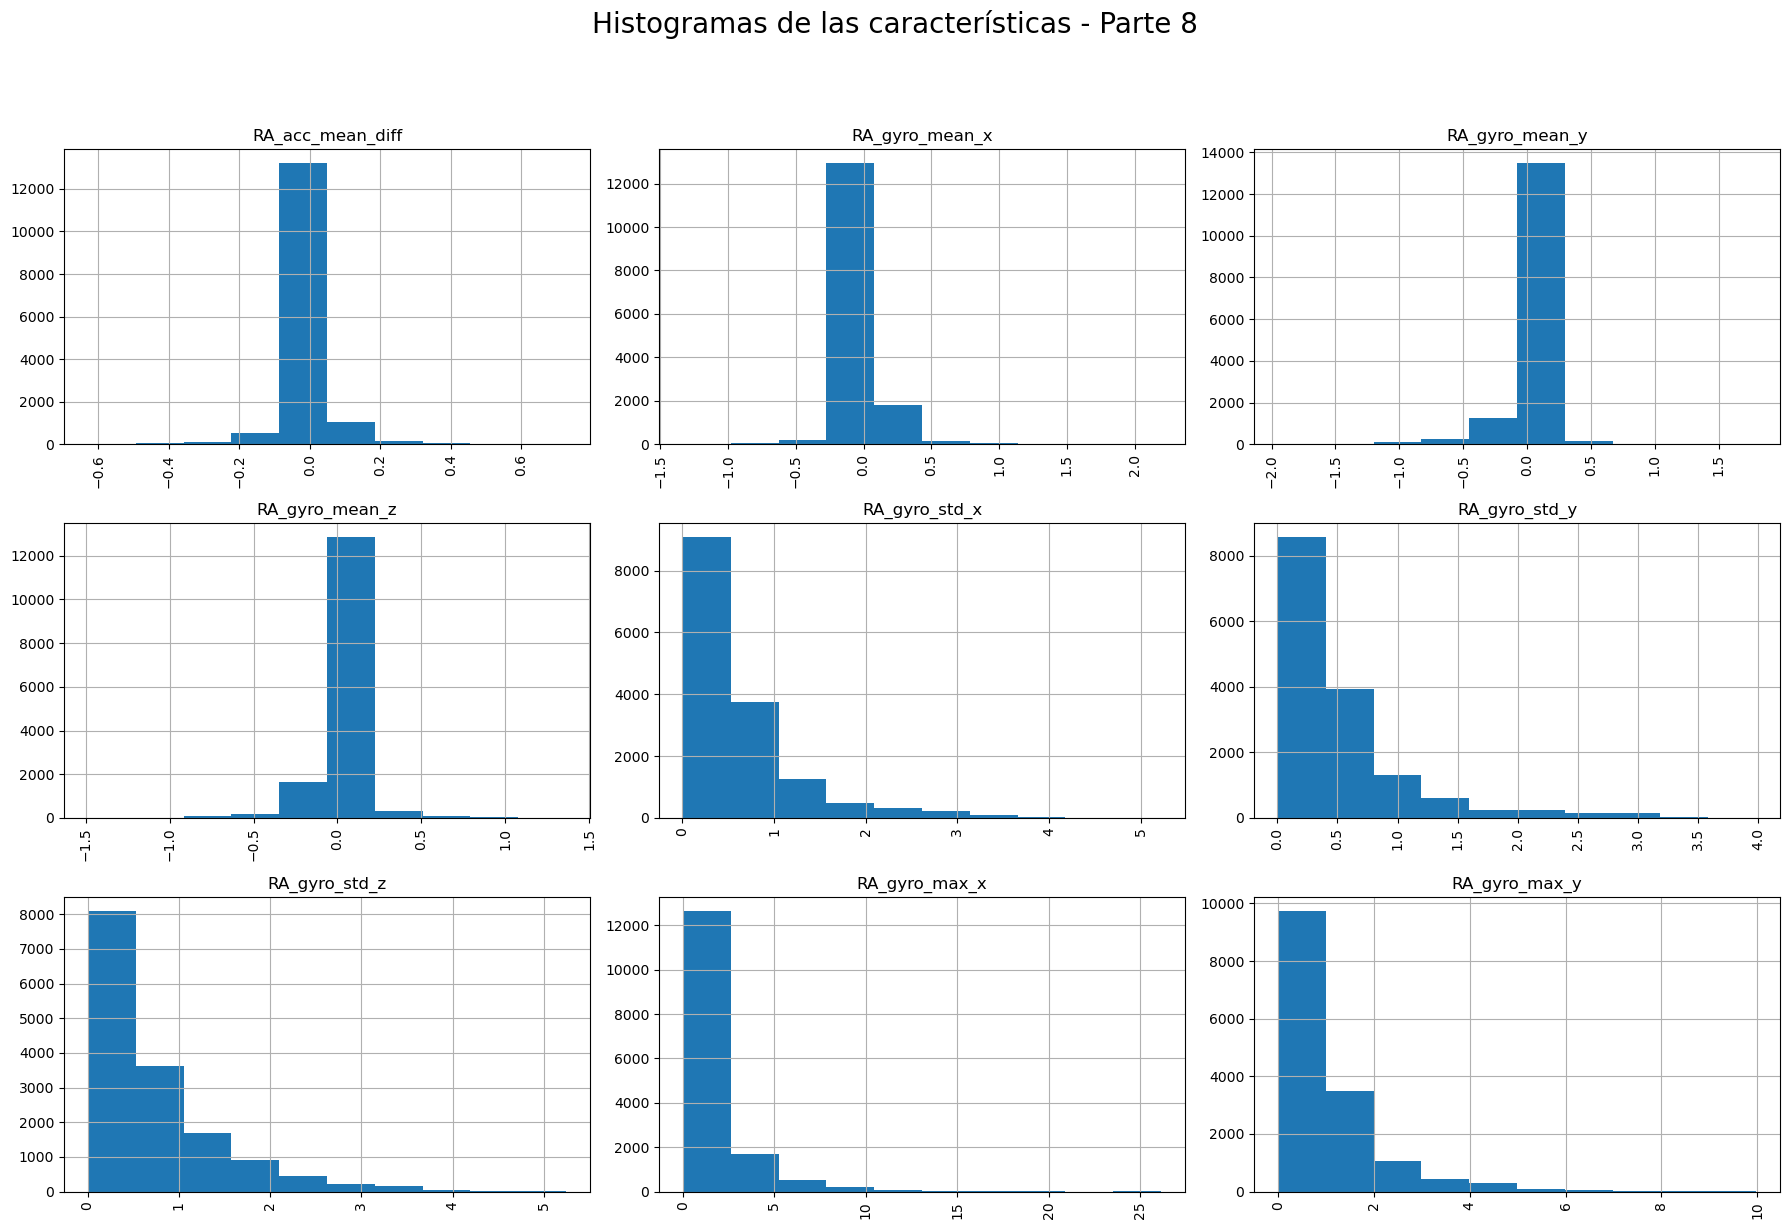

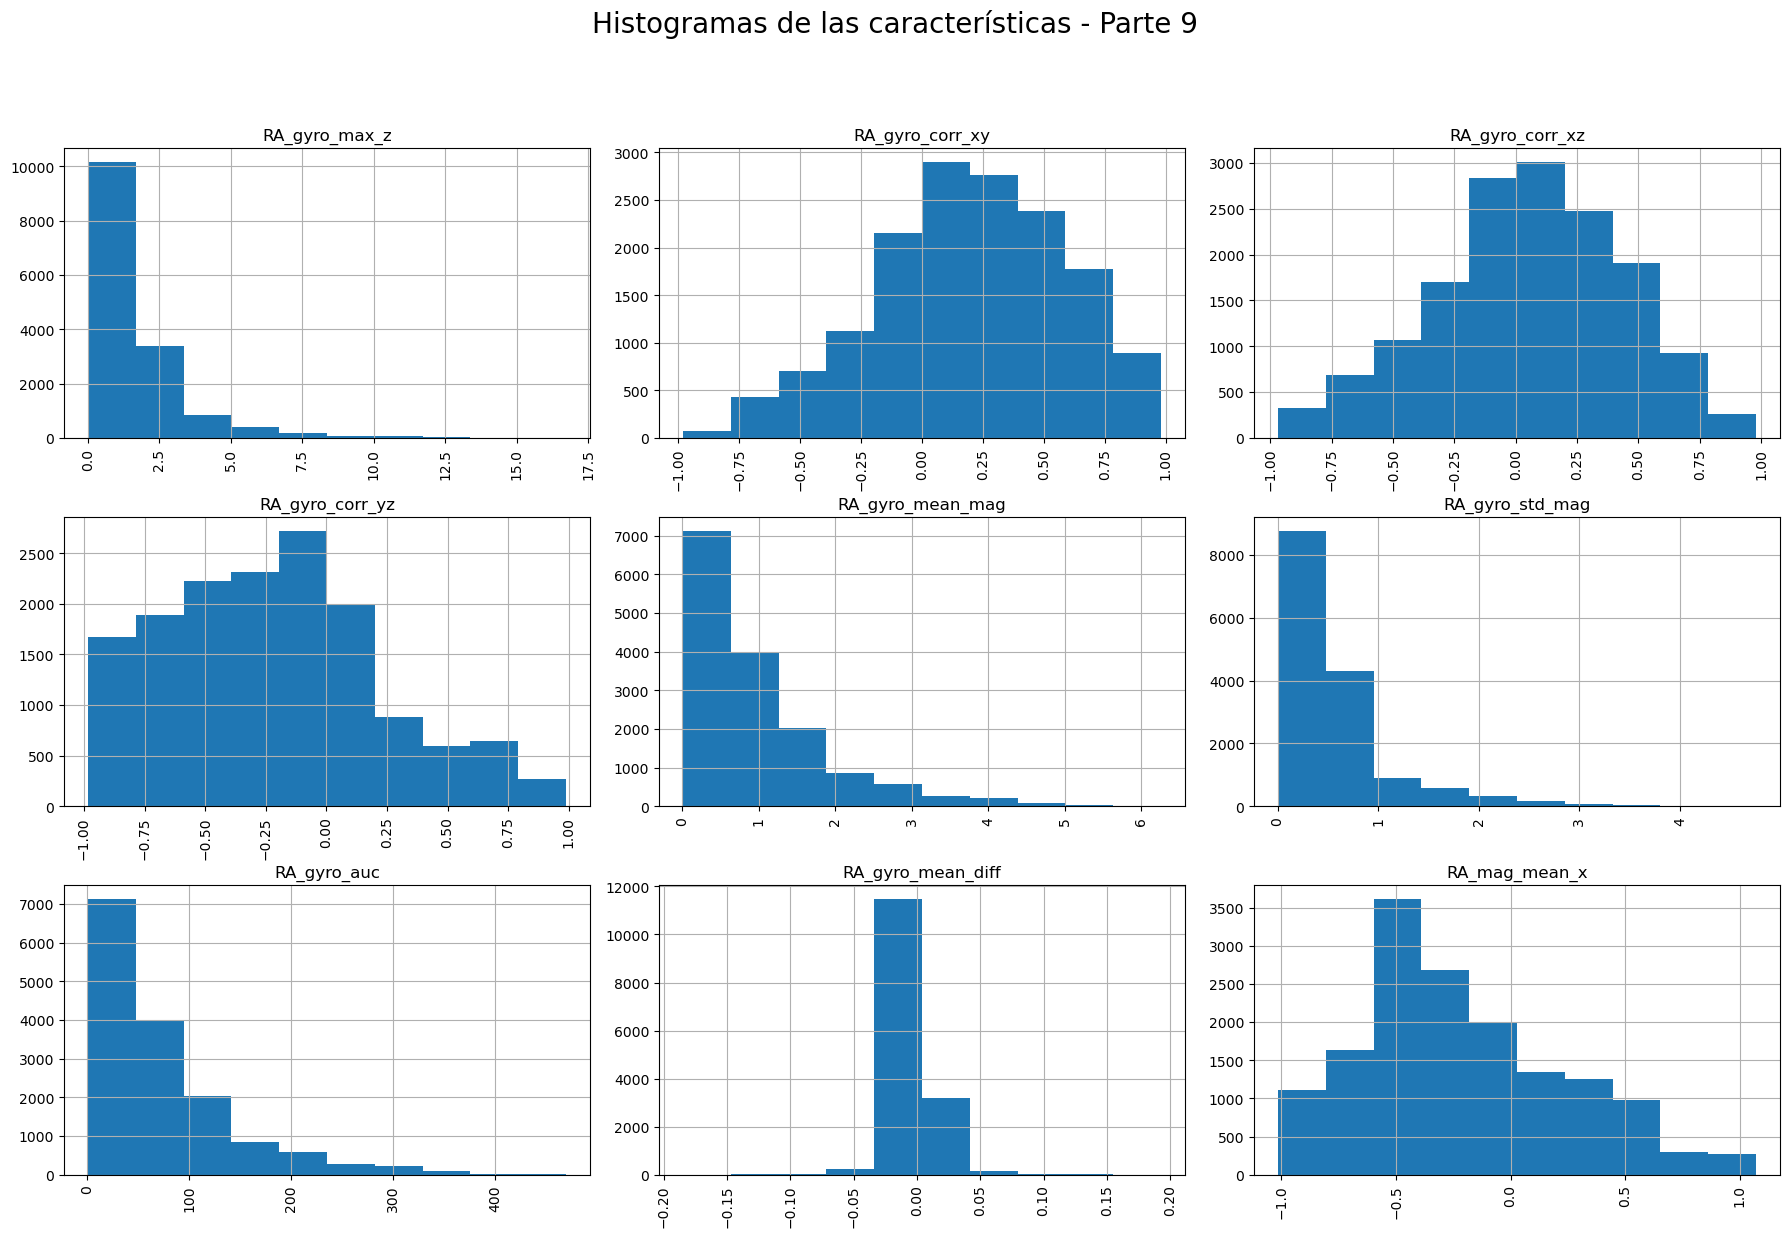

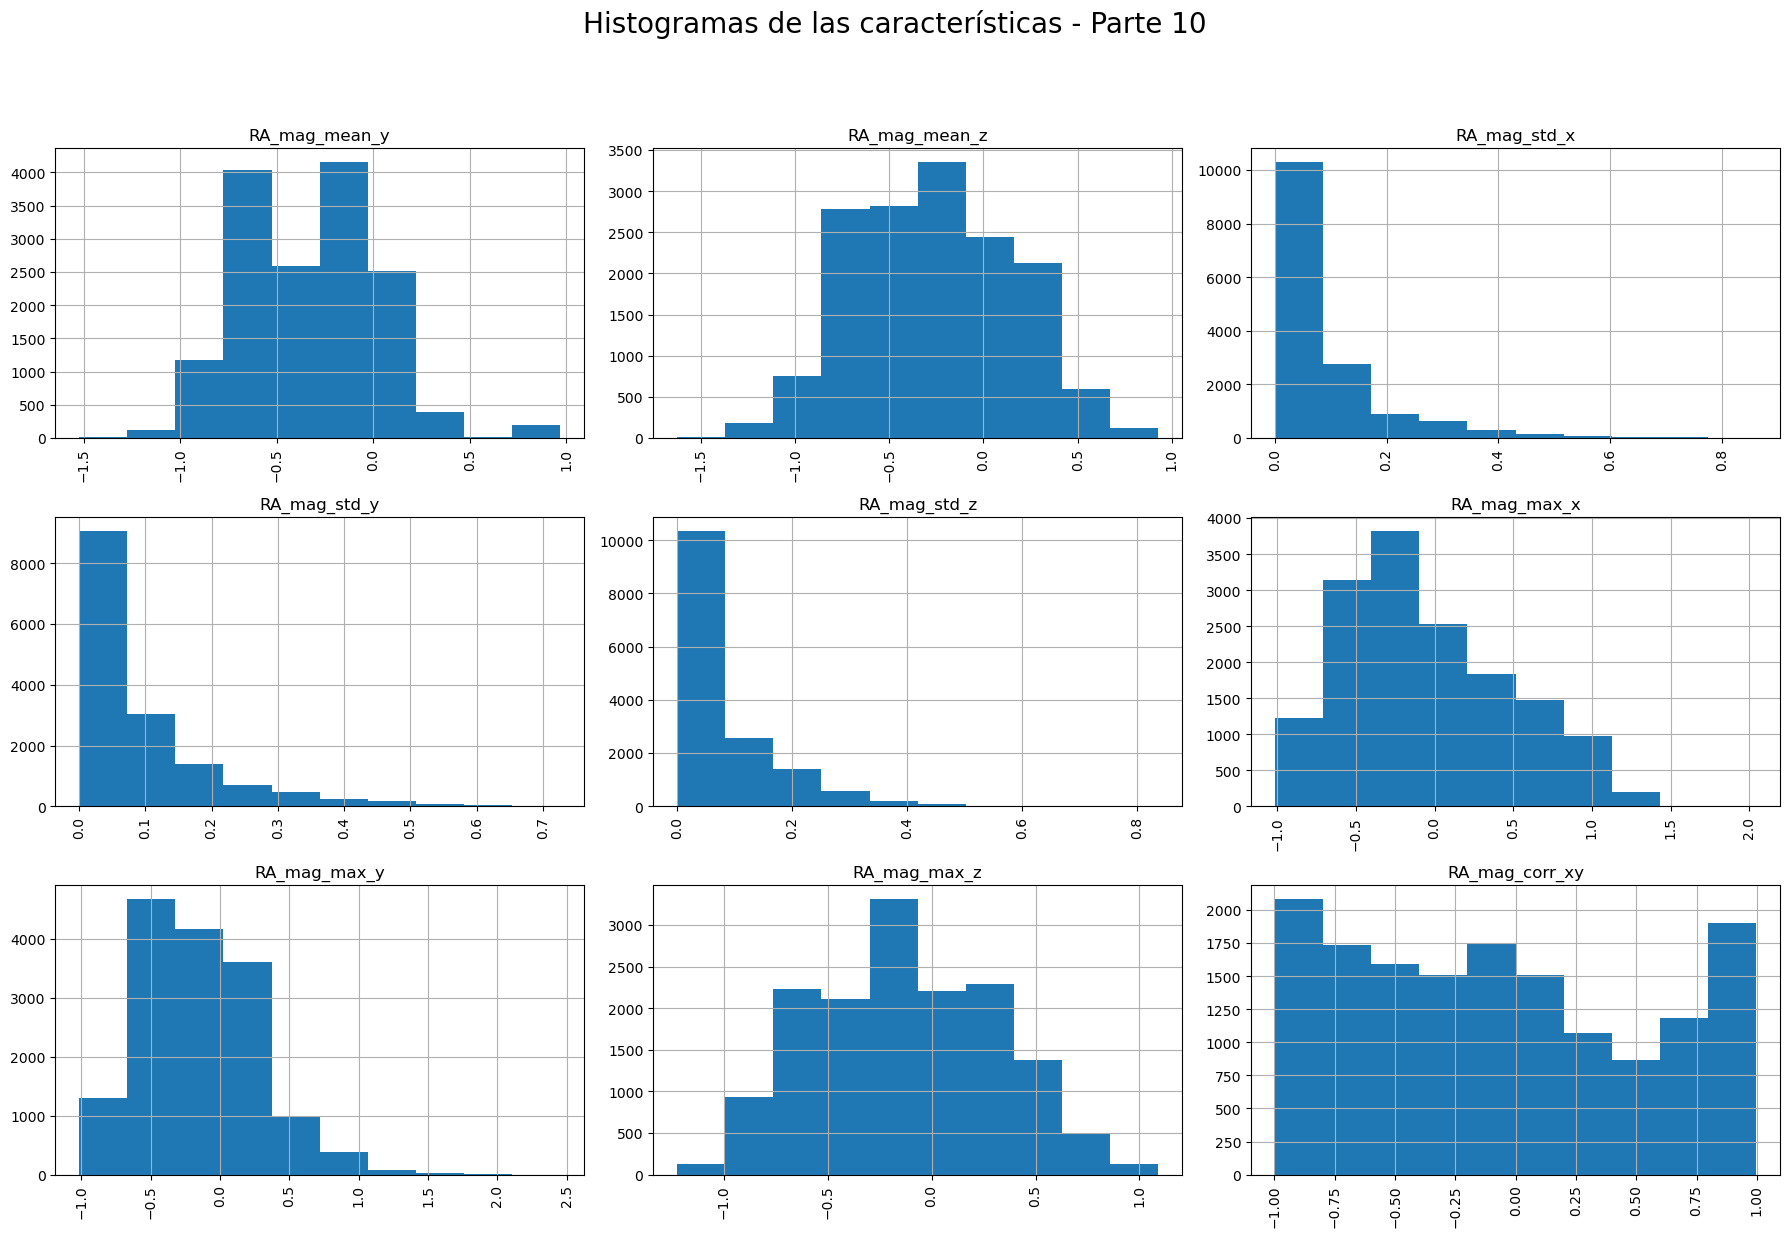

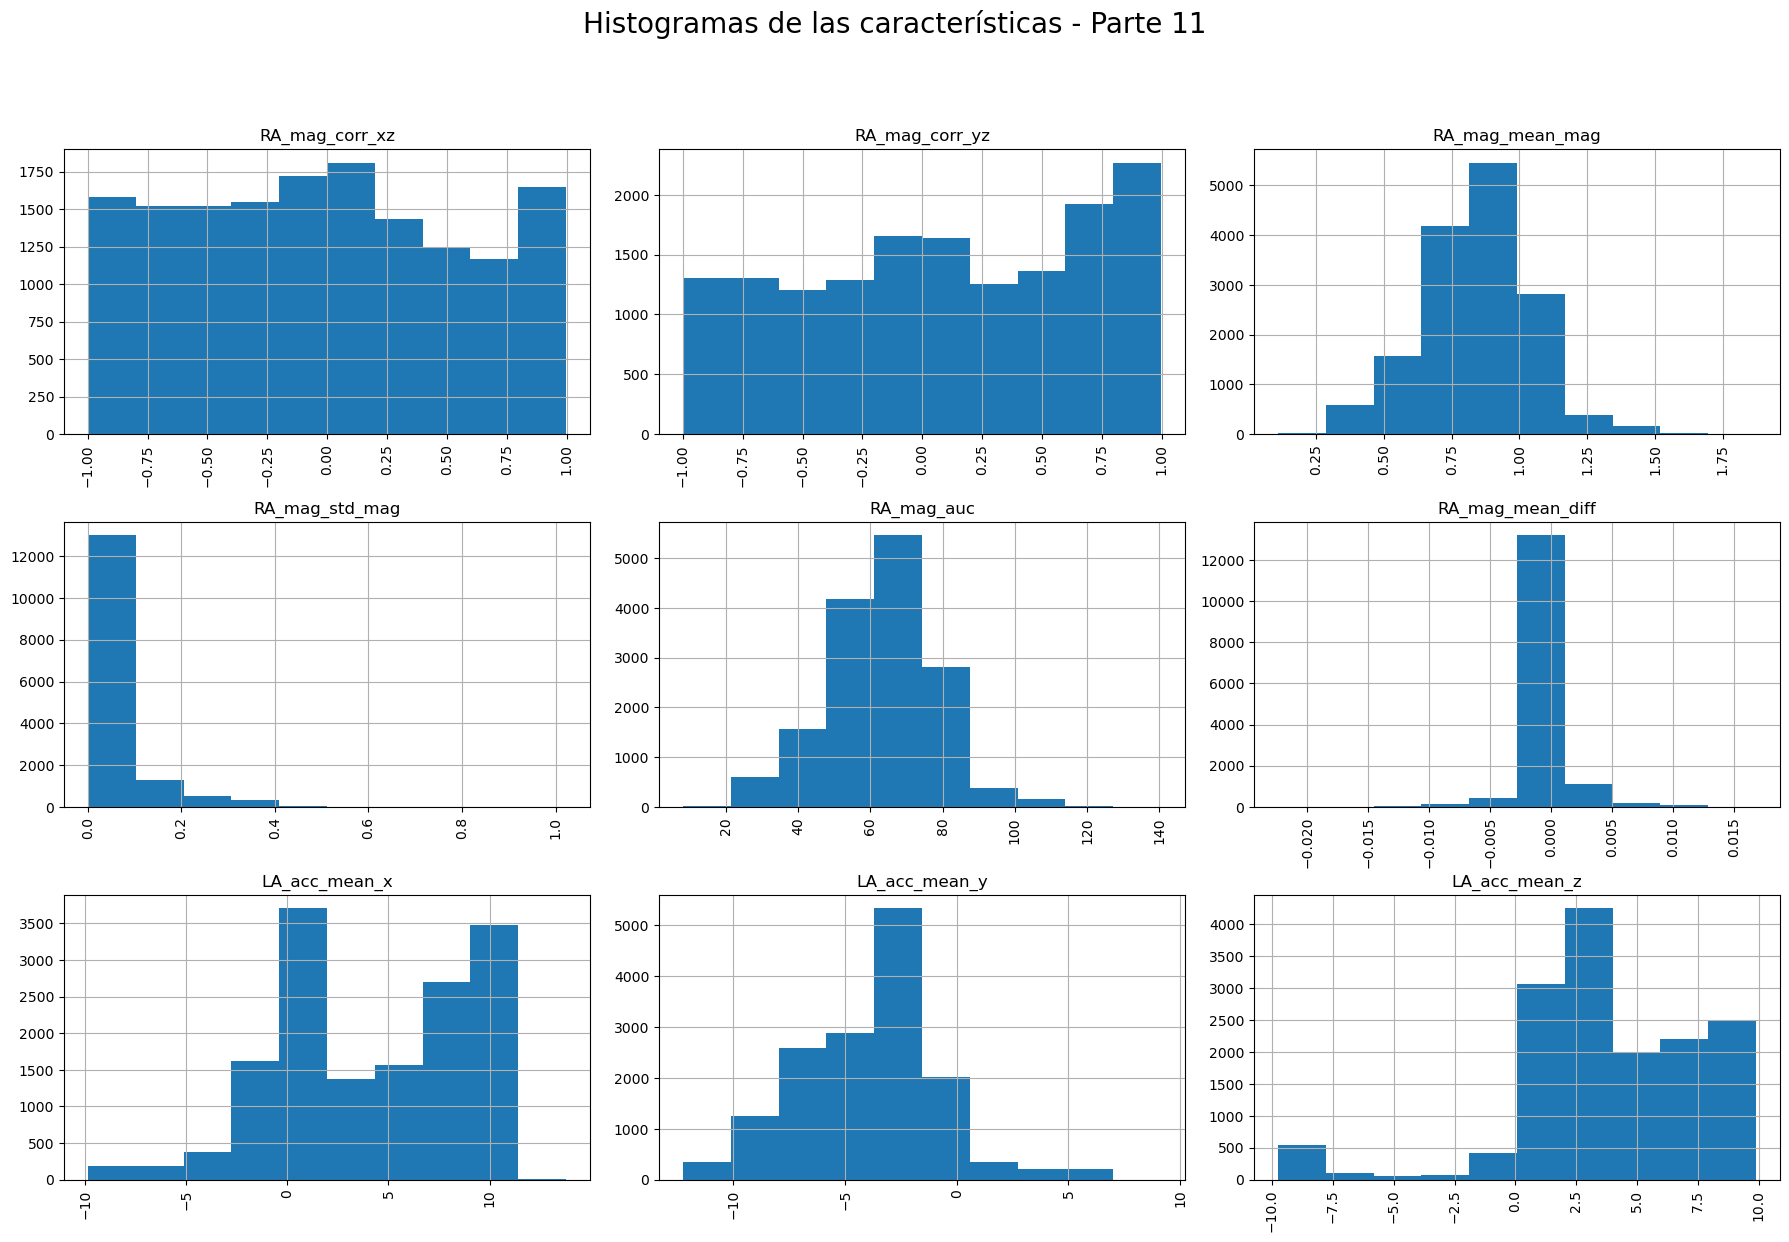

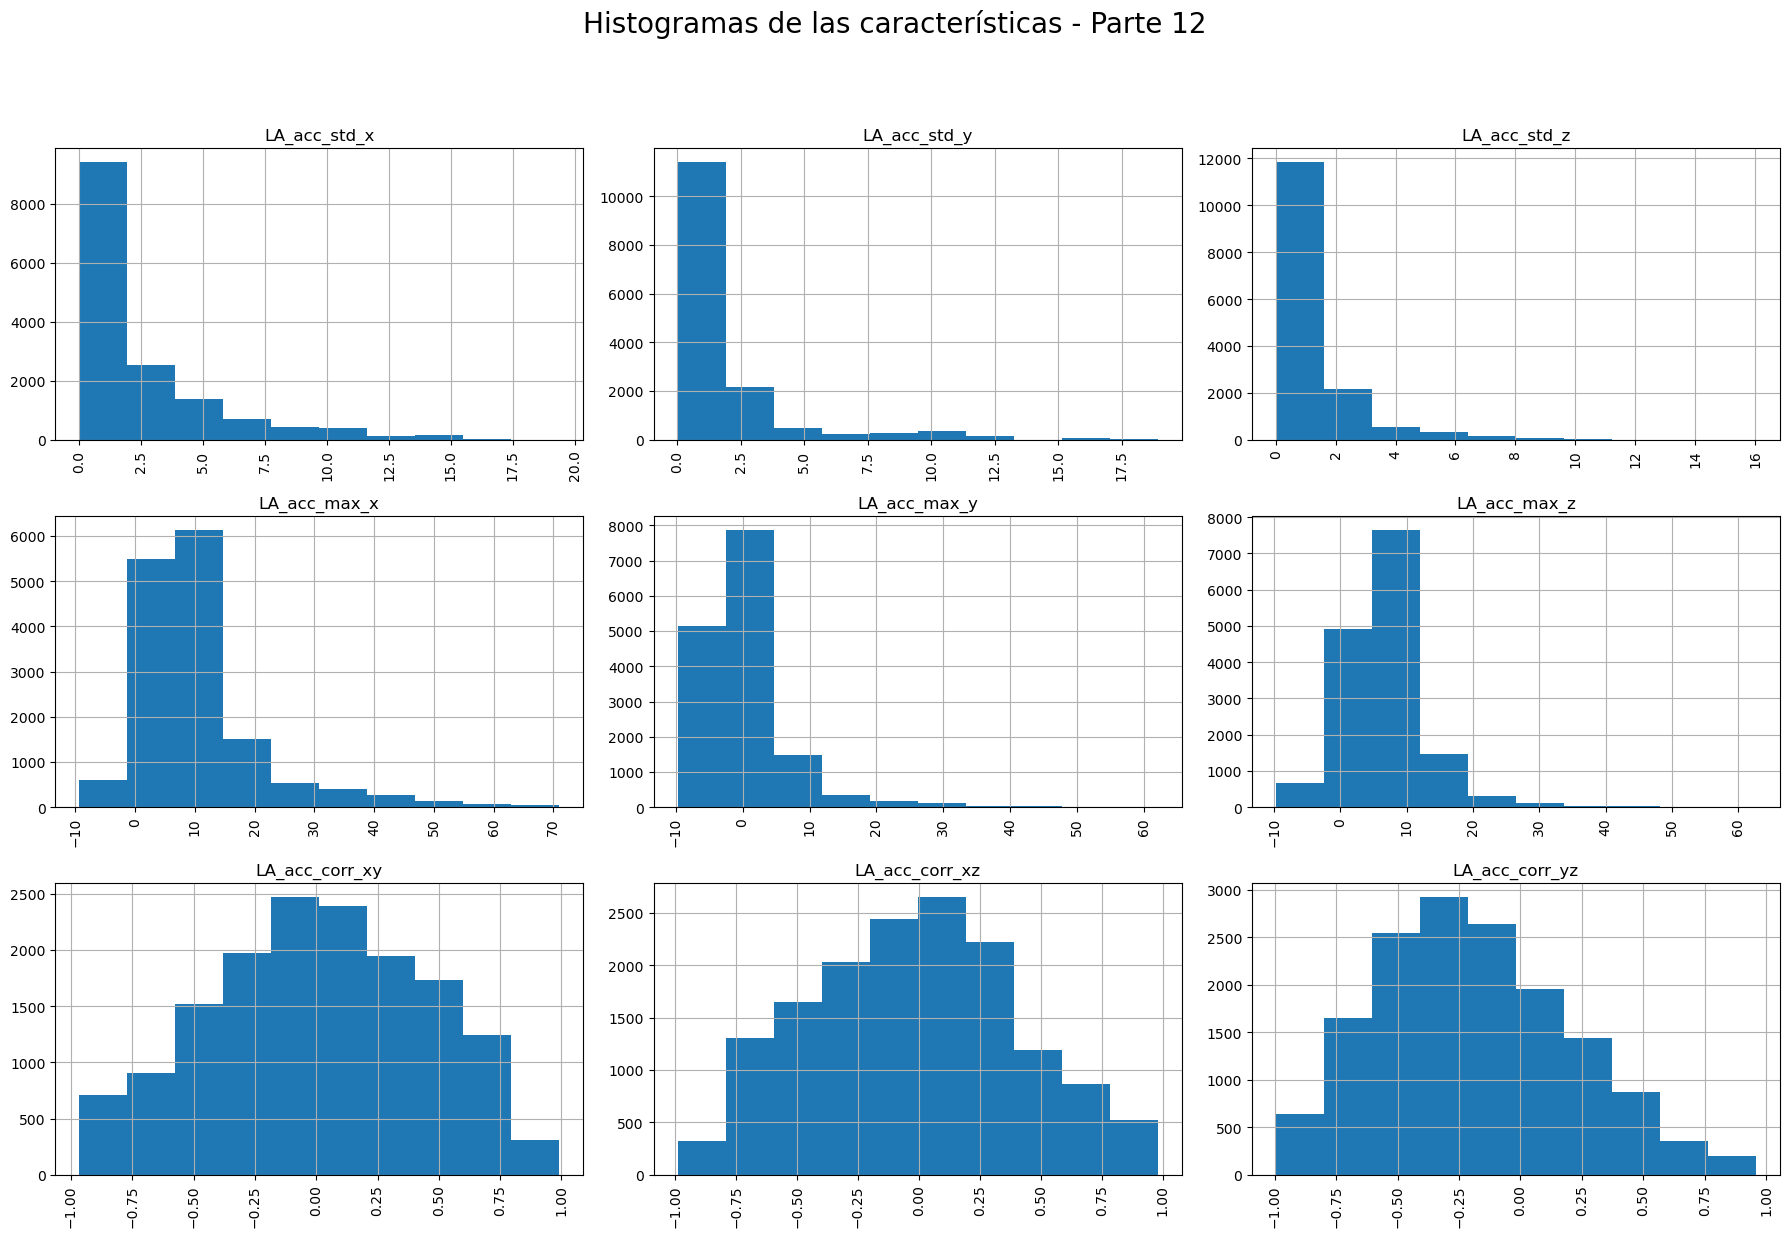

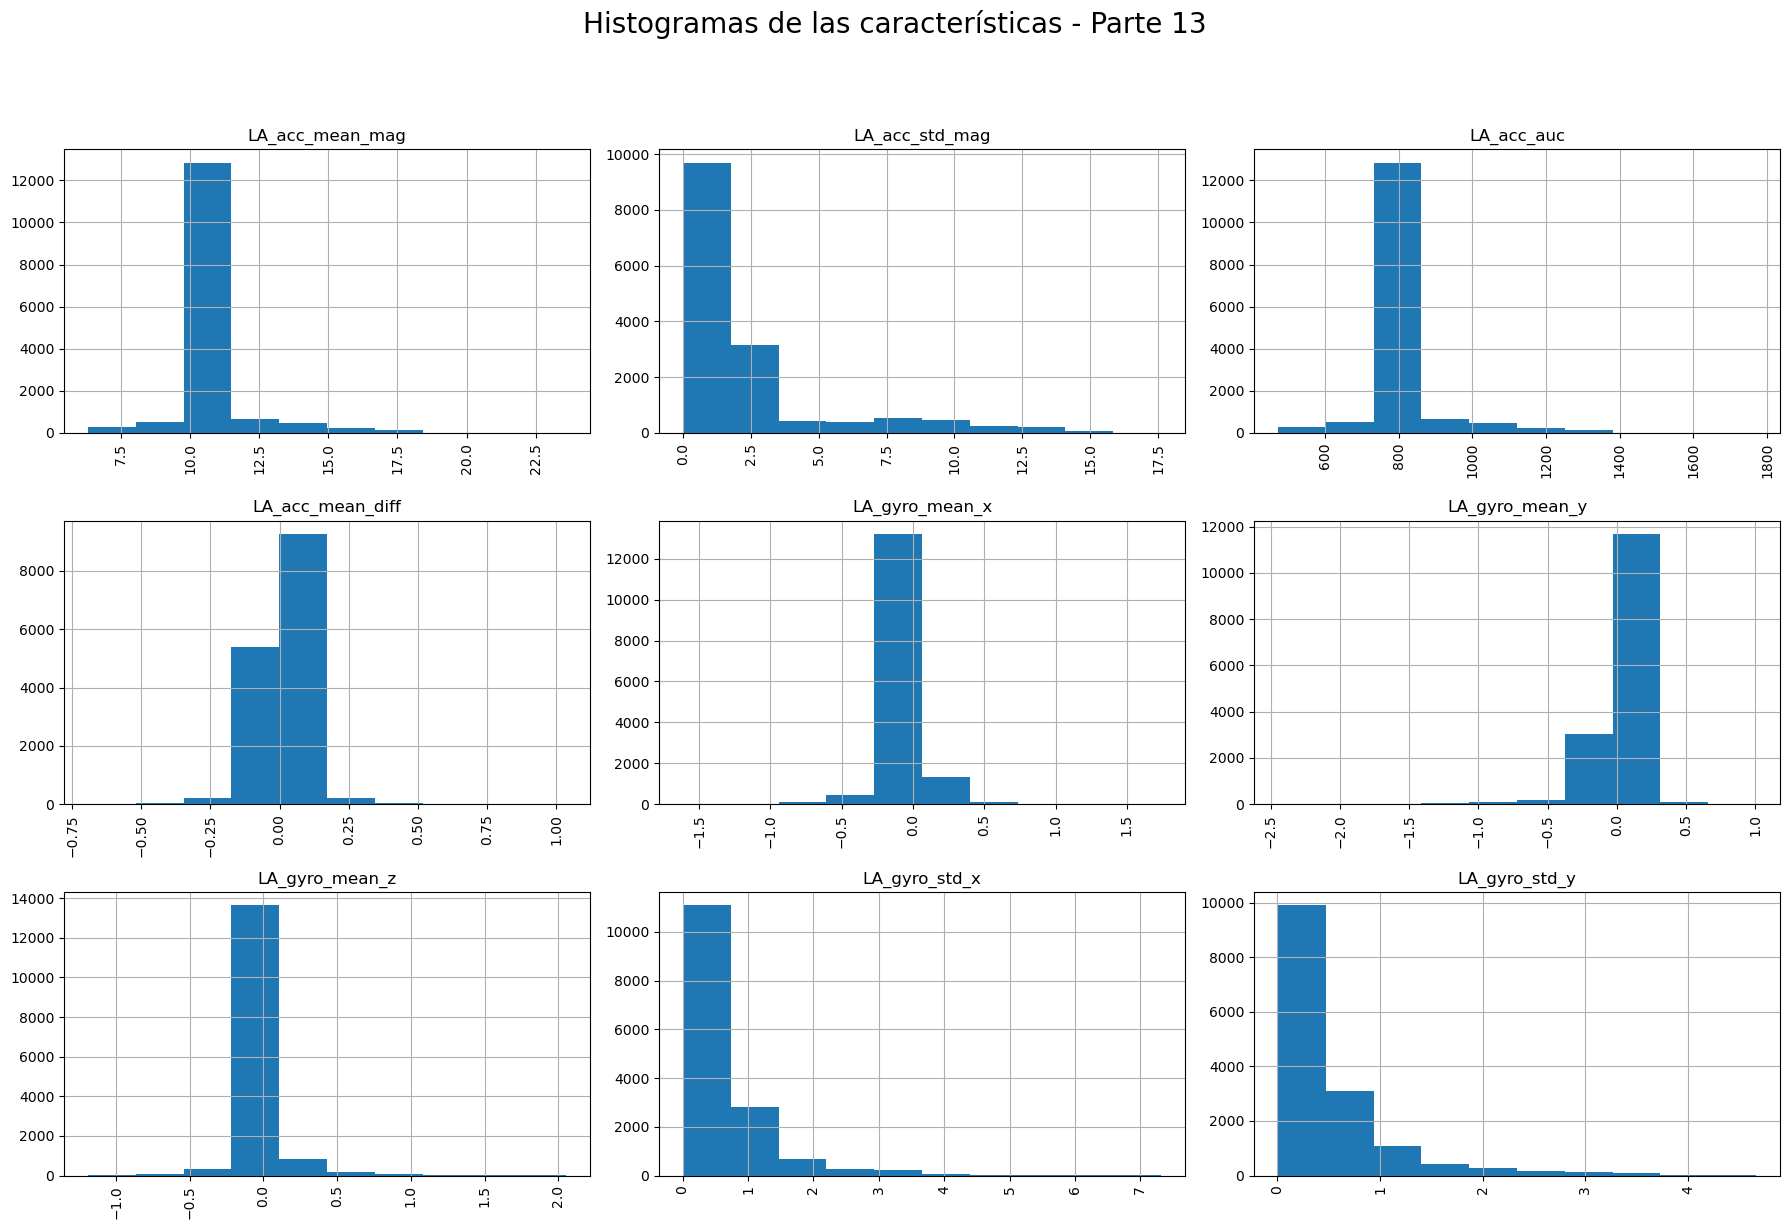

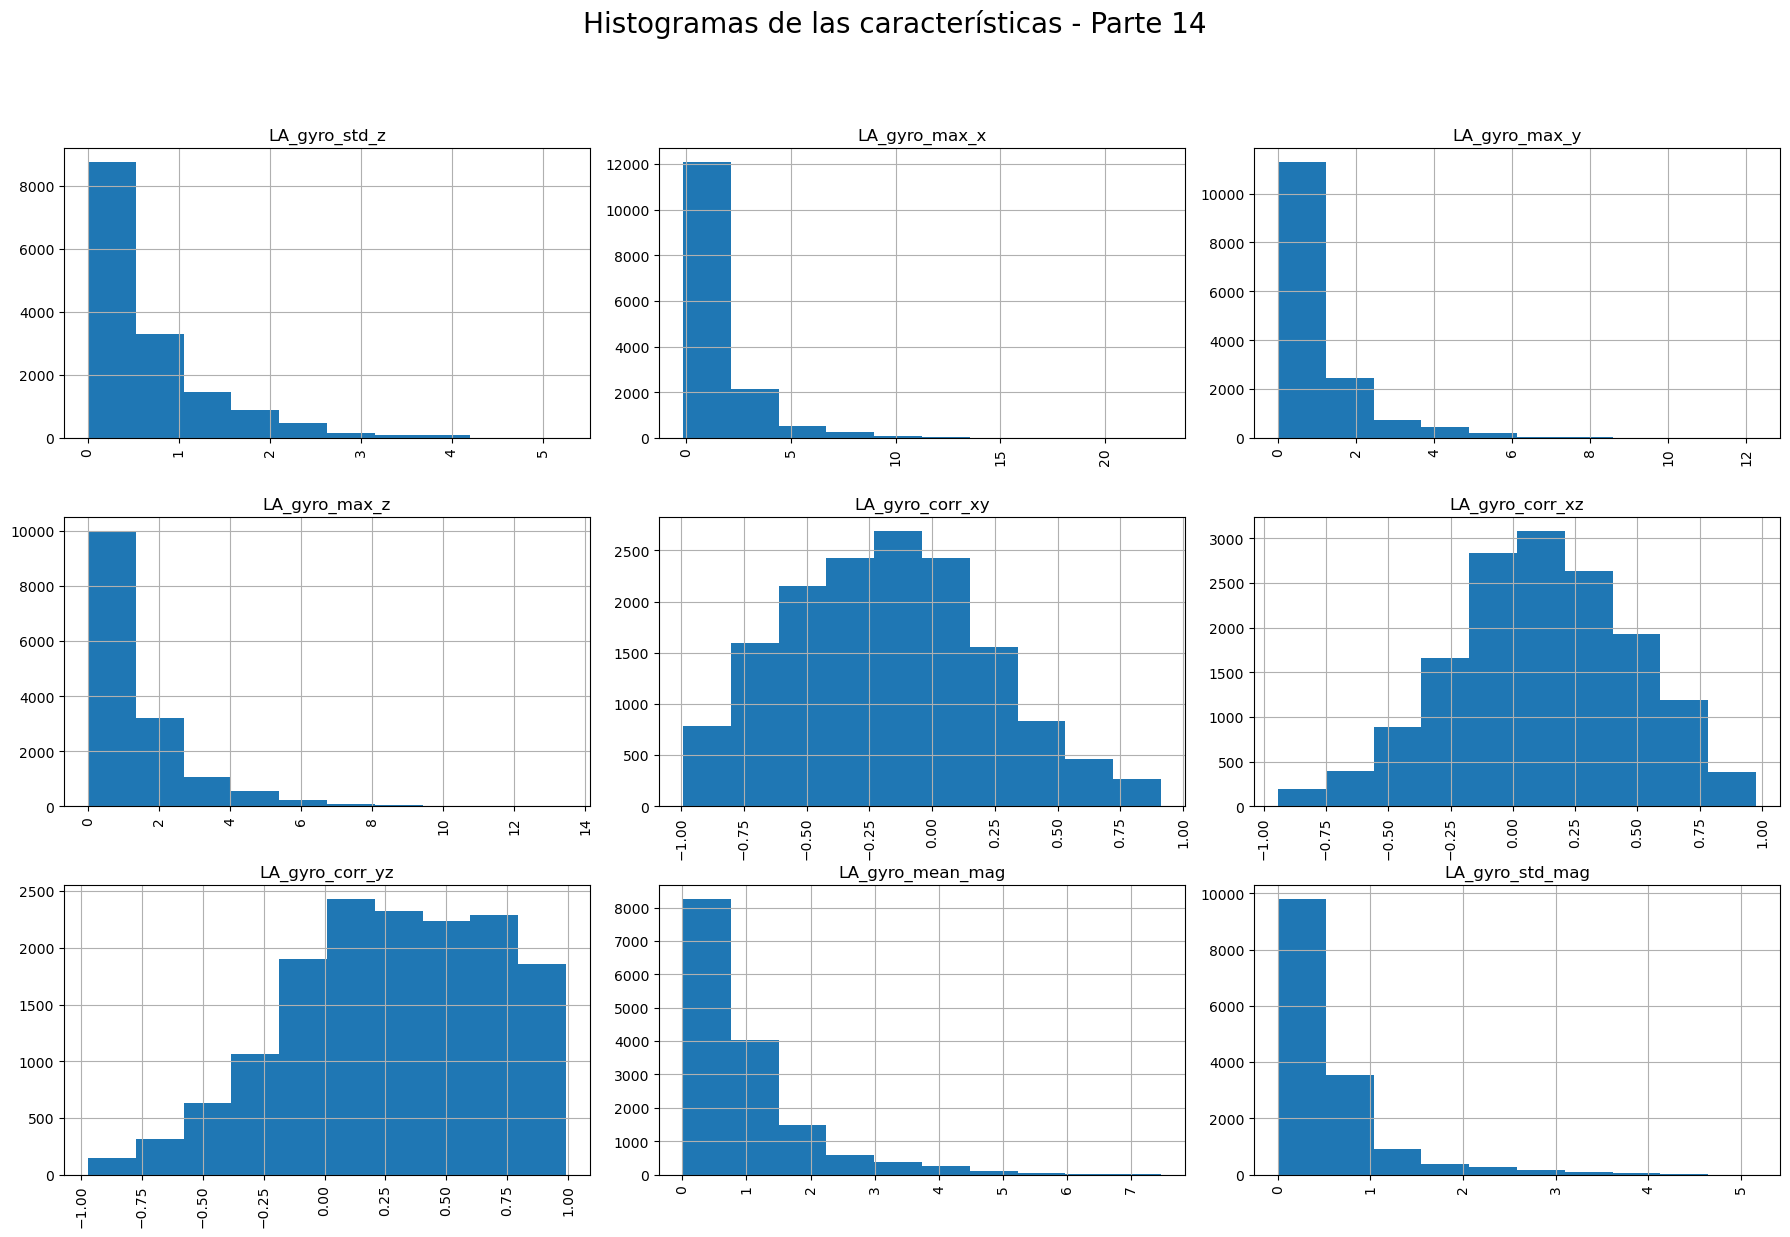

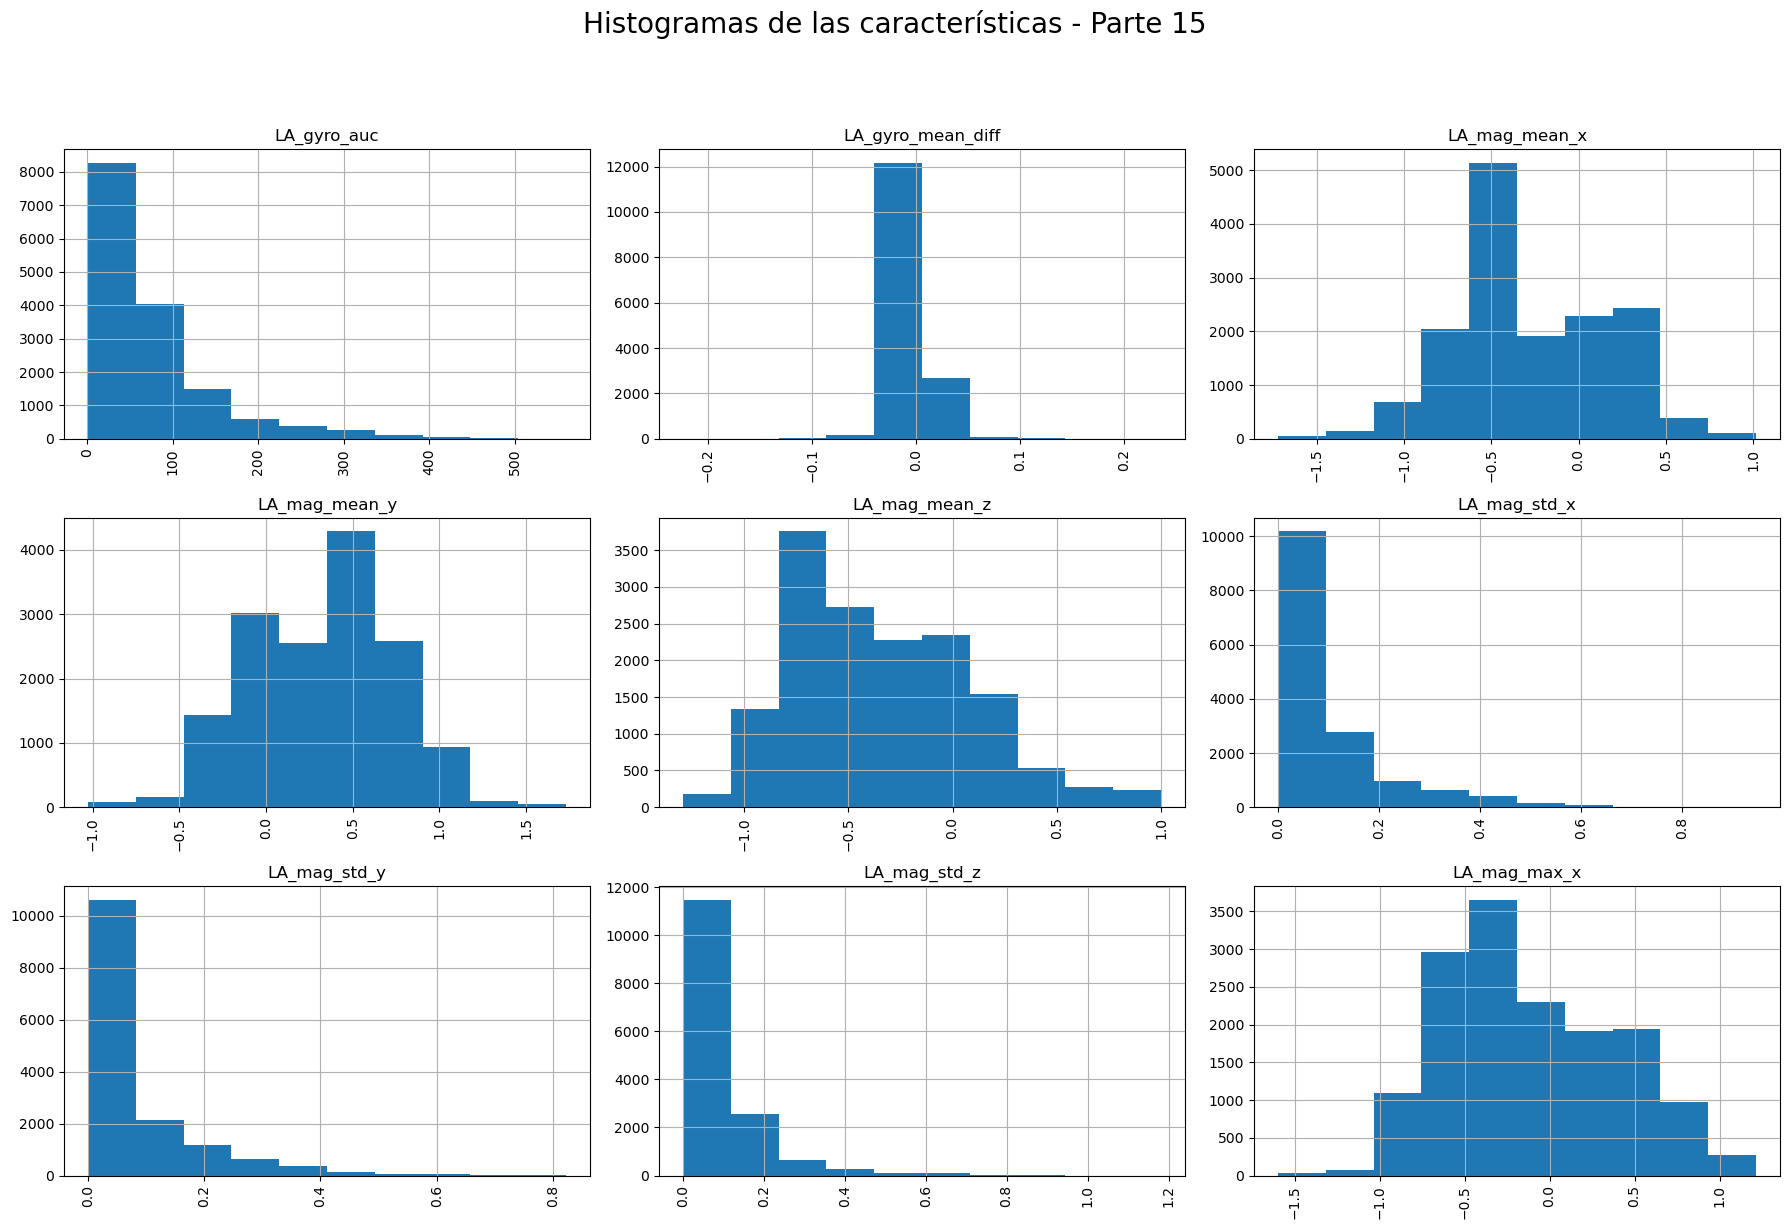

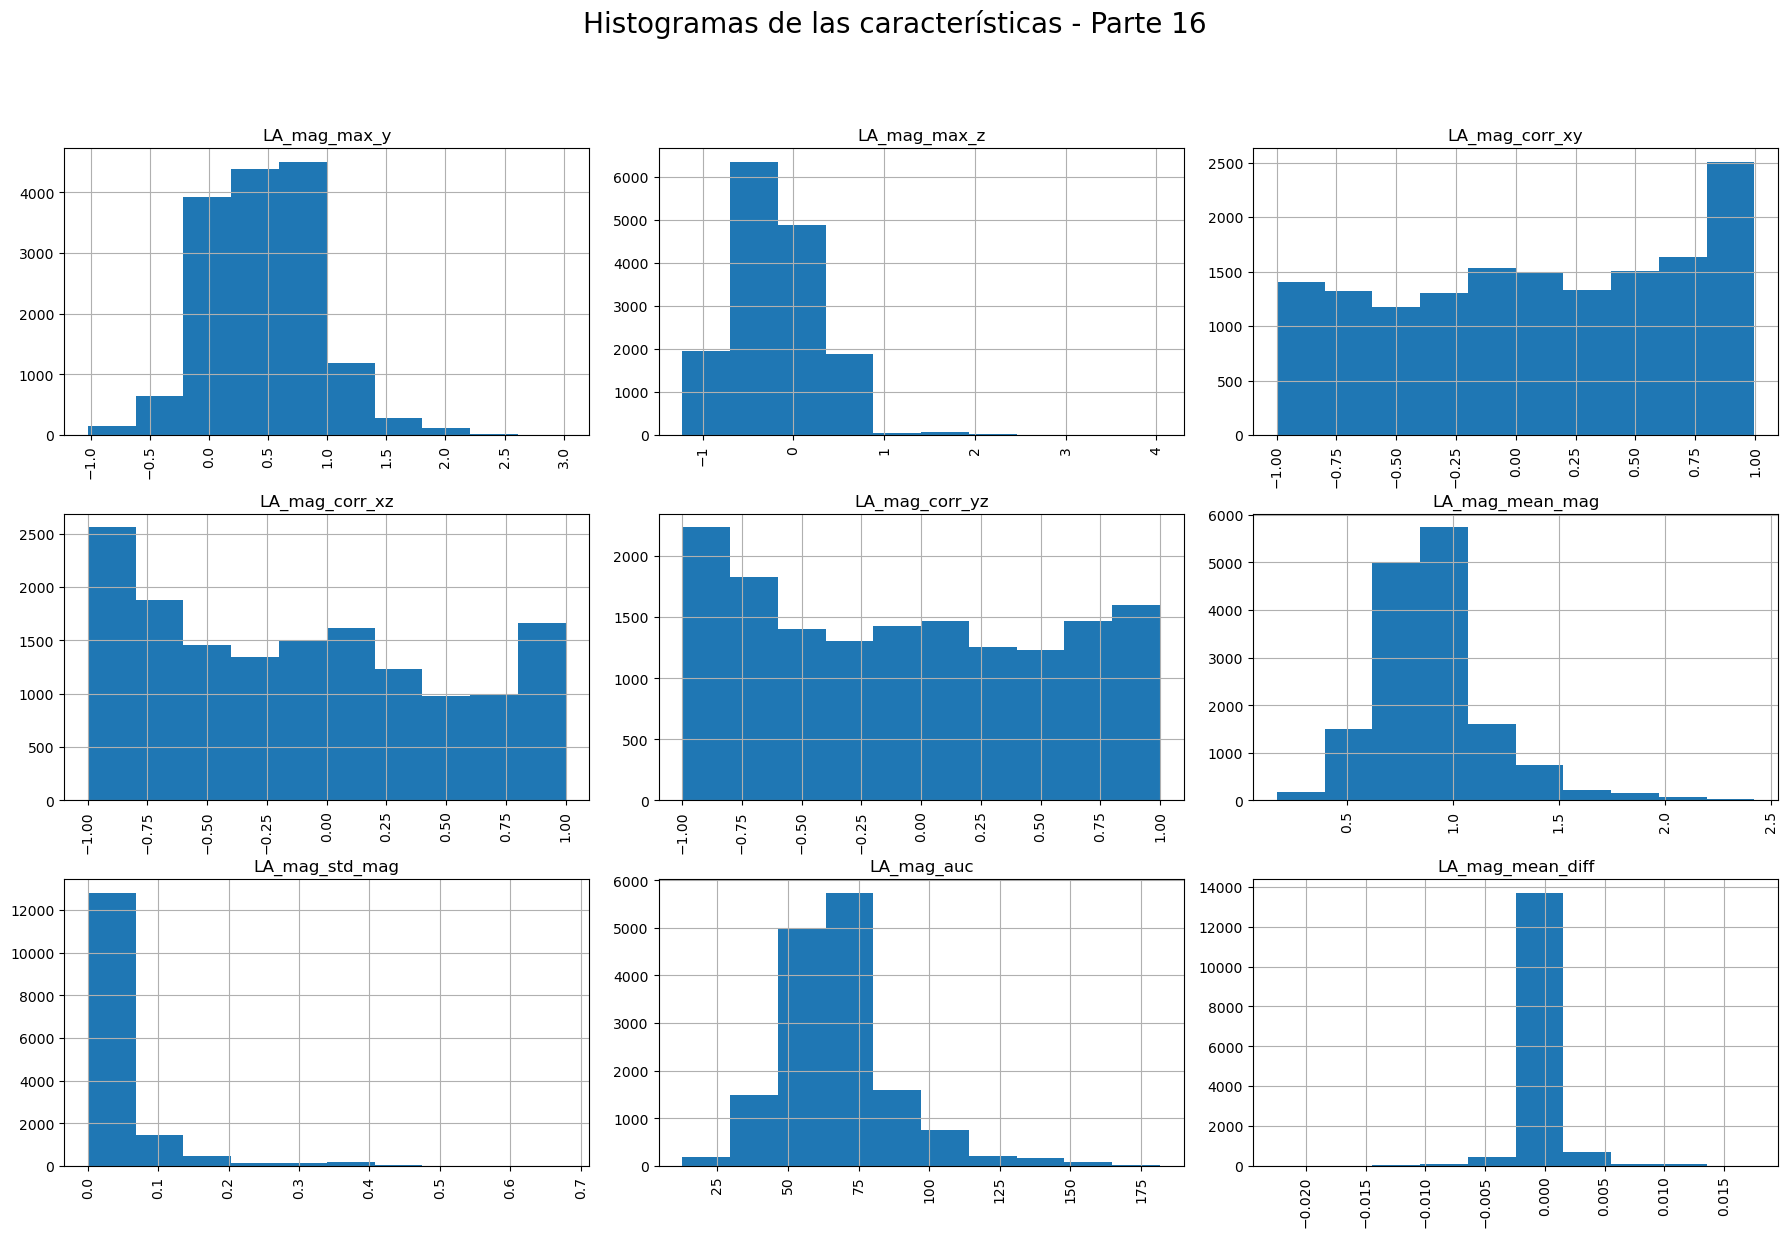

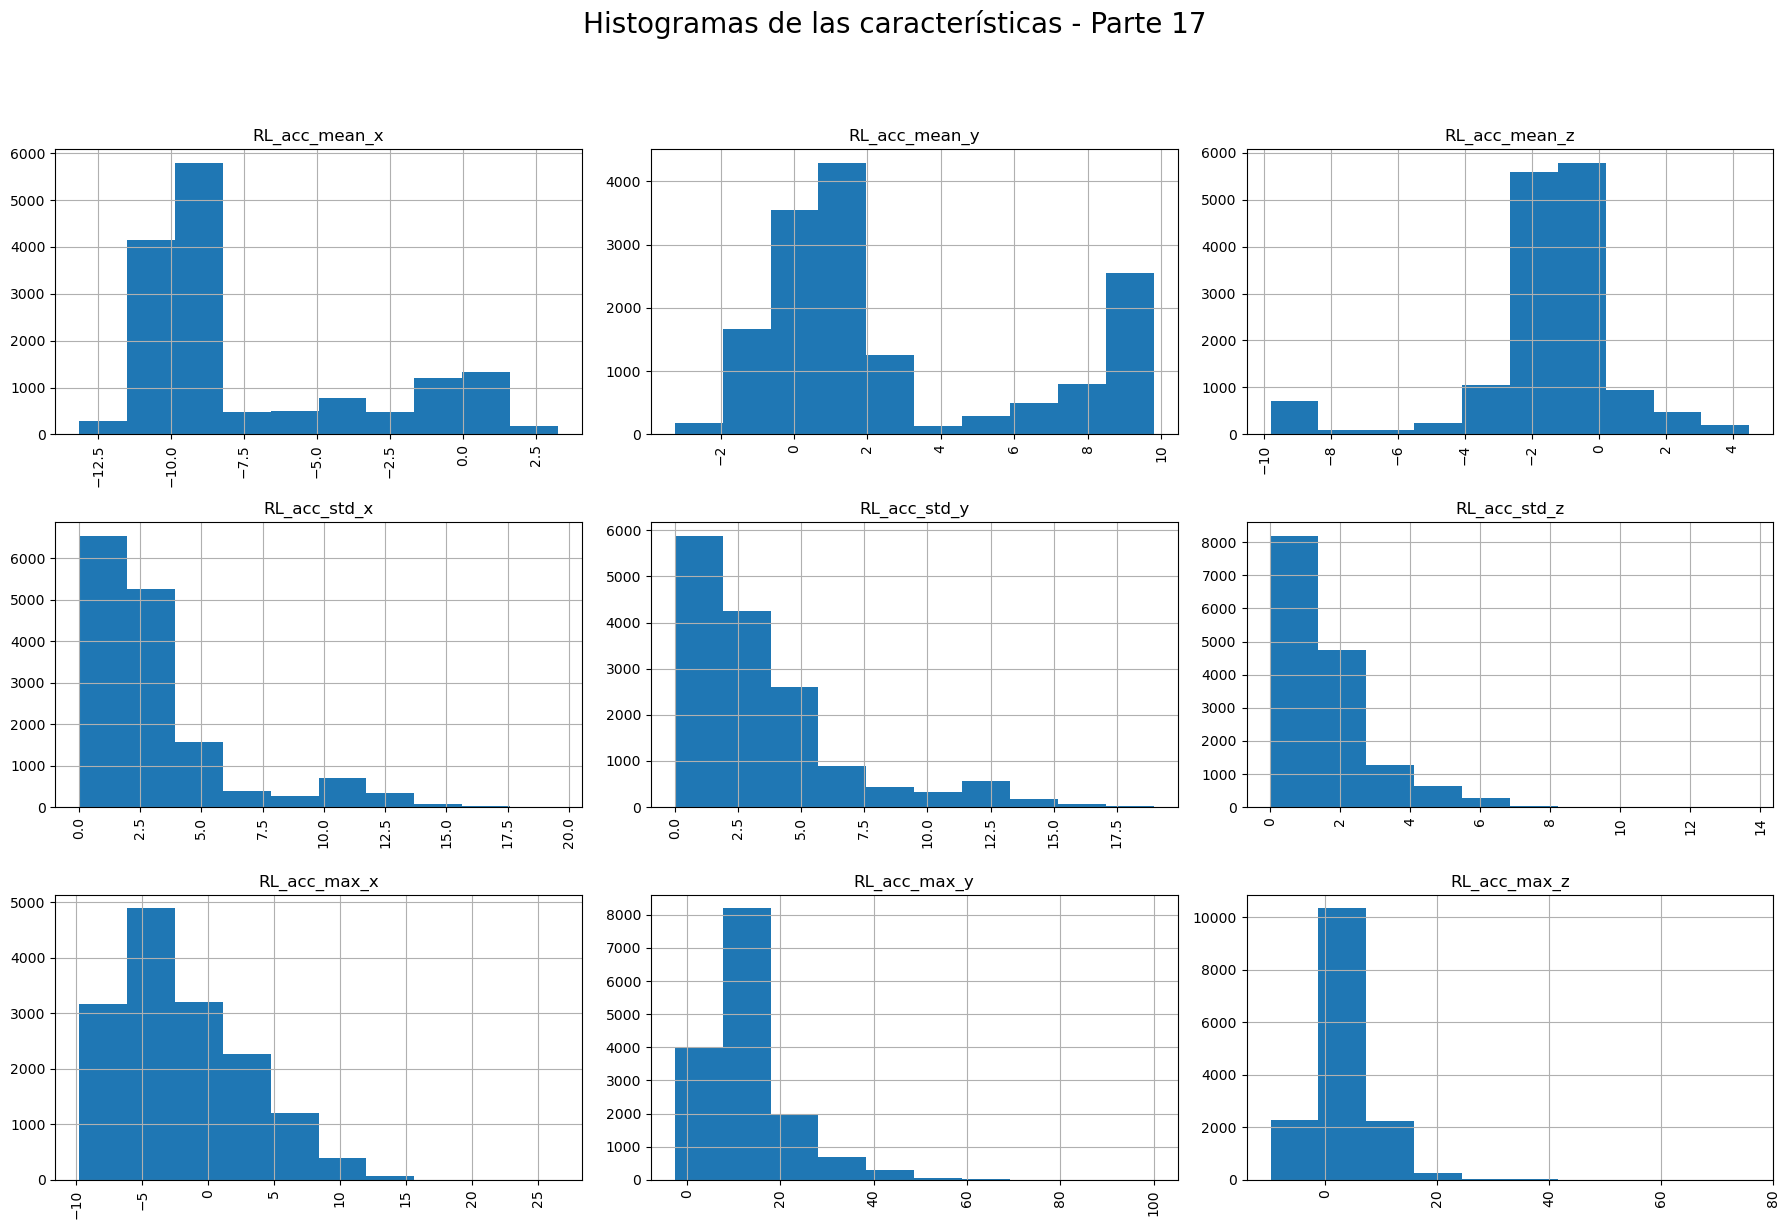

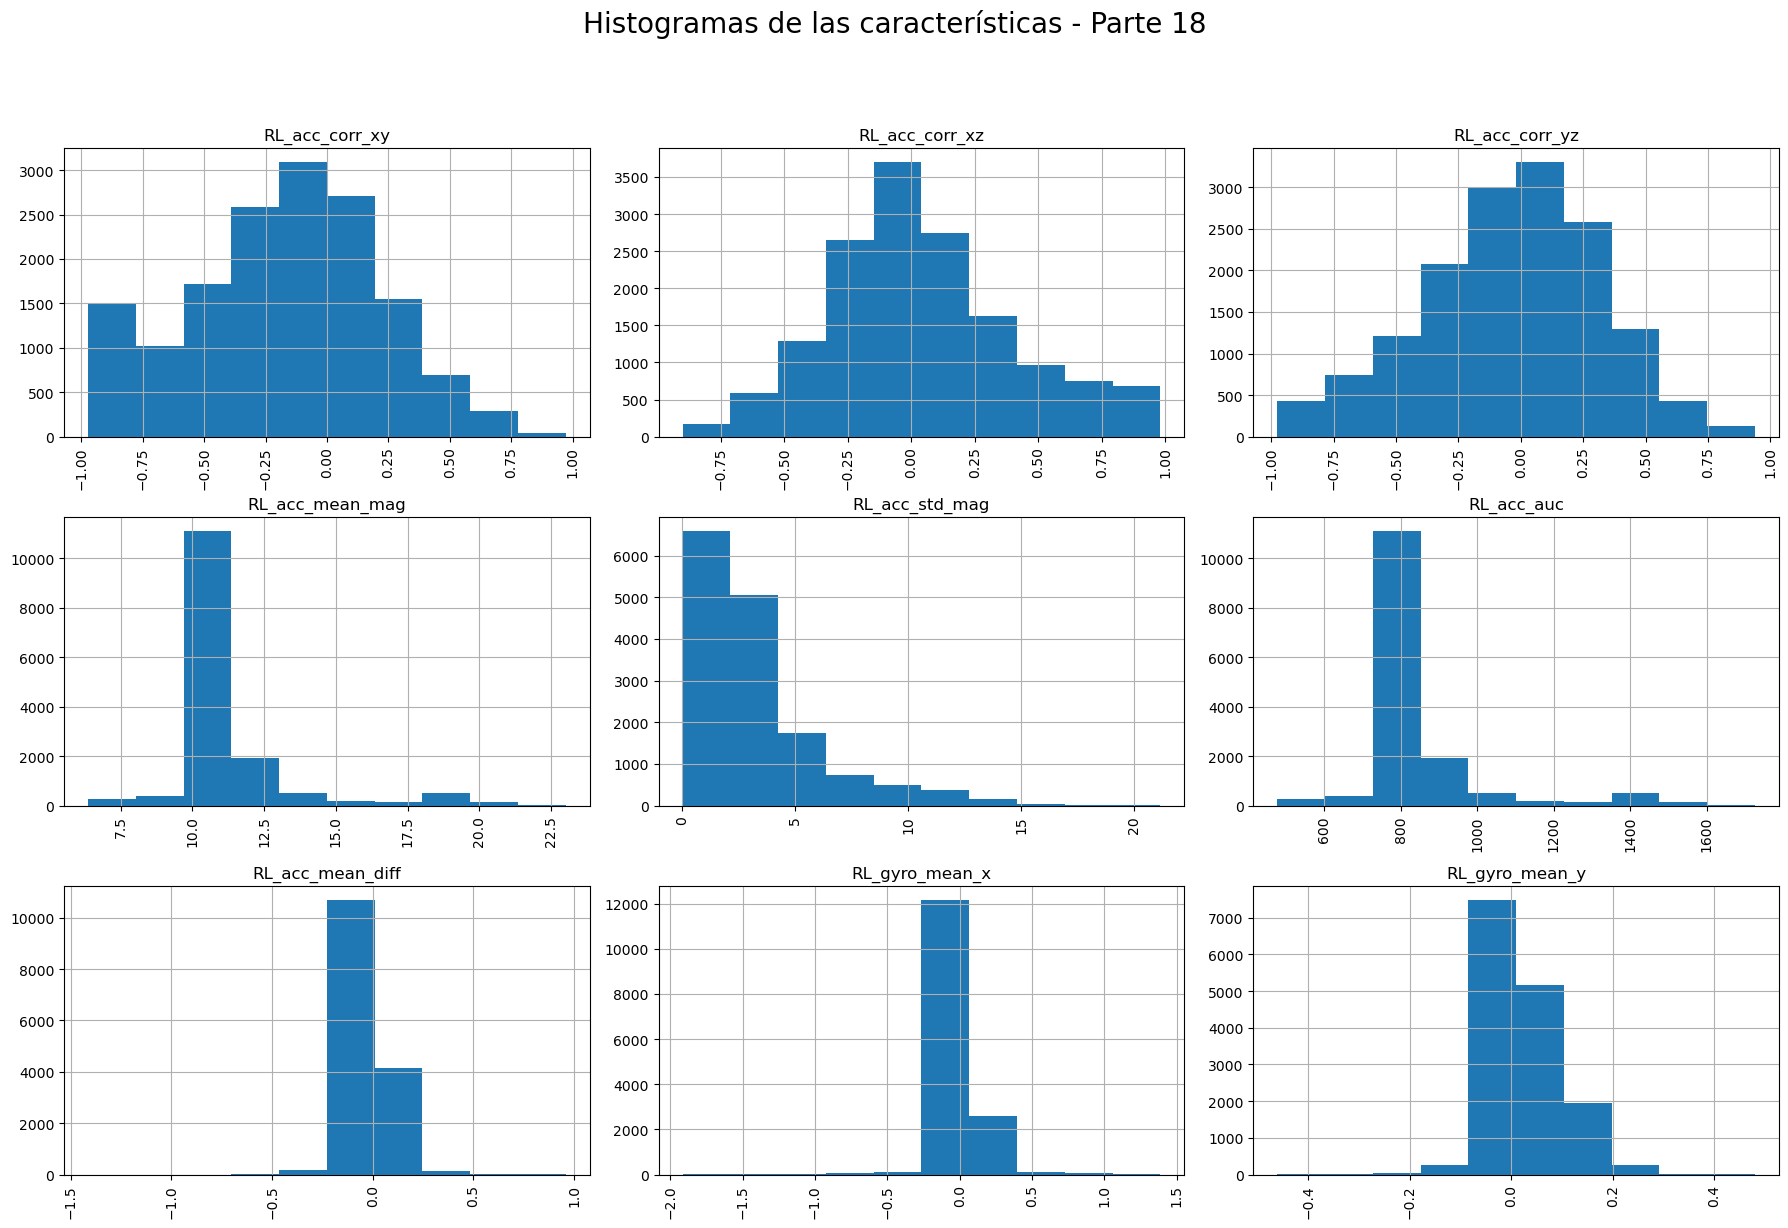

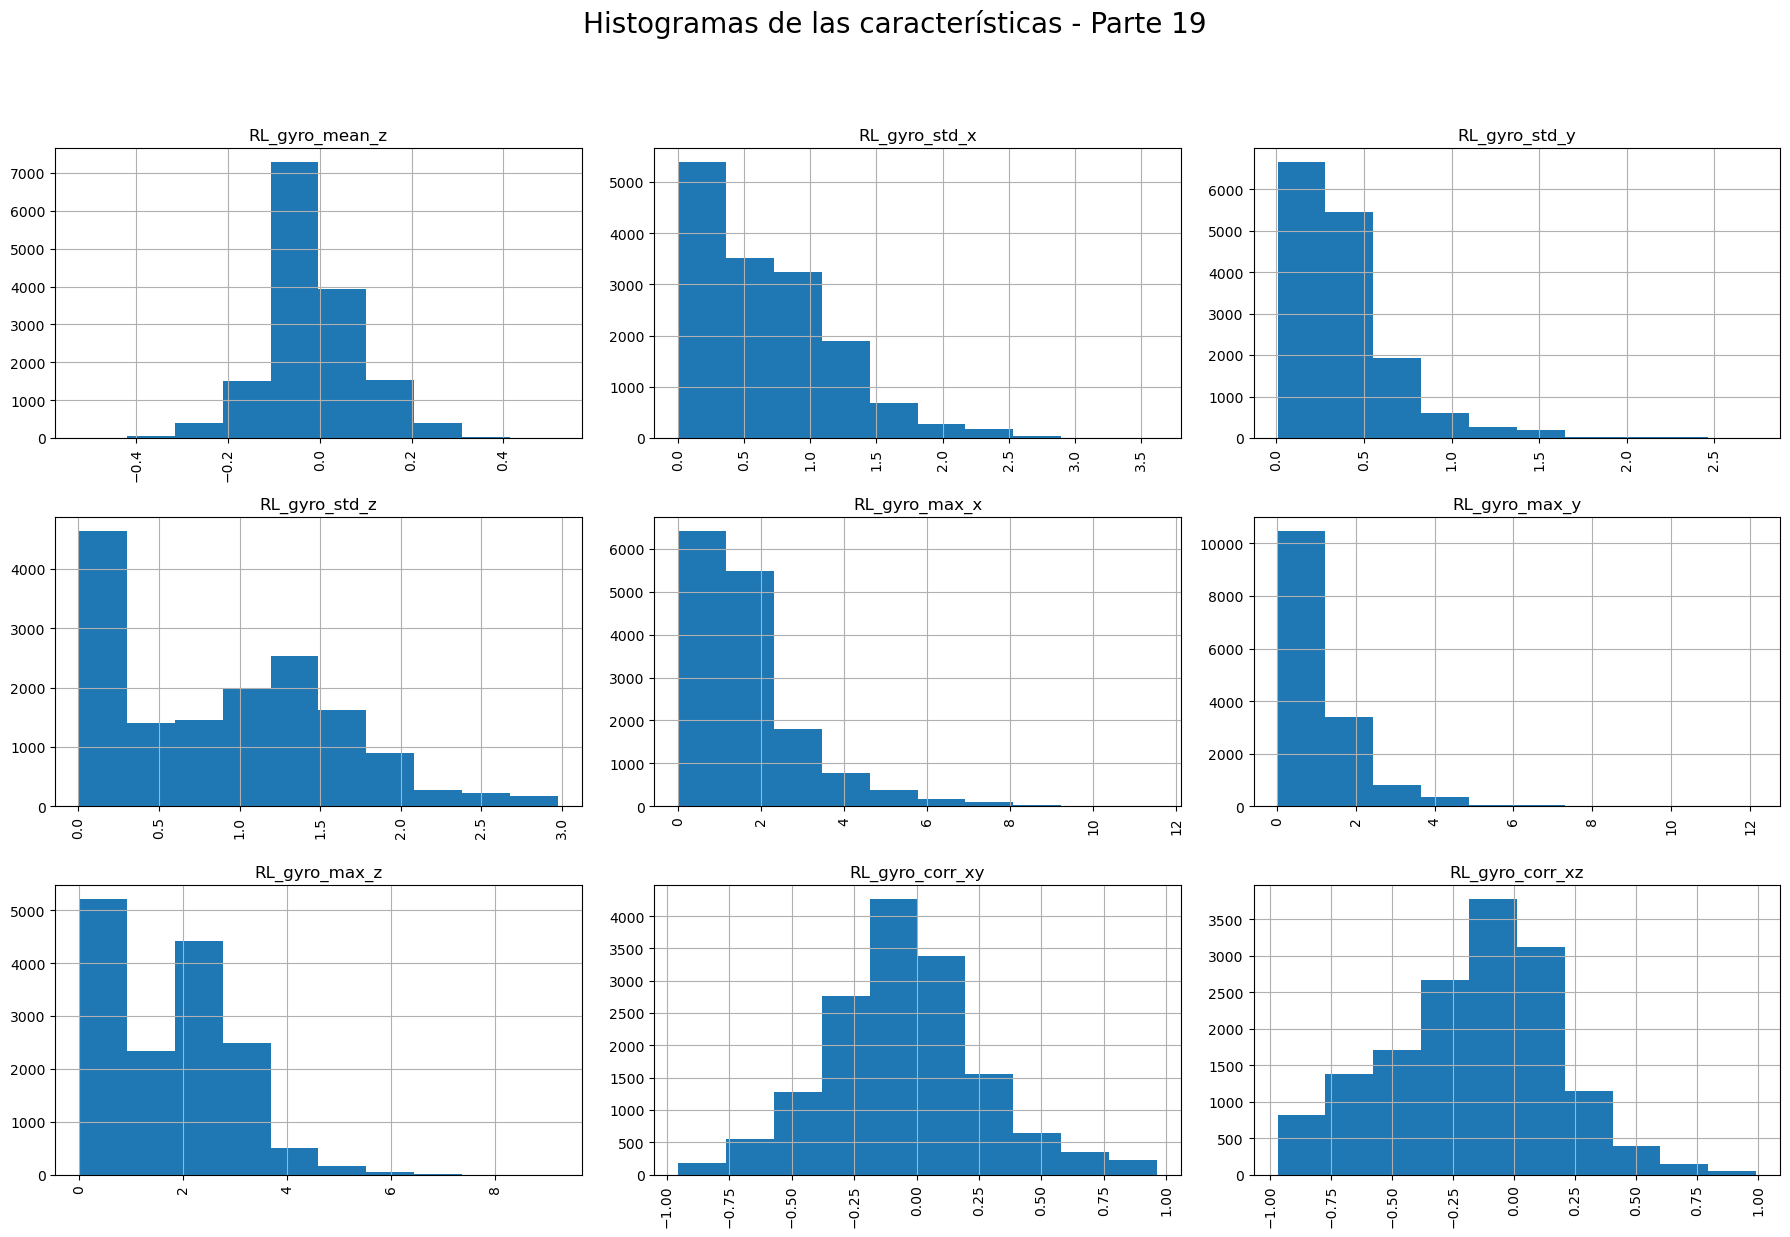

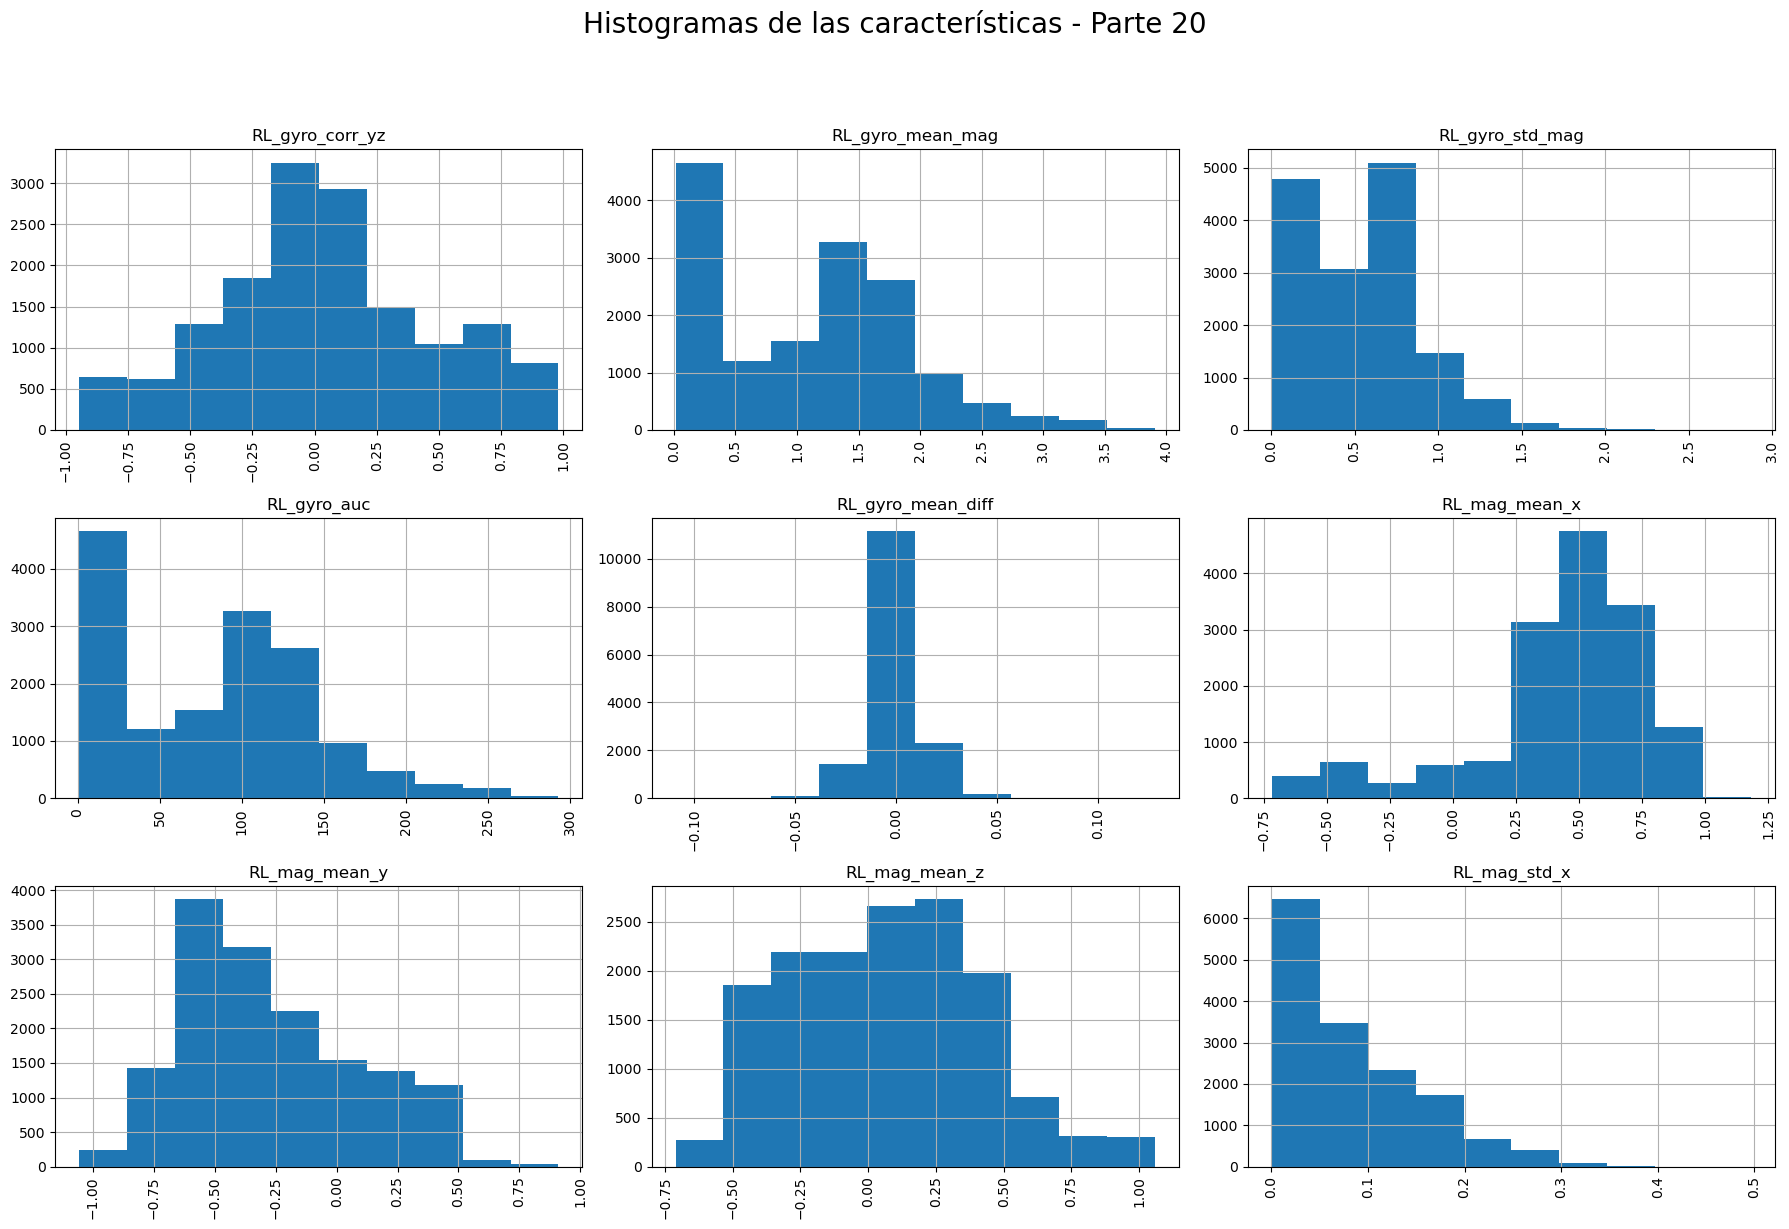

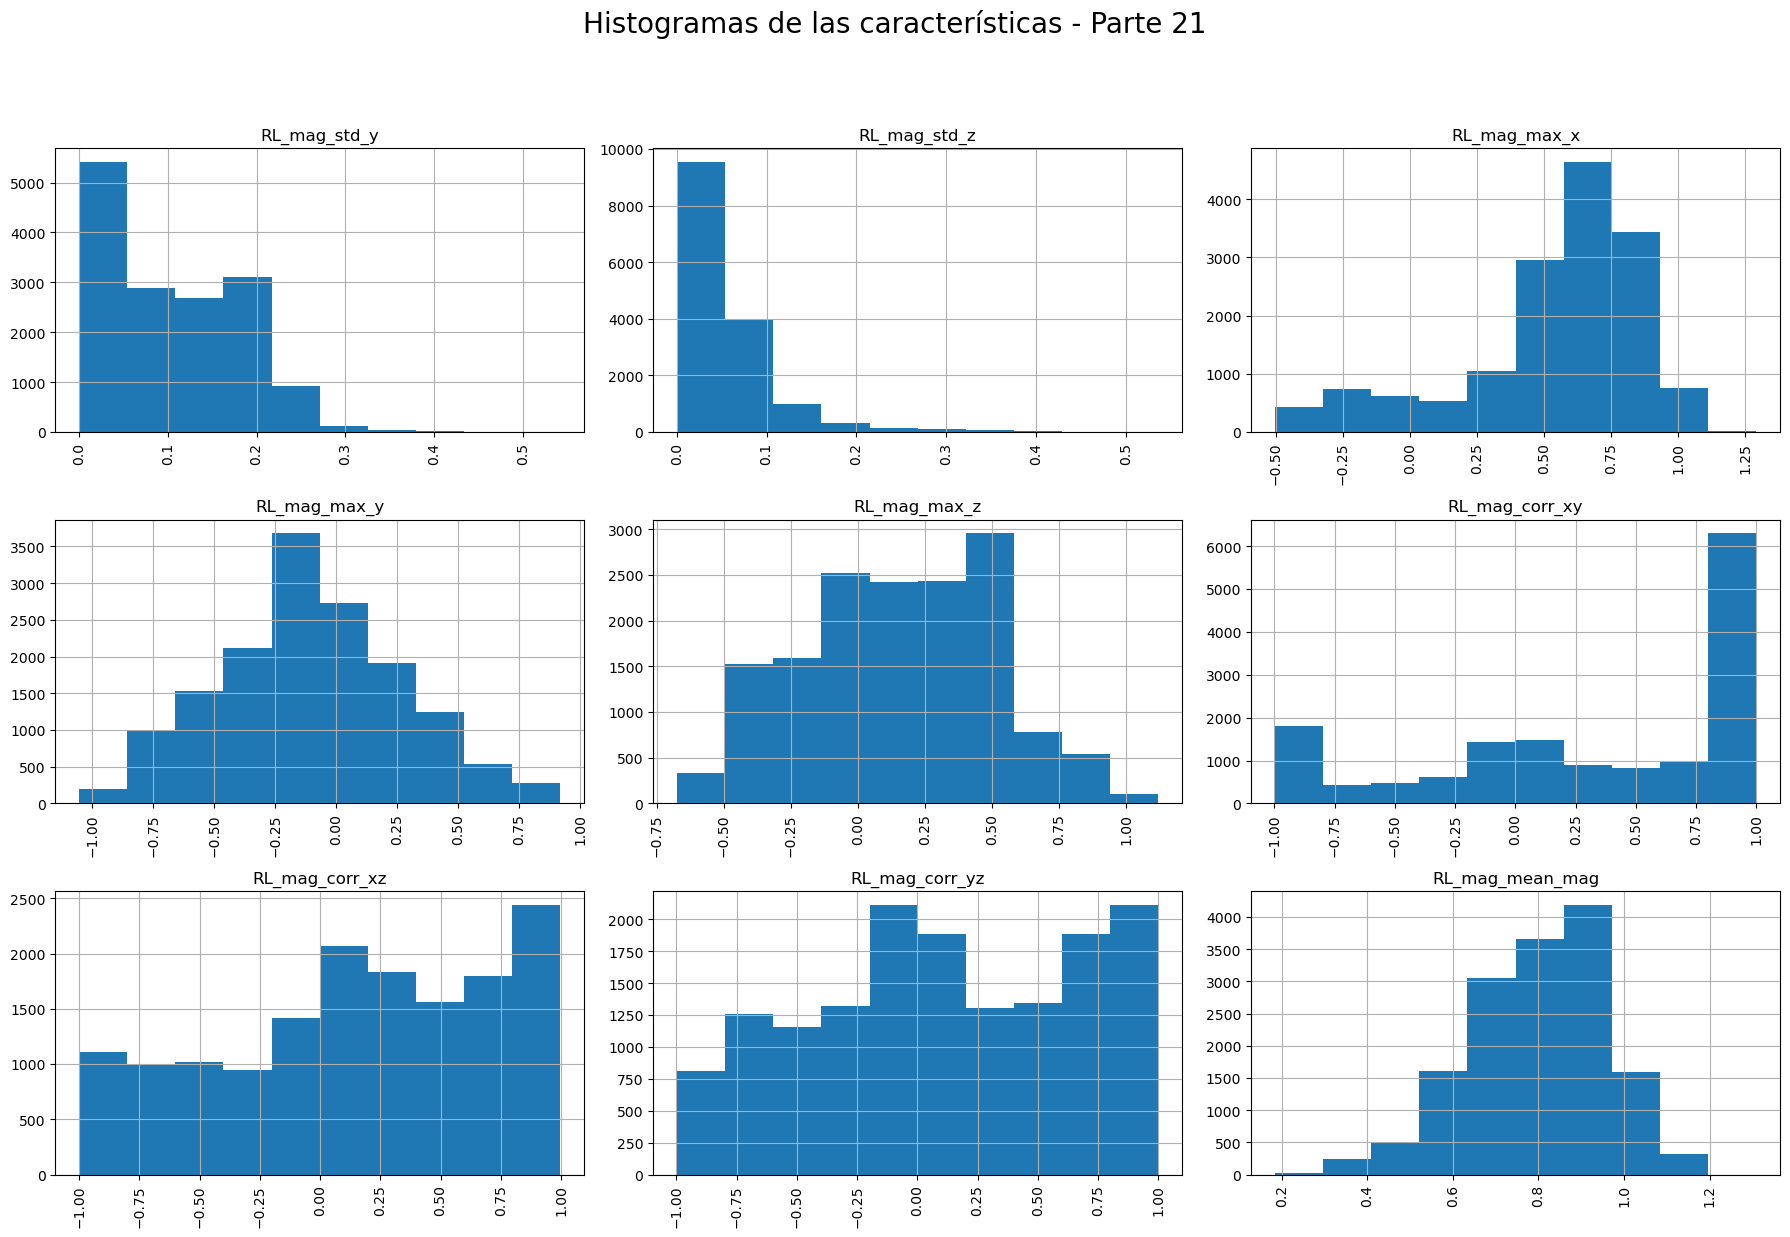

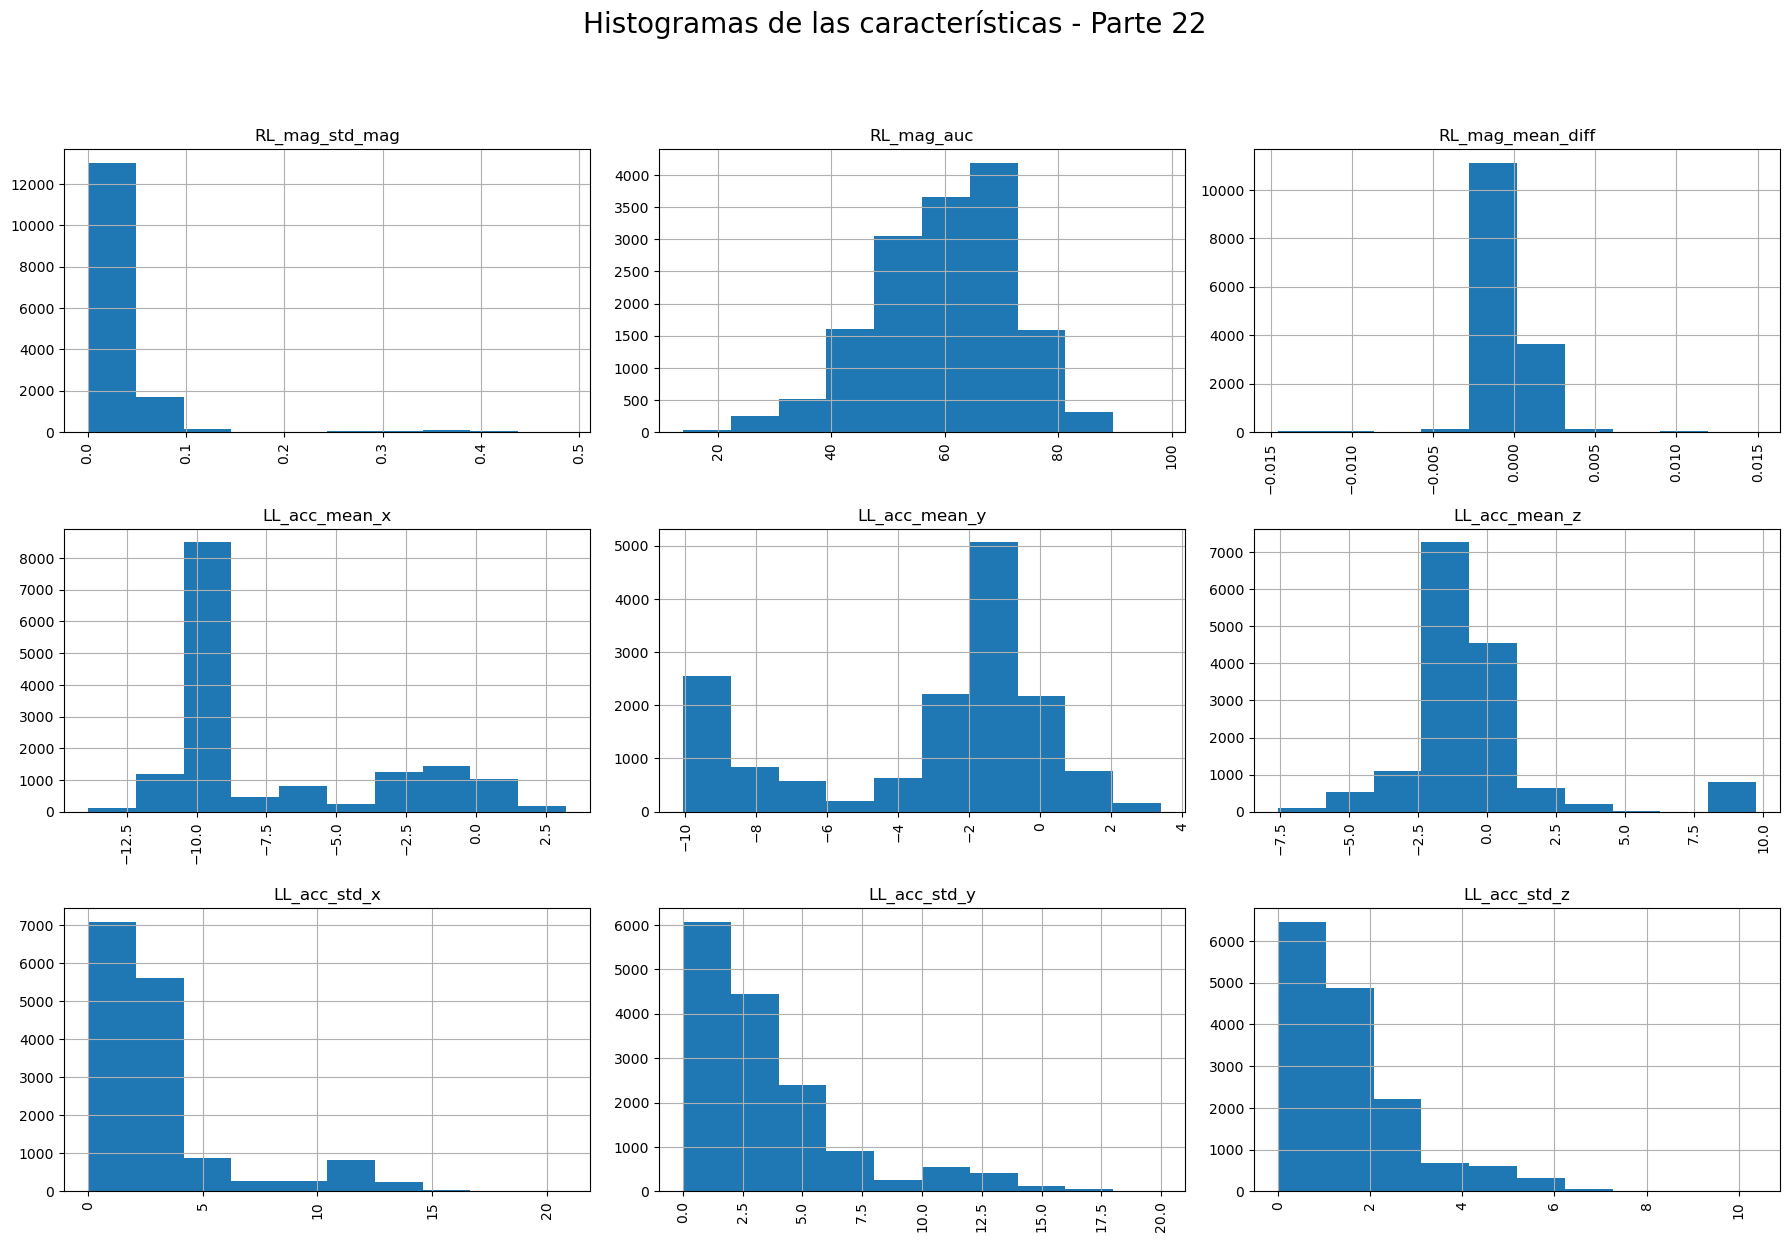

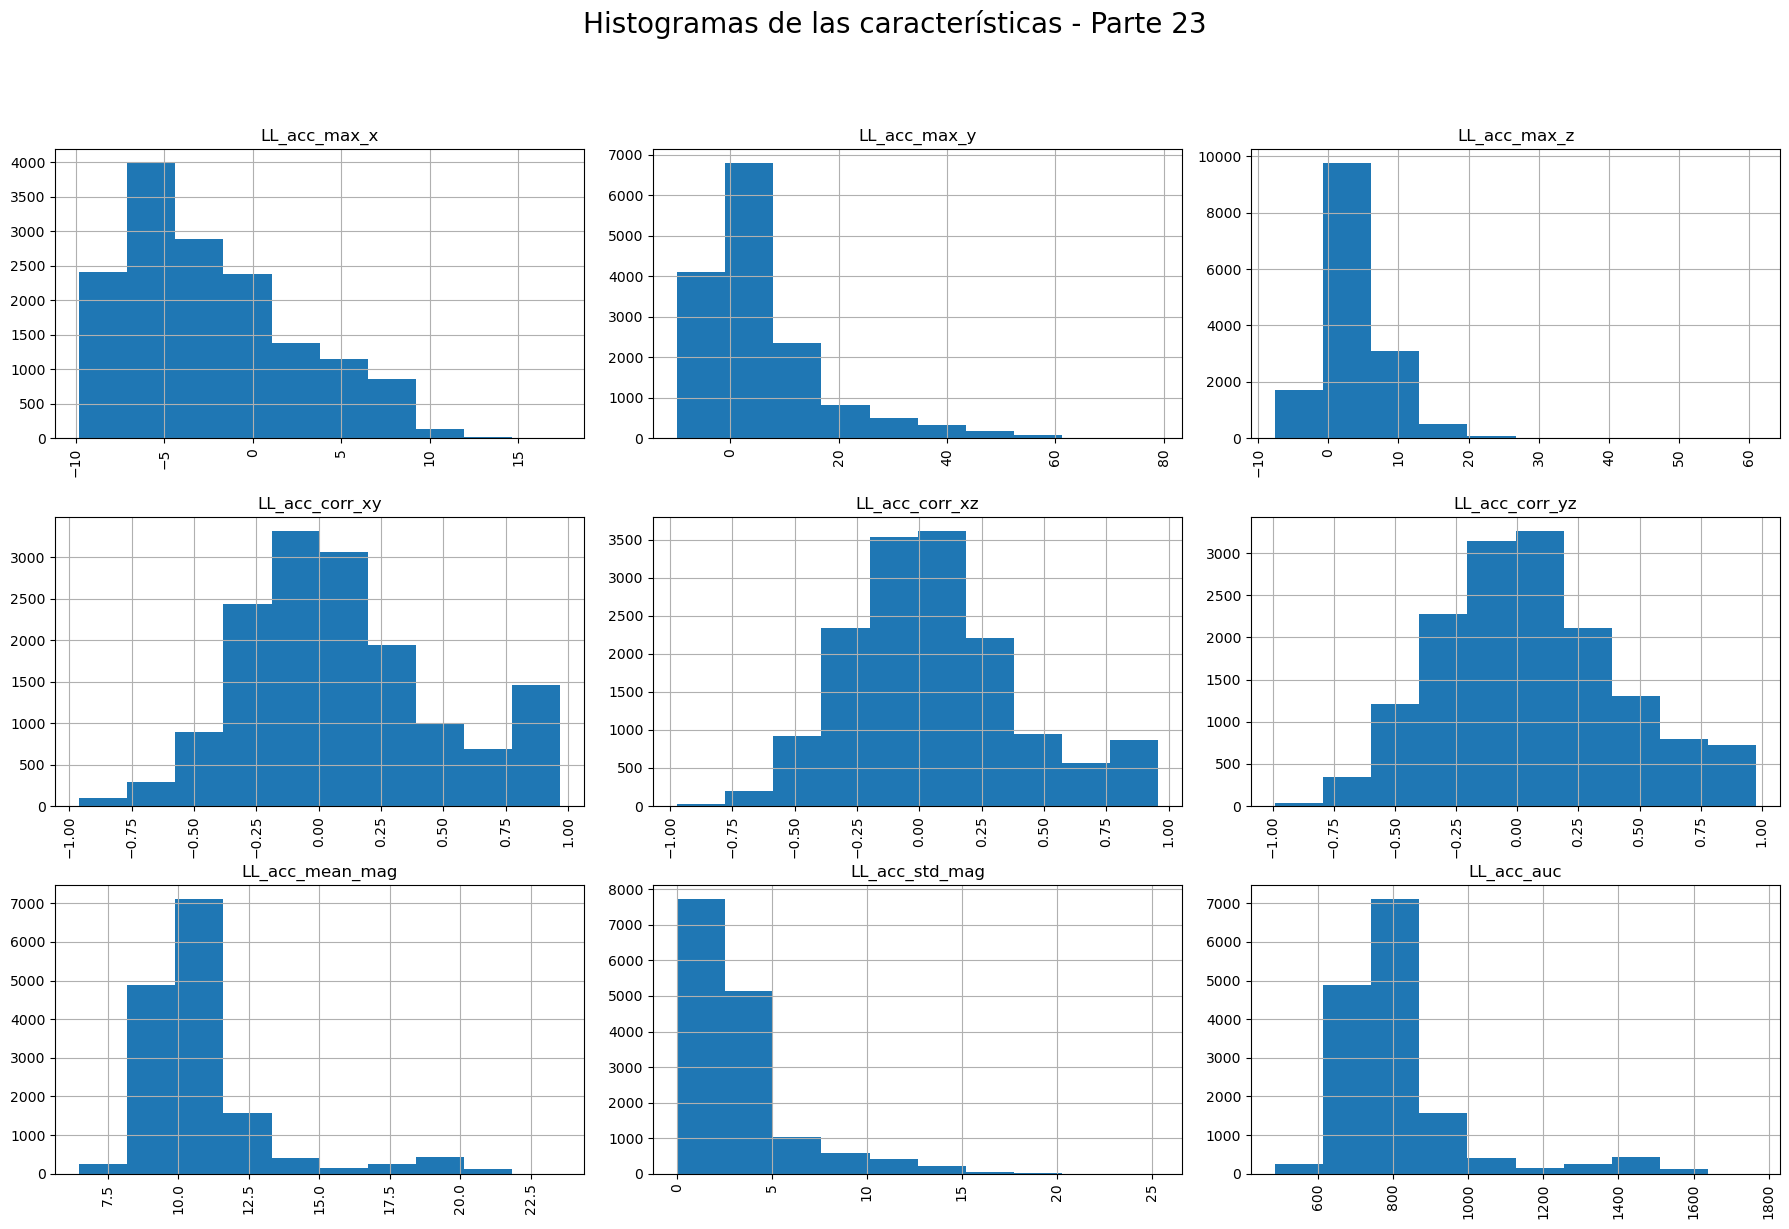

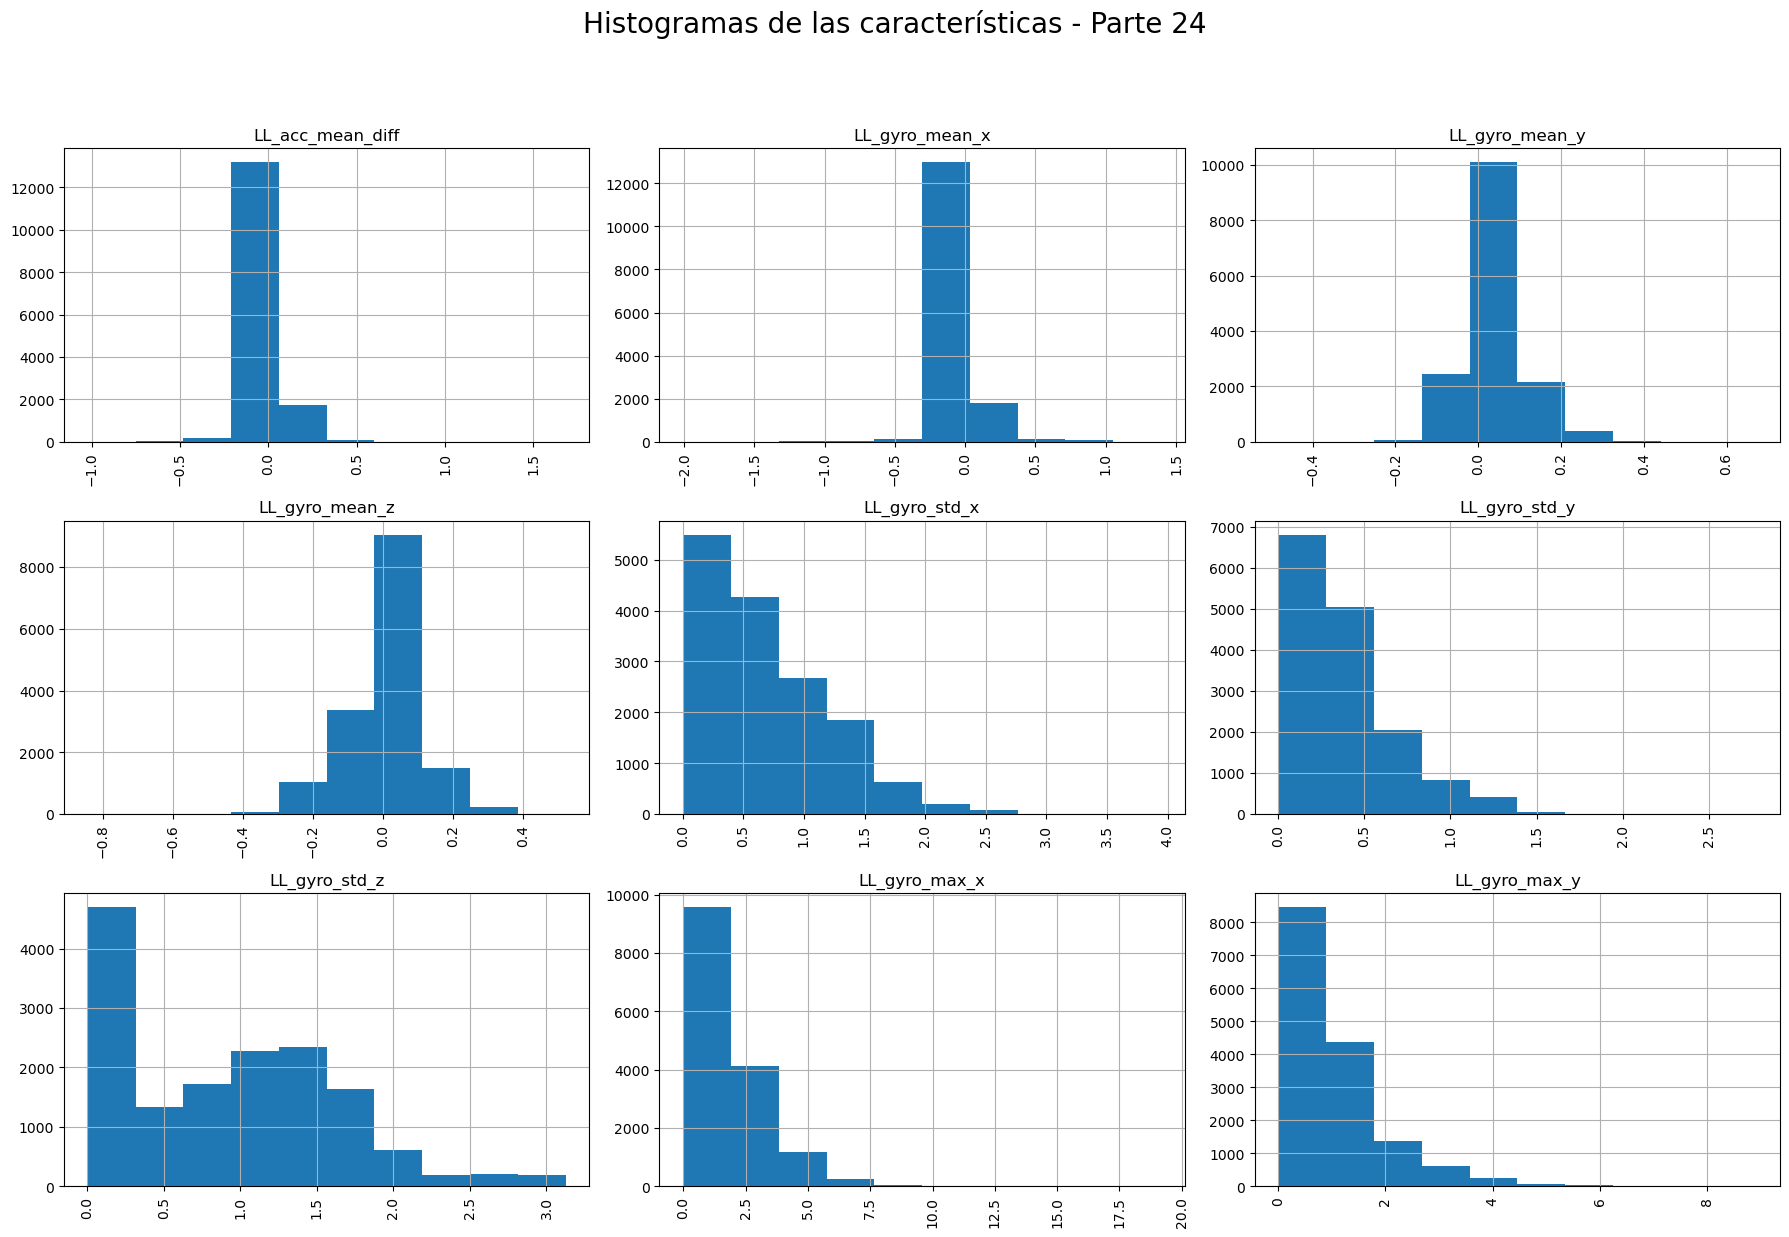

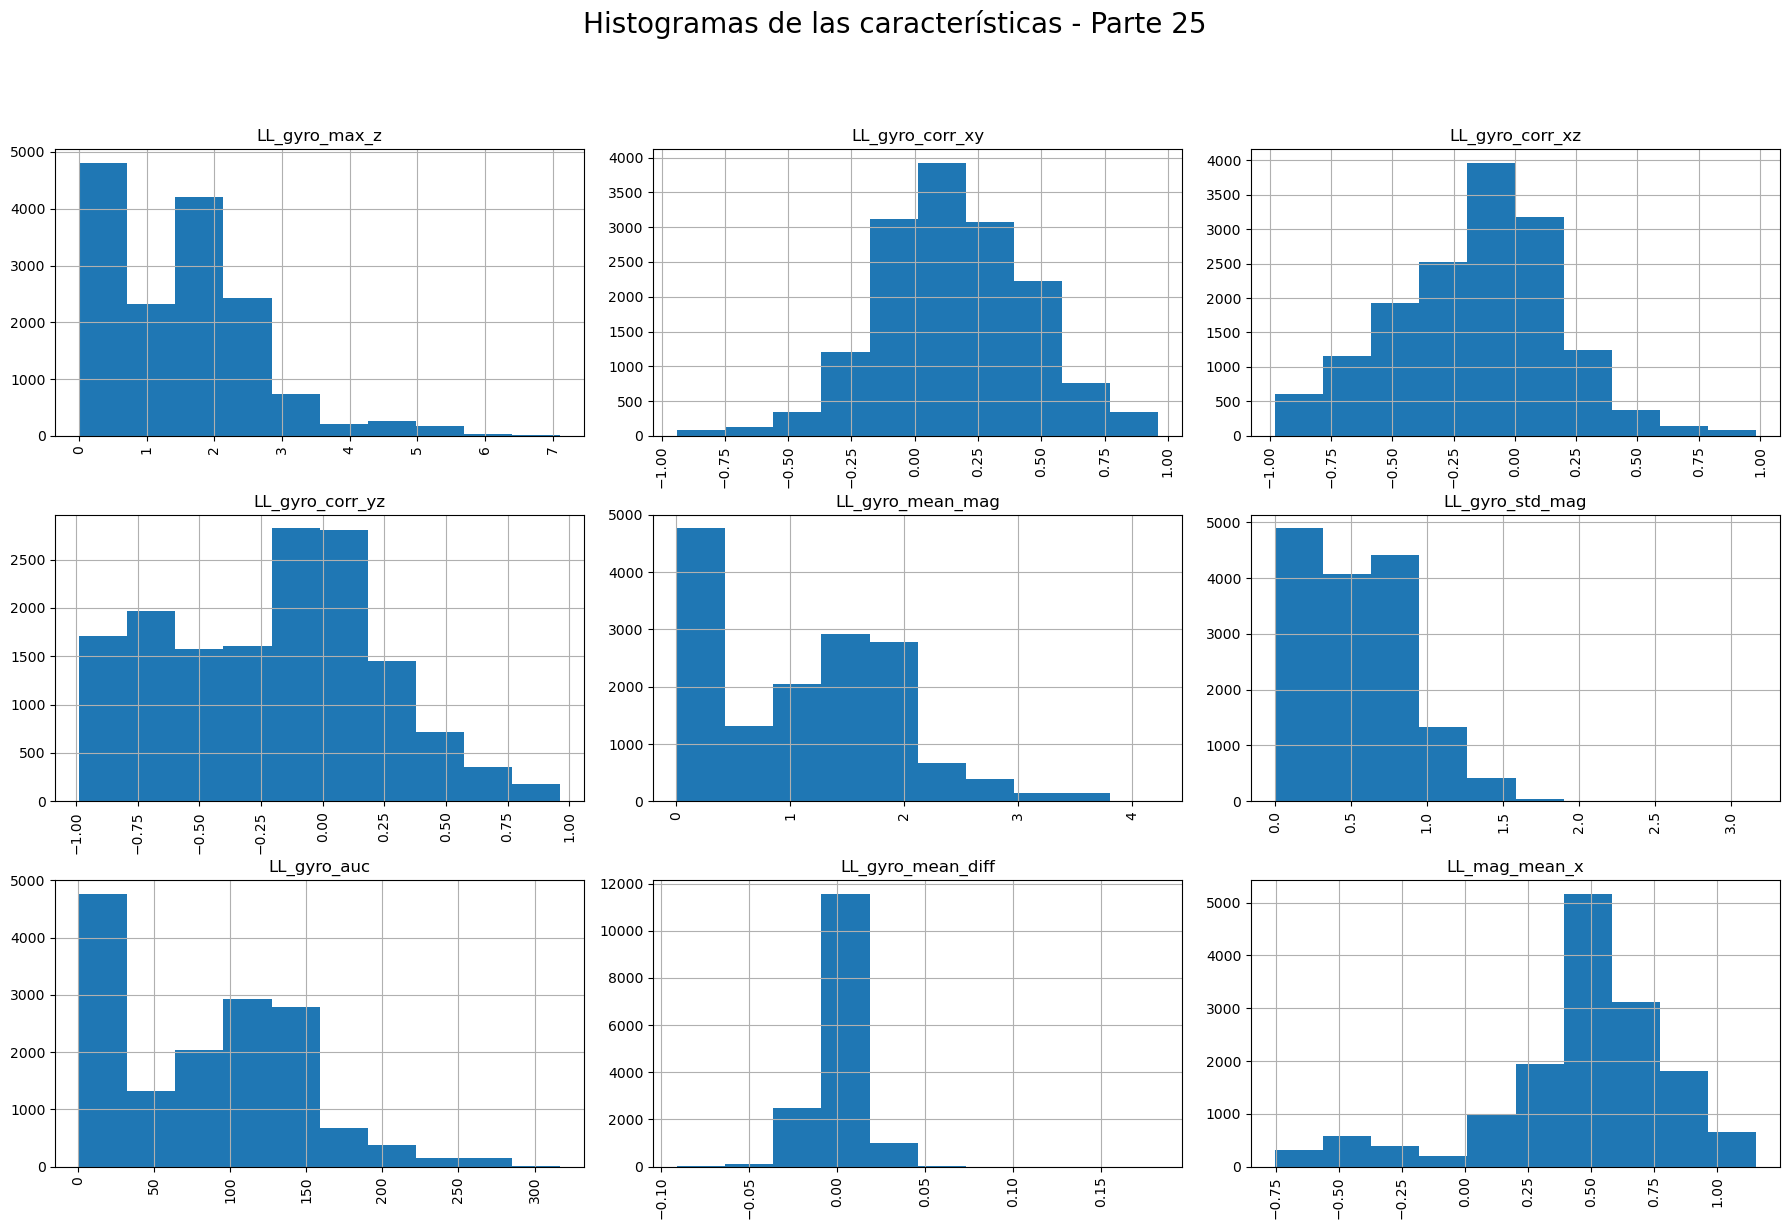

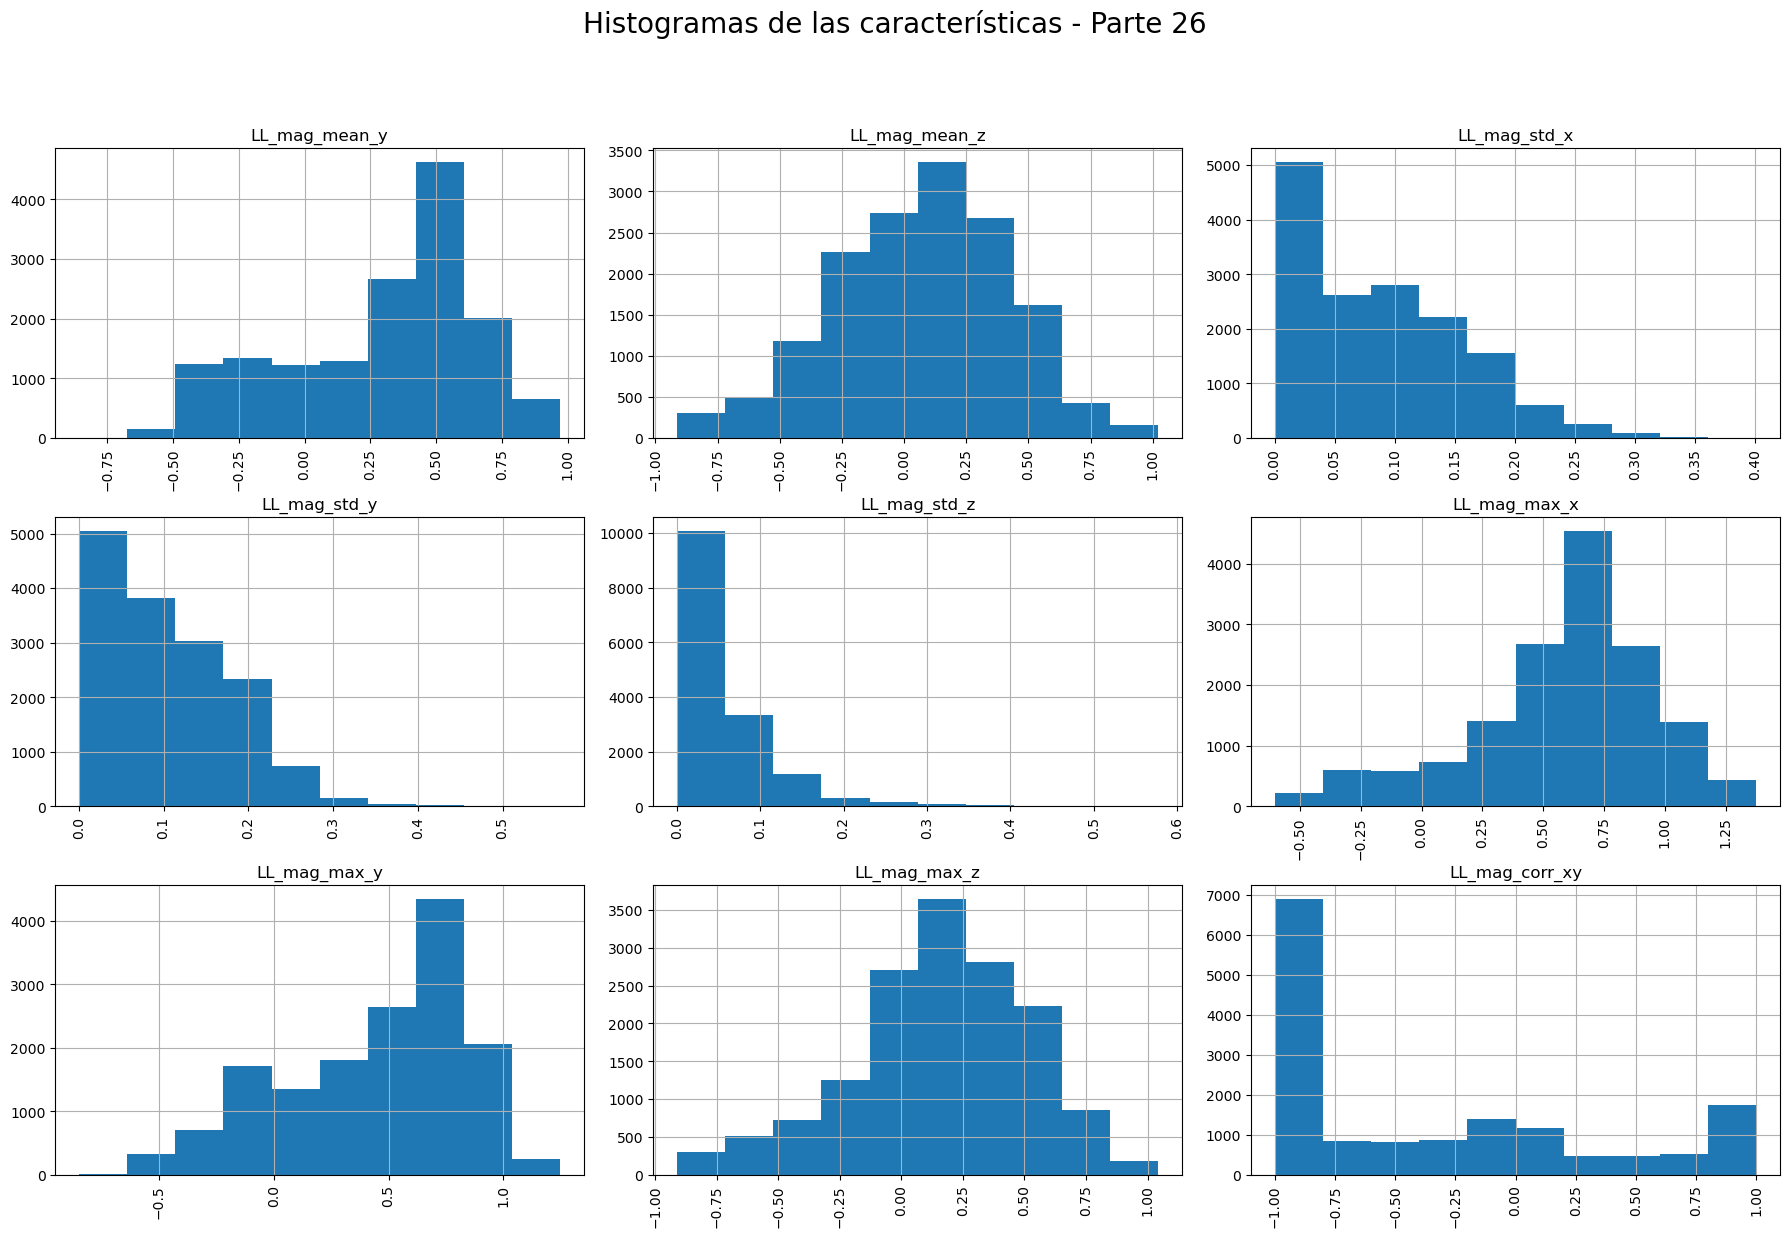

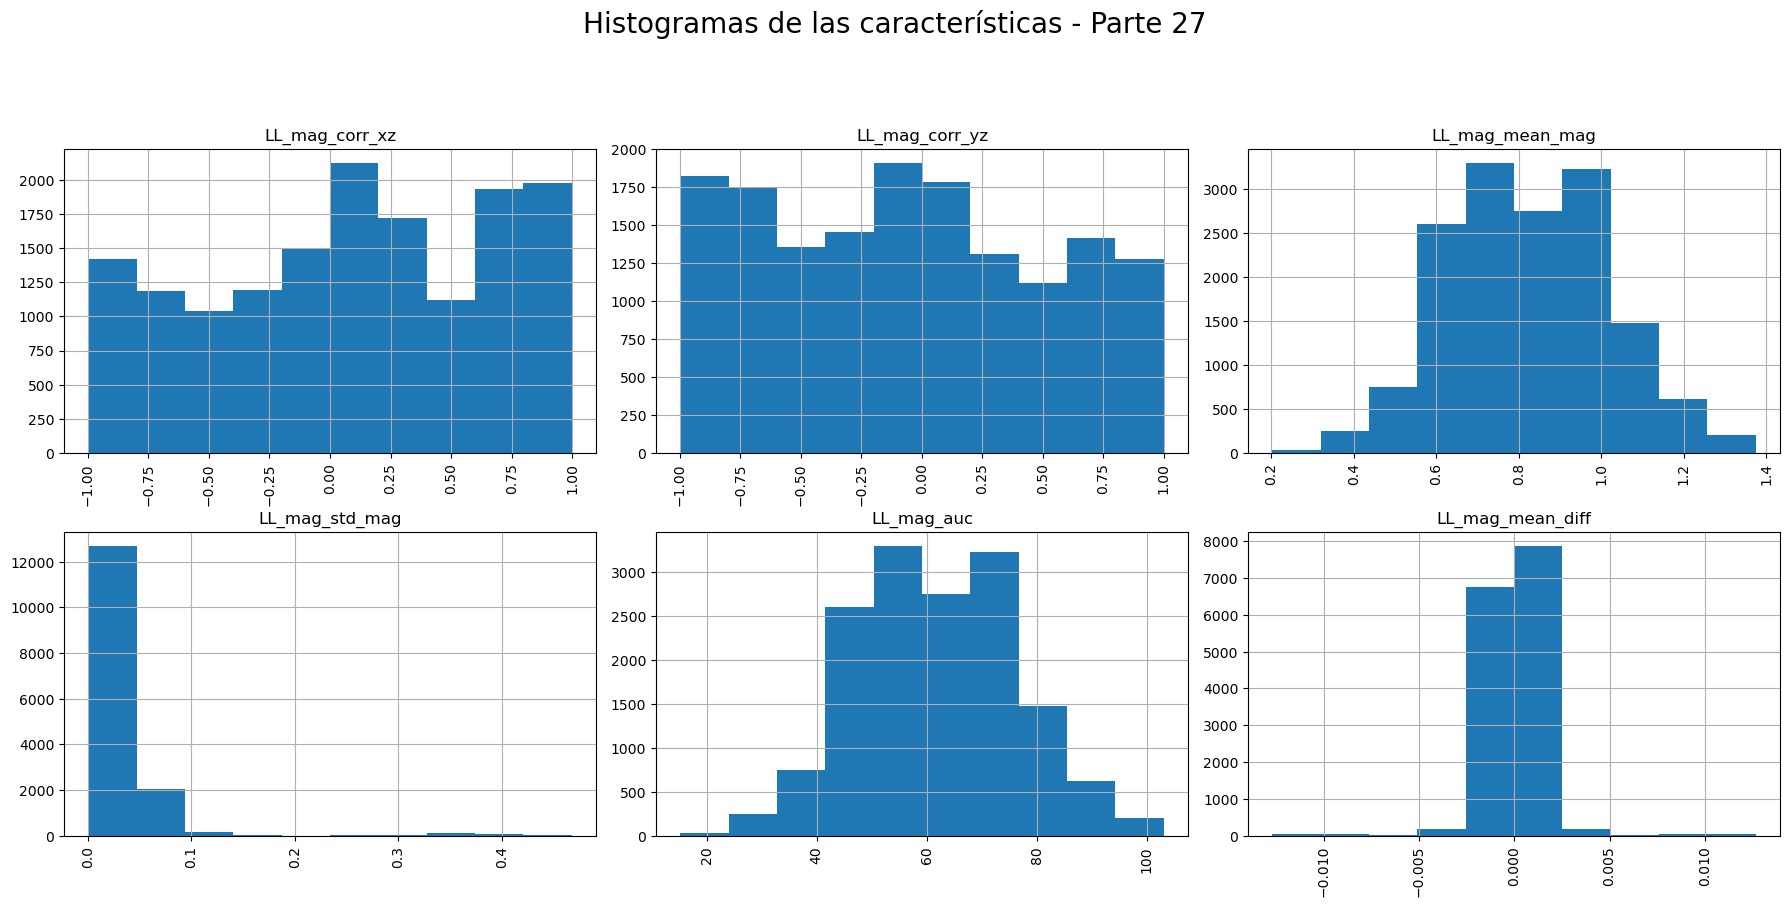

In [122]:
import math
import numpy as np
import matplotlib.pyplot as plt

# Drop 'activity' column if it exists, keeping only numeric columns
examples_db_numeric = examples_db.drop(columns=["activity"], errors="ignore")

# Number of numeric columns
num_features = len(examples_db_numeric.columns)

# Number of features per figure (e.g., 9 for a 3x3 grid)
num_features_per_figure = 9
num_figures = math.ceil(num_features / num_features_per_figure)

# Loop through the features in chunks
for i in range(num_figures):
    # Determine the subset of features for this figure
    start_idx = i * num_features_per_figure
    end_idx = min((i + 1) * num_features_per_figure, num_features)
    features_subset = examples_db_numeric.columns[start_idx:end_idx]
    df_subset = examples_db_numeric[features_subset]
    
    # Calculate grid size for the subset
    n = math.ceil(math.sqrt(len(features_subset)))
    figsize = (6 * n, 4 * n)  # e.g., (18, 12) for n=3
    
    # Create the histograms
    axes = df_subset.hist(
        bins=10,
        figsize=figsize,
        layout=(n, n),
        sharex=False,
        sharey=False
    )
    
    # Flatten axes if it's a 2D array
    if isinstance(axes, np.ndarray):
        axes = axes.flatten()
    else:
        axes = [axes]
    
    # Adjust each subplot
    for ax in axes:
        ax.tick_params(axis='x', labelrotation=90, labelsize=10)
        ax.tick_params(axis='y', labelsize=10)
        ax.set_title(ax.get_title(), fontsize=12)
    
    # Adjust spacing between subplots
    plt.subplots_adjust(wspace=0.4, hspace=0.4)
    
    # Add a main title
    plt.suptitle(f"Histogramas de las características - Parte {i+1}", fontsize=20, y=1.02)
    
    # Use tight_layout with a rect to prevent overlap
    plt.tight_layout(rect=[0, 0, 1, 0.97])
    plt.show()

## 2.2. Train/test split: cross validation

In [ ]:
def get_Train_test(train): 
    SENSORS = [
        "T_xacc", "T_yacc", "T_zacc",
        "T_xgyro", "T_ygyro", "T_zgyro",
        "T_xmag", "T_ymag", "T_zmag",
        "RA_xacc", "RA_yacc", "RA_zacc",
        "RA_xgyro", "RA_ygyro", "RA_zgyro",
        "RA_xmag", "RA_ymag", "RA_zmag",
        "LA_xacc", "LA_yacc", "LA_zacc",
        "LA_xgyro", "LA_ygyro", "LA_zgyro",
        "LA_xmag", "LA_ymag", "LA_zmag",
        "RL_xacc", "RL_yacc", "RL_zacc",
        "RL_xgyro", "RL_ygyro", "RL_zgyro",
        "RL_xmag", "RL_ymag", "RL_zmag",
        "LL_xacc", "LL_yacc", "LL_zacc",
        "LL_xgyro", "LL_ygyro", "LL_zgyro",
        "LL_xmag", "LL_ymag", "LL_zmag",
    ]
    
    GROUPS = "segment_3s"
    TARGET = "activity_label"

    X = train[SENSORS]
    y = train[TARGET]
    groups = train[GROUPS]
    
    return X, y, groups

Usamos Group KFold para mantener los segmentos de ventanas de tiempo. Si no se usara las mediciones se mezclarían. Nótese que no es necesario utilizar Stratified debido a que las calses ya están balanceadas. 

## 2.4. Escalamiento, normalización o estandarización de características

Se utiliza **MinMaxScaler**. Pero es importante aplicarlo por separado en el set de entrenamiento y en el de prueba para evitar data leakage. Para tener mayor certeza en el desempeño del clasificador, se utilizará Cross Validation. Por todo esto es importante realizar el Cross Validation antes de aplicar la transformación.

# 3. Métodos de aprendizaje máquina

## 3.1. División Train/test

Este proceso se realizó en la sección **2.2. Train/test split: cross validation**

## 3.2. Entrenamiento con tres clasificadores

## 3.3. Reducción de características